# ch4. 데이터 요약하기


## 4-1 통계로 요약하기
-평균, 중앙값, 분위수, 분산, 표준편차, 최빈값

In [1]:
#먼저 3-2절에서 만든 ns_book6.csv 파일을 불러옵니다.
import pandas as pd

ns_book6 = pd.read_csv("ns_book_clean.csv", low_memory=False)
ns_book6.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,페스트,알베르 카뮈 지음 ;김화영 옮김,민음사,2020,9788937462672,NaN,NaN,267,808,1,181,2025-12-31
1,2,앤서니 브라운의 행복한 미술관,"앤서니 브라운 글 그림, 서애경 옮김",웅진씽크빅,2004,9788901044873,NaN,NaN,NaN,843,1,0,2025-12-31
2,4,지구를 여행하는 히치하이커를 위한 안내서,"아이작 유엔 지음, 성소희 옮김",학산문화사,2025,9791141162504,NaN,NaN,NaN,NaN,1,0,2025-12-31
3,5,독서에도 교육이 필요하다면,최소희.이승화 지음,인품,2020,9791196594213,NaN,NaN,NaN,NaN,1,0,2025-12-31
4,6,쌀 재난 국가,이철승 지음,문학과지성사,2021,9788932038001,NaN,NaN,NaN,NaN,1,0,2025-12-31


In [2]:
#판다스는 데이터프레임에서 기본적인 몇 가지 기술통계를 자동으로 추출해 주는 describe() 메서드를 제공합니다.
#describe() 메서드는 기본적으로 수치형 열(번호, 발행년도, 도서권수, 대출건수)에 대한 요약 통계를 보여 줍니다.
#count: 누락된 값을 제외한 데이터 개수/ mean: 평균/ std: 표춘편차/ min: 최솟값/ 50%: 중앙값/ ..
ns_book6.describe()

,번호,발행년도,세트 ISBN,도서권수,대출건수
count,436777.000000,436777.000000,2.590900e+04,436777.000000,436777.000000
mean,231845.982341,2010.330244,9.788132e+12,1.127225,12.572645
std,132886.175578,11.245086,1.012813e+11,0.445834,19.980693
min,1.000000,1930.000000,8.984980e+10,1.000000,0.000000
25%,115732.000000,2004.000000,9.788954e+12,1.000000,2.000000
50%,234249.000000,2011.000000,9.788973e+12,1.000000,7.000000
75%,346729.000000,2017.000000,9.788991e+12,1.000000,16.000000
max,460725.000000,3000.000000,9.791199e+12,40.000000,2268.000000


In [3]:
#이상한 점은 도서권수 최솟값이 0입니다. 도서를 한 권도 가지고 있지 않은데 대출 데이터에 포함되어 있네요. 
#이유는 알 수 없지만 이런 도서가 많다면 이를 걸러내야 할지 고려해야 합니다.(라고 하지만 wow! 없네요 하하)
sum(ns_book6['도서권수']==0)   #'도서권수' 열의 값이 0인 행 개수를 셉니다

0

In [4]:
#다시 기술통계를 출력해 볼까요? describe() 메서드의 기본 분위수말고 원하는 위치의 값을 알고 싶다면 percentiles 매개변수에 위치를 지정하면 됩니다.
ns_book6.describe(percentiles=[0.3,0.6,0.9])

,번호,발행년도,세트 ISBN,도서권수,대출건수
count,436777.000000,436777.000000,2.590900e+04,436777.000000,436777.000000
mean,231845.982341,2010.330244,9.788132e+12,1.127225,12.572645
std,132886.175578,11.245086,1.012813e+11,0.445834,19.980693
min,1.000000,1930.000000,8.984980e+10,1.000000,0.000000
30%,139733.800000,2006.000000,9.788956e+12,1.000000,3.000000
50%,234249.000000,2011.000000,9.788973e+12,1.000000,7.000000
60%,279638.600000,2013.000000,9.788981e+12,1.000000,9.000000
90%,413971.400000,2021.000000,9.791155e+12,2.000000,30.000000
max,460725.000000,3000.000000,9.791199e+12,40.000000,2268.000000


In [5]:
#열의 데이터 타입이 수치가 아닌 다른 데이터 타입의 열의 기술통계를 보고 싶다면 include 매개변수에 데이터 타입을 지정할 수도 있습니다. 
ns_book6.describe(include='object')   #object 타입의 열에 대한 통계 보기
#unique 행은 고유한 값의 개수, top 행은 가장 많이 등장하는 값, freq 행은 top 행에 등장하는 항목의 빈도수
#실행 결과에 따르면 '도서명' 열에서 가장 많이 등장하는 데이터는 '승정원일기'로 268회나 나오네용.

,도서명,저자,출판사,ISBN,부가기호,권,주제분류번호,등록일자
count,436777,436777,436777,436777,324012,67484,415175,436777
unique,390869,284366,24746,405504,17,904,12994,5297
top,승정원일기,세종대왕기념사업회 [편],문학동네,9788912127893,0,2,813.6,1970-01-01
freq,268,305,5507,184,168685,14514,15595,25984


### 평균 구하기: mean() 메서드

In [6]:
x=[10,20,30]
sum=0
for i in range(3):    #i에 숫자 0,1,2를 대입하여 반복
    sum+=x[i]
print('평균:', sum/len(x))

평균: 20.0


In [7]:
#평균에 대해 알아봤으니 코드를 작성해봅시다. 판다스 데이터프레임과 시리즈 객체는 평균을 계산하는 mean() 메서드를 제공합니다.
ns_book6['대출건수'].mean()

np.float64(12.572644621855089)

### 중앙값 구하기: median()메서드

In [8]:
ns_book6['대출건수'].median()

7.0

In [9]:
#중복값 제거하고 중앙값 구하기: drop_duplicates() 메서드 활용하기
ns_book6['대출건수'].drop_duplicates().median()

193.5

### 분위수 구하기: quantile() 메서드

In [10]:
ns_book6['대출건수'].quantile(0.25)

np.float64(2.0)

In [11]:
#quantile() 메서드에 여러 개의 분위수를 지정할 수도 있습니다.
ns_book6['대출건수'].quantile([0.25,0.50,0.75])

0.25     2.0
0.50     7.0
0.75    16.0
Name: 대출건수, dtype: float64

In [12]:
#그렇다면 다음과 같이 1,2,3,4,5 다섯 개의 숫자가 있을 때 90% 위치에 있는 값은 얼마일까요?
pd.Series([1,2,3,4,5]).quantile(0.9)    #시리즈 객체를 정의한 후 분위수를 구합니다.
#결과- 이 시리즈 객체에 4.6이라는 값이 없는데 출력되었네요. 이 값은 어떻게 계산되었을까요?

np.float64(4.6)

In [13]:
#quantile() 메서드는 interpolation 매개변수에서 중간 값을 계산하는 방법을 결정합니다.
#기본값은 'linear'로 양쪽 분위수에 비례하여 결정되고, 따로 지정하지 않을시 이 기본값으로 계산됩니다.
#예를 들어 4와 5 사이에서 90%에 해당하는 분위수를 찾을 때, 4의 분위수 0.75와 5의 분우수 1.0을 사용해 간단한 비례식을 세울 수 있습니다. 
#이렇게 두 지점 사이에 놓인 특정 위치의 값을 구하는 방법을 '보간(interpolation)'이라고 부릅니다.

### 백분위 구하기

In [14]:
#앞서 백분위를 지정해서 구해 보았는데 이번에는 반대로, 어떤 숫자의 백분위를 구하는 방법이 있을지 알아보겠습니다.
#예를 들어 남산도서관 대출 데이터에서 대출건수 10이 위치한 백분위를 어떻게 찾을 수 있을까요?
#판다스에서 이에 대한 메서드를 제공하지는 않지만, 간단하느 트릭으로 유사한 결과를 얻을 수 있습니다.

#먼저 '대출건수' 열의 값이 10보다 작은지 비교하여 불리언 배열을 만듭니다.
borrow_10_flag=ns_book6['대출건수']<10

In [15]:
#이렇게 변환한 배열(실제로는 시리즈 객체)에서 True인 개수를 모두 헤아린 후 전체 데이터 개수로 나누면 비율을 얻을 수 있습니다.
#데이터 양이 많을 수록 10이 위치한 백분위와 거의 비슷하게 되겠지요!
#판다스에서 불리언 자료를 연산하면 True는 1, False는 0으로 취급하므로, 배열에서 mean() 메서드를 호출하여 평균을 구하면 10보다 작은 값이 차지하는 비율을 얻을 수 있다.
borrow_10_flag.mean()

np.float64(0.6017555869471148)

In [16]:
#10에 대한 백분위는 0.60정도가 되겠군요. quantile() 메서드로 역으로 확인해봅시다.
ns_book6['대출건수'].quantile(0.602)

np.float64(10.0)

### 분산 구하기: var() 메서드
분산: 데이터의 각 값에서 평균을 뺀 다음 제곱한 후 샘플 개수로 나누어 구할 수 있습니다.(오차 제곱/n)

In [17]:
ns_book6['대출건수'].var()
#분산은 데이터가 평균에서 얼마나 퍼져 있는지 나타내는 값이기 때문에 이 결과만 보고 값이 작은지 큰지 판단하기 어렵습니다. 일단은!

399.2280877889162

In [18]:
#분산은 제곱을 했기 때문에 데이터가 평균에서 멀어질수록 값이 급격히 커집니다. 또 단위가 대출건수의 제곱이 되어 해석하기 조금 어렵습니다.
#이를 보완하기 위해 분산에 제곱근을 취한 표준편차를 사용합니다.

### 표준편차 구하기: std() 메서드
표준편차는 분산에 제곱근만 씌우면 되기 때문에 간단합니다.

In [19]:
ns_book6['대출건수'].std()
#이 값을 어떻게 해석할 수 있을까? 
#앞서 도서 대출건수는 평균 12.5정도인 것을 알 수 있었는데요, 어떤 도서의 대출 건수를 확인했을 때 평균보다 약 20만큼 더 많거나 적을 수 있다는 의미입니다.
#(표준편차는 '평균을 중심으로 데이터가 대략 얼만큼 떨어져 분표해 있는지'표현하는 값이기 떄문입니다!)

19.980692875596585

In [20]:
#여기서 잠깐- 수식을 코드로 구현해 보세요
import numpy as np
diff=ns_book6['대출건수'] - ns_book6['대출건수'].mean()      #각 대출건수 열의 값에서 평균을 뺍니다.
np.sqrt(np.sum(diff**2)/len(ns_book6)-1)   #분산의 제곱근을 구합니다. 이때, 자유도 개념으로 n이 아닌 n-1로 나눕니다!!

np.float64(19.955630126807268)

### 최빈값 구하기: mode() 메서드
최빈값(mode)은 데이터에서 가장 많이 등장하는 값을 의미합니다. describe()에서 top 행에 나온 값이 바로 최빈값입니다.

In [21]:
ns_book6['도서명'].mode()   #대출건수가 아니라 도서명임 주의

0    승정원일기
Name: 도서명, dtype: object

In [22]:
#mode() 메서드는 텍스트뿐만 아니라 수치형에도 적용할 수 있습니다. 남산도서관 대출 데이터에서 가장 많이 등장하는 연도는 무엇일까요?
ns_book6['발행년도'].mode()

0    2012
Name: 발행년도, dtype: int64

### 데이터프레임에서 기술통계 구하기
지금까지 판다스 시리즈 객체에서 메서도를 호출해 기술통계를 구하는 방법을 알아보았습니다. 이런 메서드들은 대부분 판다스 데이터프레임에서도 직접 호출할 수 있습니다.
이때, 수치형 열만 연산할 수 있기 떄문에 해당 열에만 적용되도록 numeric_only() 매개변수를 True로 지정해야 합니다.

In [23]:
#예를 들어 ns_book6 데이터프레임에서 mean() 메서드를 호출하면 수치형인 네 개의 열에 대한 평균값이 계산됩니다. 
#만약 numeric_only 매개변수를 지정하지 않으면 모든 데이터 타입의 열에 대해 수행하기 때문에 시간이 매우 오래 걸리며 경고가 발생하죠
ns_book6.mean(numeric_only=True)

번호         2.318460e+05
발행년도       2.010330e+03
세트 ISBN    9.788132e+12
도서권수       1.127225e+00
대출건수       1.257264e+01
dtype: float64

In [24]:
#이처럼 mode() 메서드도 데이터프레임에서 호출할 수 있습니다. ns_book6의 '번호' 열은 모두 고유한 값으로 이루어져 있기 때문에 최빈값을 찾는 것이 의미가 없습니다.
#따라서 loc 메서드로 '도서명' 열부터 마지막 열까지에 대해 최빈값을 찾으면 다음과 같습니다.
ns_book6.loc[:, '도서명':].mode()

,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,승정원일기,세종대왕기념사업회 [편],문학동네,2012,9788912127893,9.788937e+12,0,2,813.6,1,0,1970-01-01


In [25]:
#'도서명' 열에서 가장 많이 등장한 값은 '승정원일기'이고 '출판사'열에서 가장 많이 등장한 값은 '문학동네'입니다.
#이때 결괏값만 보고 승정원일기가 문학동네 출판사의 도서라고 오해하면 안 됩니다. mode() 메서드 출력 결과물 사이에는 서로 연관이 없다는 것을 주의하세요!

In [26]:
#마지막으로 데이터프레임을 csv 파일로 저장합니다.
ns_book6.to_csv('ns_book6.csv', index=False)

### 좀 더 알아보기- 넘파이의 기술통계 함수

In [27]:
#평균 구하기: mean() 함수와 average() 함수
import numpy as np
np.mean(ns_book6['대출건수'])

np.float64(12.572644621855089)

In [28]:
#average() 함수는 기본적으로 mean() 함수와 동일하게 평균을 계산하는데, weights 매개변수에 가중치를 제공하면 가중 평균을 계산합니다.
#가중 평균은 평균을 구할 때 각 값의 중요도에 따라 가중치를 부여하여 평균하는 평균값입니다. 
#예를 들어 국어와 수학의 평균을 계산하는데 국어 점수가 두 배나 더 중요하다고 가정한다면 국어 점수에 2를 곱해서 크기를 늘려 줄 수 있고, 이는 마치 국어 점수가 2개인 것과 같으므로, 분모를 2가 아닌 3으로 나눕니다.

#가중치는 어떤 기준으로 정해야 할까요? 이건 문제에 따라 다릅니다. 여기에서는 간단히 도서권수의 역수로 지정해 보겠습니다.
#즉 10권이 있는 도서는 대출건수를 10배로 줄여 도서권수가 많을수록 대출건수에 낮은 가중치를 줍니다.
np.average(ns_book6['대출건수'], weights=1/ns_book6['도서권수'])

np.float64(11.629810303814457)

In [29]:
#중앙값 구하기: median() 함수
np.median(ns_book6['대출건수'])

np.float64(7.0)

In [30]:
#최솟갑스 최댓값 구하기: min(), max() 함수
np.min(ns_book6['대출건수'])

0

In [31]:
np.max(ns_book6['대출건수'])

2268

In [32]:
#분위수 구하기: quantile() 함수
np.quantile(ns_book6['대출건수'], [0.25, 0.5, 0.75])

array([ 2.,  7., 16.])

In [33]:
#분산 구하기: var() 함수
np.var(ns_book6['대출건수'])

399.22717375706975

In [34]:
#오잉?
ns_book6['대출건수'].var()    #판다스의 var() 메서드

399.2280877889162

In [35]:
#왜 넘파이와 판다스의 분산값이 다를까? -> 판다스는 분산을 계산할때 n-1의 자유도를 지정하기 때문입니다. 
#판다스와 넘파이 모두 ddof 매개변수를 사용하여 자유도 차감값을 지정할 수 있습니다. 
#판다스 var() 메서드의 ddof 기본값은 1이므로 n-1로 나눗셈하고, 넘파이 var() 함수의 ddof 기본값은 0이므로 n으로 나눗셈한다고 기억해주세요!
#(넘파이는 주로 머신러닝 작업에, 판다스는 데이터 분석에 많이 사용되기 때문에 기본값에 차이가 있는 것 같군용~)
#(그러나 이 책의 예시처럼 데이터 개수가 충분하다면 판다스와 넘차이 계산 결과에 차이가 크지 않기 때문에 분산을 나타낼 때 자유도를 고려할 필요는 없습니다.)

In [36]:
#표준편차 구하기: std() 함수
np.std(ns_book6['대출건수'])

19.98067000270686

In [37]:
#최빈값 구하기: unique() 함수
#넘파이는 직접적으로 최빈값을 제공하는 함수를 제공하지 않습니다. 하지만 unique() 함수를 사용해 최빈값을 찾을 수 있습니다. 
#unique() 함수는 배열에서 고유한 값을 찾아 주고, return_counts 매개변수를 기본값 False에서 True로 바꿔 주면 고유한 값의 등장 횟수도 반환합니다.

#먼저 unique() 함수를 호출해 고유한 값(values)과 등장 횟수(counts) 배열을 얻습니다. 
values, counts=np.unique(ns_book6['도서명'], return_counts=True)
#그 다음 counts 배열에서 가장 큰 값의 인덱스를 찾아야 합니다. 이런 작업은 argmax() 함수를 사용합니다.
max_idx=np.argmax(counts)
#이제 등장 횟수가 가장 많은 값의 인덱스를 찾았으니 values 배열에서 해당 인덱스의 값을 출력하면 됩니다.
values[max_idx]

'승정원일기'

## 4-2 분포 요약하기
-맷플롯립, 산점도, 히스토그램, 도수, 로그 스케일, 상자 수염 그림

### 산점도 그리기: scatter() 함수
산점도는 두 변수(variable) 혹은 두 가지 특성(feature) 값을 직교 좌표계에 점으로 나타내는 그래프입니다.

In [38]:
#파이썬에서 그래프를 그리는 데 사용하는 대표적인 패키지는 맷플롯립입니다.
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [39]:
import pandas as pd
ns_book7=pd.read_csv('ns_book6.csv', low_memory=False)
ns_book7.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,페스트,알베르 카뮈 지음 ;김화영 옮김,민음사,2020,9788937462672,NaN,NaN,267,808,1,181,2025-12-31
1,2,앤서니 브라운의 행복한 미술관,"앤서니 브라운 글 그림, 서애경 옮김",웅진씽크빅,2004,9788901044873,NaN,NaN,NaN,843,1,0,2025-12-31
2,4,지구를 여행하는 히치하이커를 위한 안내서,"아이작 유엔 지음, 성소희 옮김",학산문화사,2025,9791141162504,NaN,NaN,NaN,NaN,1,0,2025-12-31
3,5,독서에도 교육이 필요하다면,최소희.이승화 지음,인품,2020,9791196594213,NaN,NaN,NaN,NaN,1,0,2025-12-31
4,6,쌀 재난 국가,이철승 지음,문학과지성사,2021,9788932038001,NaN,NaN,NaN,NaN,1,0,2025-12-31


In [40]:
import matplotlib.pyplot as plt

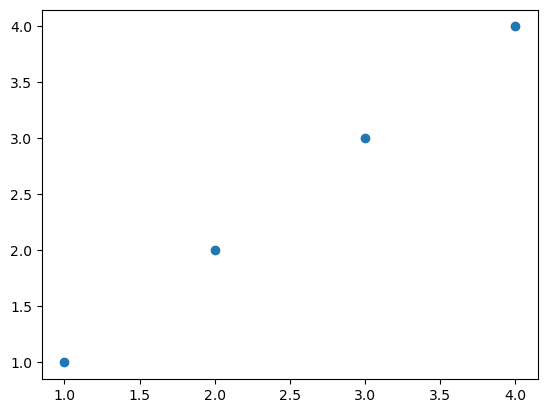

In [41]:
#산점도는 scatter() 함수로 그립니다. 함수 첫 번째 매개변수에 점들의 x축 좌표를 전달하고 두 번째 매개변수에 y축 좌표를 전달합니다. 
#다음처럼 scatter() 함수를 호출한 다음에는 show() 함수를 호출하여 그래프를 출력합니다. 
plt.scatter([1,2,3,4], [1,2,3,4])
plt.show()     #파이썬 스크립트나 대화형 셸을 사용할 때는 꼭 show() 함수를 호출해야 그래프가 그려지지만, 최신 주피터 노트북과 코랩에서는 자동으로 호출해줍니당

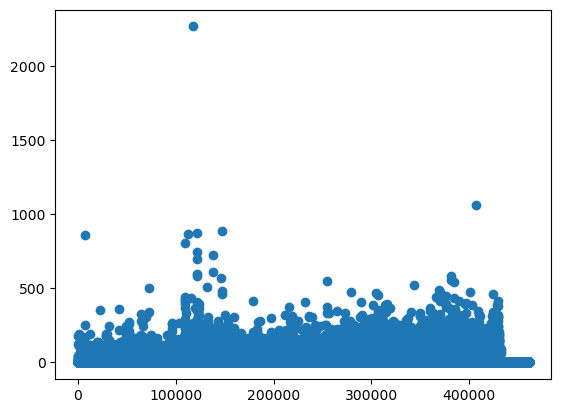

In [42]:
#이번에는 남산도서관 대출 데이터를 사용해 산점도를 그려보겠습니다. 맷플롯립은 편리하게도 X축과 Y축 값으로 데이터프레임의 열을 입력받을 수 있습니다.
plt.scatter(ns_book7['번호'], ns_book7['대출건수'])
#출력된 그래프를 보면 데이터가 많이 겹쳐져 있는 것을 알 수 있습니다. 

In [43]:
#x추겡 놓인 '번호' 열의 값에 따라 대출건수가 어떻게 변화하나요? 사실 '번호' 열은 원본 대츨 데이터에서 각 행에 붙여진 일련번호입니다. 
#이런 일련번호는 데이터를 구분하기 위한 용도이므로 '번호' 열의 값이 낮거나 높다고 대출건수가 달라지지 않을 가능성이 높죠. 
#따라서 위에 출력된 산점도에서도 이런 경향을 잘 볼 수 있습니다. 대출건수(y축)는 번호(x축)를 따라 비교적 고릋게 퍼져있습니다.

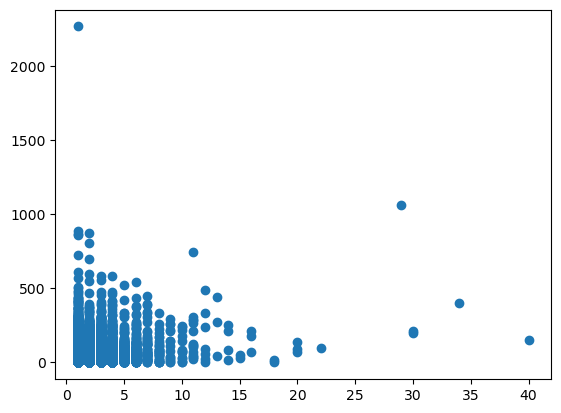

In [44]:
#그럼 '번호' 열 말고 '도서권수'와 '대출건수' 열의 산점도를 살펴보죠.
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'])

In [45]:
#도서권수가 많음녀 대출건수도 많을 것이라 예상하기 쉽지만, 앞의 산점도를 보면 이런 경향을 파악하기 쉽지 않습니다. 
#특히 대부분의 도서가 1~2권이기 때문에 x축 0~10 범위인 왼쪽 아래 모서리에 데이터 포인트가 중첩되네요.
#이럴 때는 산점도에 투명도를 주면 중첩된 데이터 포인트를 가늠하기 좋습니다.

### 투명도 조절하기: aplha 매개변수
맷플롯립은 alpha 매개변수에 0~1 사이의 값으로 투명도를 지정할 수 있습니다. 

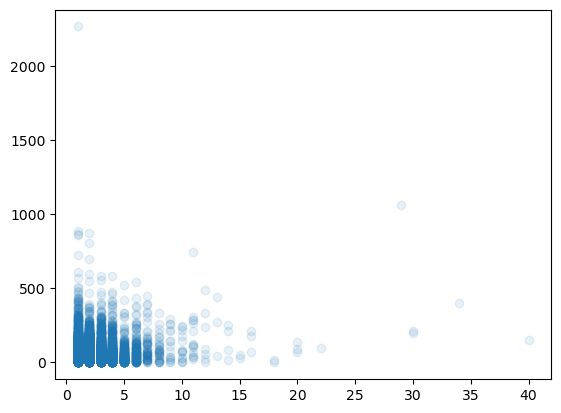

In [46]:
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)     #투명도를 지정합니다. 0에 가까울수록 투명하고, 1에 가까울수록 불투명하게 그려집니다.
plt.show()

In [47]:
#describe() 메서드로 기술통계를 확인했을 때도 도서권수의 백분위 90%에 위치한 값은 2였습니다. 대부분의 도서권수가 2보다 작다는 것을 알 수 있습니다.
#투명도를 주면 데이터가 많이 중첩되었을 때 산점도가 짙게 나타납니다.

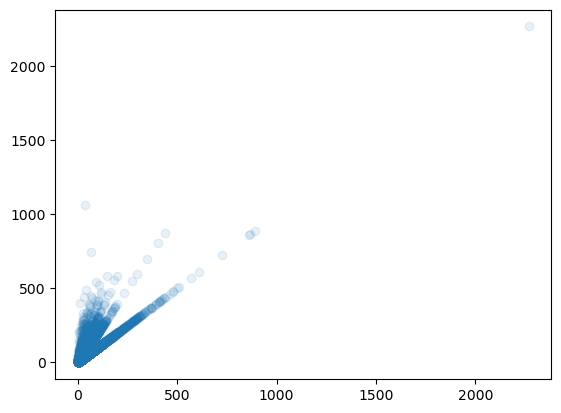

In [48]:
#도서권수가 대부분 작은 값이기 때문에 도서권수와 대출건수 사이의 관계를 파악하기 어렵습니다.
#이번에는 '도서권수'열 대신에 '대출건수'열을 '도서권수'열로 나눈 값을 사용해 보죠. 도서권수 당 대출건수를 x축, 대출건수를 y축에 두겠습니다.
#당연히 이 두 값은 양의 상관관계를 가질 것입니다. 확인해보죠!
average_borrows=ns_book7['대출건수']/ns_book7['도서권수']    #'대출건수' 열을 '도서권수' 열로 나눈 값을 변수에 저장
plt.scatter(average_borrows, ns_book7['대출건수'], alpha=0.1)
plt.show()   #생략 가능

In [49]:
#x축이 증가함에 다라 y축이 증가하므로 두 특성 사이에는 '양의 상관관계가 있다'고 말할 수 있겠습니다.
#산점도는 2차원 혹은 3차원만 가능하기 때문에 한 번에 표현할 수 있는 특성 개수에 한계가 있습니다.

이번에는 한 특성의 데이터 분포를 볼 수 있는 히스토그램에 대해 알아보겠습니다.
### 히스토그램 그리기: hist() 함수
히스토그램은 수치형 특성의 값을 일정한 구간으로 나누어 구간 안에 포함된 데이터 개수를 막대 그래프로 그린 것입니다. 
구간 안에 속한 데이터 개수를 도수라고 부르고, 구간은 계급이라고도 합니다.(x축이 구간, y축이 도수)

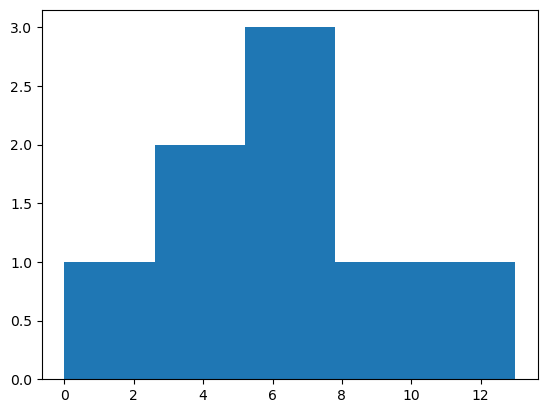

In [50]:
#맷플롯립으로 히스토그램을 그릴 땐 hist() 함수를 사용합니다. hist() 함수는 1차원 데이터를 입력받아 히스토그램을 그리며, 기본적으로 데이터를 10개의 구간으로 나눕니다.
#구간의 개수를 지정할땐 bins 매개변수를 이용합니다.
plt.hist([0,3,5,6,7,7,9,13], bins=5)    #8개의 정수로 이루어진 데이터를 5개의 구간으로 나눕니다.
plt.show()   #생략 가능

In [51]:
#어느 구간에 데이터가 많은지 한눈에 잘 보이지만, 구간이 어떻게 나누어졌는지 수치를 확인할 수 없네요.
#히스토그램의 구간을 정확하게 확인하기 위해 넘파이에서 제공하는 histrogram)hin)deges() 함수를 사용해봅시다.
import numpy as np
np.histogram_bin_edges([0,3,5,7,7,9,13], bins=5)

array([ 0. ,  2.6,  5.2,  7.8, 10.4, 13. ])

In [52]:
#결과- 첫 번째 구간은 0~2.6까지입니다. 두 번째 구간은 2.6~5.3까지입니다. 이때 경곗값인 2.6은 두 번째 구간에 포함됩니다. 마지막 구간은 13을 포함합니다.

In [53]:
#더 많은 데이터를 가상으로 만들어 히스토그램을 그려 보겠습니다. 넘파이의 randn() 함수는 표준정규분포를 따르는 랜덤한 실수를 생성합니다.
#이 함수에 원하는 샘플 개수를 전달하여 난수(random number)를 생성해 보겠습니다.
np.random.seed(42)         #seed() 함수를 사용하면 난수를 고정할 수 있어 실험 재현을 할 수 있습니다. 
random_samples=np.random.randn(1000)      #랜덤한 실수 1000개 생성
#randn() 함수는 랜덤한 값을 생성하기 때문에 실행할 때마다 다른 값이 추출됩니다. seed() 함수를 사용하면 언제나 동일한 난수를 추출할 수 있습니다.

In [54]:
#random_samples 배열이 표준정규분포를 따르고 있는지 확인하기 위해 평균과 표준편차를 계산해 봅시다. 
print(np.mean(random_samples), np.std(random_samples))  
#표준정규분포는 평균이 0, 표준편차가 1

0.01933205582232549 0.9787262077473543


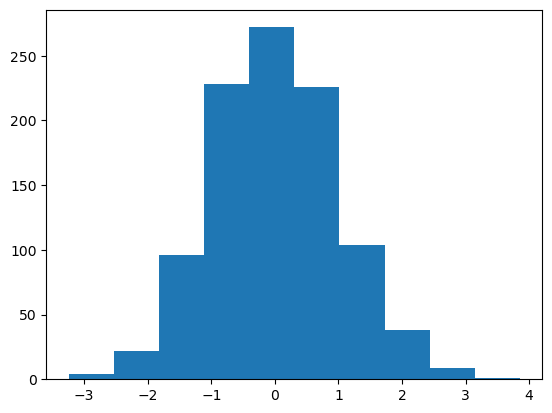

In [55]:
#이제 히스토그램을 그려서 종 모양의 분포가 나오는지 확인해보면 됩니다.
plt.hist(random_samples)
plt.show()

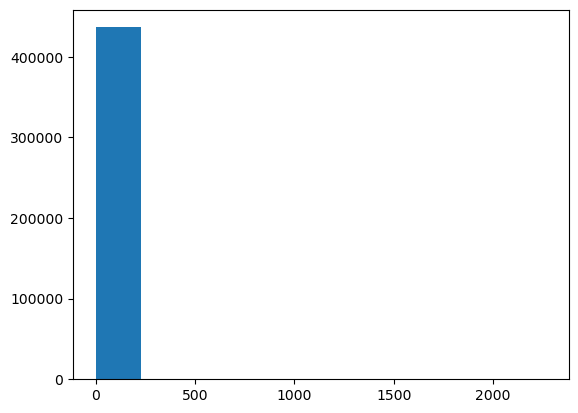

In [56]:
#이제 남산도서관 대출 데이터에서 수치 데이터의 분포를 확인하기 위해 히스토그램을 그려 보죠.
plt.hist(ns_book7['대출건수'])
plt.show()

In [57]:
#산점도에서도 보았듯이 대부분 도서의 대출건수는 작습니다. 따라서 위 그림과 같이 첫 번째 구간의 도수만 너무 큰 현상이 발생합니다.

### 구간 조정하기 (by 로그 스케일)
한 구간의 도수가 너무 커서 다른 구간에는 도수가 표시되지 않는 현상이 발생하면 y축을 로그 스케일로 바꾸어 해결할 수 있습니다.

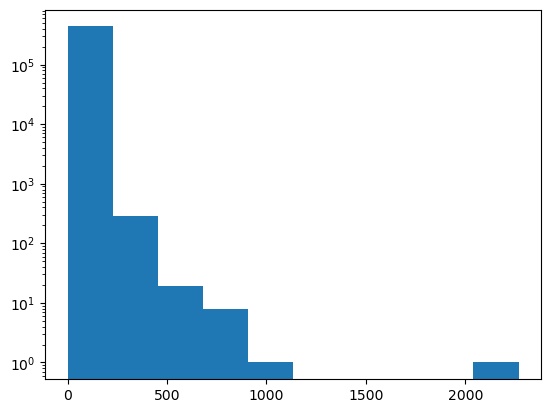

In [58]:
#맷플롯립에서 y축을 로그 스케일로 바꾸려면 다음처럼 yscale() 함수에 'log'를 지정하면 됩니다. 
#출력된 히스토그램을 보면 앞에서는 나타나지 않았던 다른 구간의 도수가 표시됩니다. 해석할때는 실제 데이터가 훨씬 더 격차가 크다는 점을 꼭 기억하세요!
plt.hist(ns_book7['대출건수'])
plt.yscale('log')

In [59]:
#맷플롯립은 기본적으로 밑이 10인 로그 함수를 사용합니다. 그래서 y축의 눈금 스케일이 10^0에서 10^5까지 나타나 있습니다.
#hist() 함수에는 특별히 로그 스케일로 히스토그램을 그릴 수 있도록 log 매개변수를 제공합니다. 
#이 변수를 True로 지정하면 yscale()를 사용한 것과 동일한 그래프를 그릴 수 있습니다.

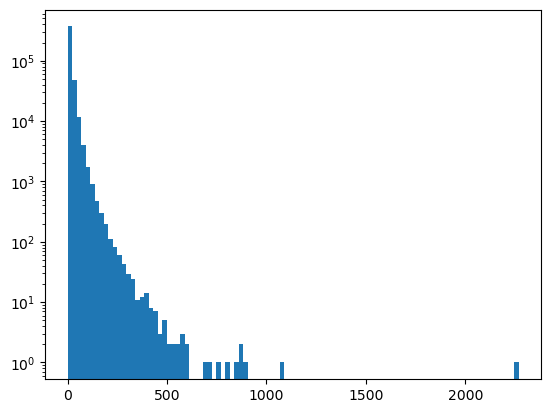

In [60]:
#이번에는 x축의 구간을 더 세세하게 나누어 보겠습니다.
plt.hist(ns_book7['대출건수'], bins=100)     #구간을 100개로 나눔
plt.yscale('log')
#결과- 대출건수 0이 제일 많고 건수가 증가함에 따라 도수가 줄어듭니다.

(array([2.4036e+04, 5.8202e+04, 8.2190e+04, 5.2048e+04, 5.4627e+04,
        2.9009e+04, 2.8304e+04, 1.7317e+04, 1.9723e+04, 1.3068e+04,
        1.4801e+04, 9.0540e+03, 7.3660e+03, 7.2100e+03, 3.9890e+03,
        4.0170e+03, 2.2230e+03, 2.2360e+03, 1.2420e+03, 1.3480e+03,
        7.4500e+02, 7.9400e+02, 5.1900e+02, 5.2900e+02, 2.9600e+02,
        2.6800e+02, 2.8500e+02, 1.7900e+02, 1.7800e+02, 1.3800e+02,
        1.2400e+02, 1.1100e+02, 1.0100e+02, 6.9000e+01, 7.6000e+01,
        4.7000e+01, 4.9000e+01, 3.1000e+01, 2.7000e+01, 2.6000e+01,
        1.9000e+01, 2.6000e+01, 1.5000e+01, 1.4000e+01, 8.0000e+00,
        1.7000e+01, 6.0000e+00, 5.0000e+00, 2.8000e+01, 2.0000e+00,
        5.0000e+00, 3.0000e+00, 3.0000e+00, 5.0000e+00, 3.0000e+00,
        1.0000e+00, 0.0000e+00, 1.0000e+00, 4.0000e+00, 0.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.00

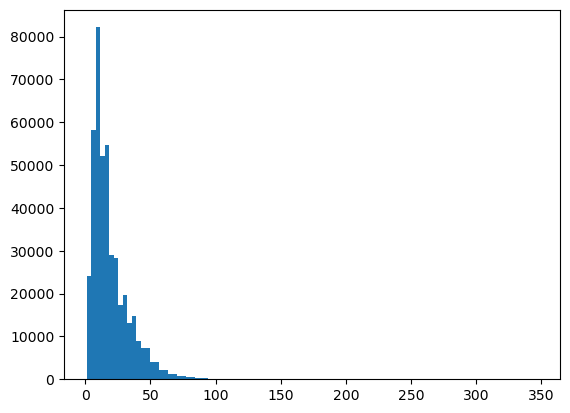

In [61]:
#도서명 길이가 정규분포에 가까운지 알아봅시다.
#'도서명' 열에 apply() 메서드를 사용하여 파이썬의 len() 함수를 적용하면 title_len 변수는 각 도서명의 길이가 저장된 판다스 시리즈 객체가 됩니다.
title_len=ns_book7['도서명'].apply(len)    #데이터프레임에 len() 함수를 반복 적용합니다.(apply(): 각 행마다 ()를 적용해라)
plt.hist(title_len, bins=100)

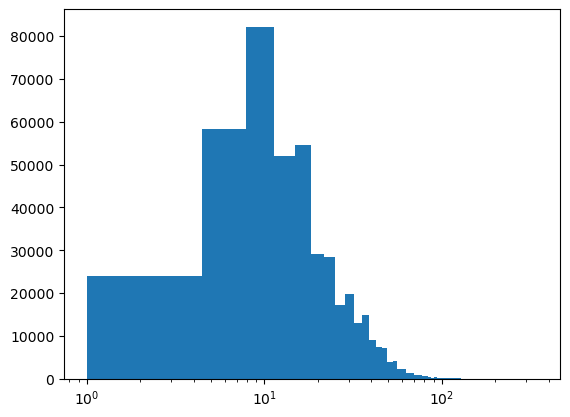

In [62]:
#앞에서 y축에 로그 스케일을 적용했던 것처럼 x축에도 로그 스케일을 적용할 수 있습니다. y축에 로그 스케일을 적용했던 것과 비슷하게 xscale() 함수를 사용하면 됩니다.
plt.hist(title_len, bins=100)
plt.xscale('log')

In [63]:
#히스토그램은 이처럼 하나의 특성에 대한 분포를 확인하기 좋습니다. 하짐나 여러 개의 특성을 비교하려면 각기 따로 그린 히스토그램을 비교해야 하죠.
#그래프를 잘 비교하려면 각 축의 범위를 맞추어 그려야겠군요. 조금 더 편리하게 여러 특성의 분포를 비교할 수 있는 방법은 없을까요?

### 상자 수염 그림 그리기
상자 수염 그림은 최솟값, 세 개의 사문위수, 최댓값 이렇게 다섯 개의 숫자를 사용해 데이터를 요약하는 그래프를 그립니다.
-1. 먼저 사분위수를 계산하여 25%와 75% 지점을 밑면과 윗면으로 하는 직사각형을 그립니다. 2. 중간값, 즉 50%에 해당하는 지점에 수평선을 긋습니다. 3. 사각형의 밑면과 윗면에서 사각형의 높이의 1.5배만큼 떨어진 거리 안에서 가장 멀리 있는 샘플까지 수직선을 긋습니다. 4. 이 수직선 밖에서 최솟값과 최댓값까지 데이터를 점으로 표시합니다. 이 영역의 데이터를 이상치(outlier)라고 부릅니다. 직사각형 밑면과 윗면의 높이의 길이를 IQR(interquartile range)라고 합니다.

상자 수염 그림은 여러 개의 특성을 시각적으로 비교하기 좋습니다. 특히 데이터가 어떤 방향으로 더 많이 늘어져 있는지 알 수 있죠.

{'whiskers': [<matplotlib.lines.Line2D at 0x1b2d7fb9e50>,
 'caps': [<matplotlib.lines.Line2D at 0x1b2d7fba0d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1b2d7fb9d10>,
 'medians': [<matplotlib.lines.Line2D at 0x1b2d7fba350>,
 'fliers': [<matplotlib.lines.Line2D at 0x1b2d7f6a490>,
 'means': []}

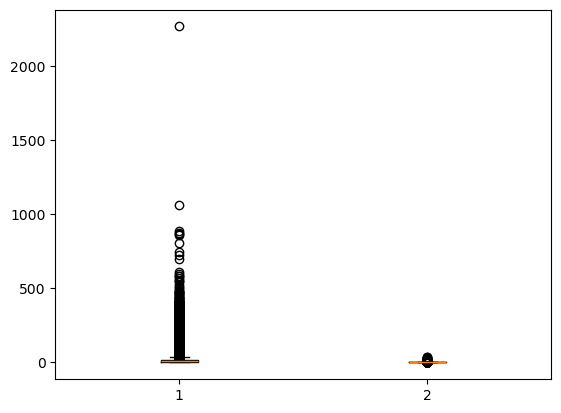

In [64]:
#맷플롯립에서 상자 수염 그림은 boxplot() 함수로 그립니다. 이 함수에 한 개 이상의 데이터프레임 열을 전달하여 그래프를 그립니다.
plt.boxplot(ns_book7[['대출건수','도서권수']])     # 문자열로 열 선택 → Series 반환, 리스트로 열 선택 → DataFrame 반환(저건 문자열을 리스트로 감싸서 대괄호 두개)

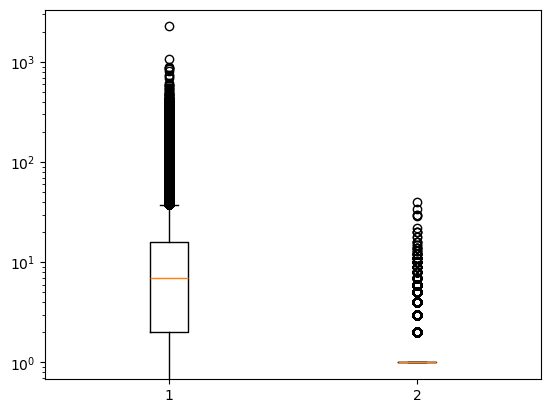

In [65]:
#1번 상자(대출건수)와 2번 상자(도서권수) 데이터는 사분위수가 매우 작아 상자가 보이지 않네요. y축을 로그 스케일로 바꿔 봅시다.
plt.boxplot(ns_book7[['대출건수','도서권수']])
plt.yscale('log')

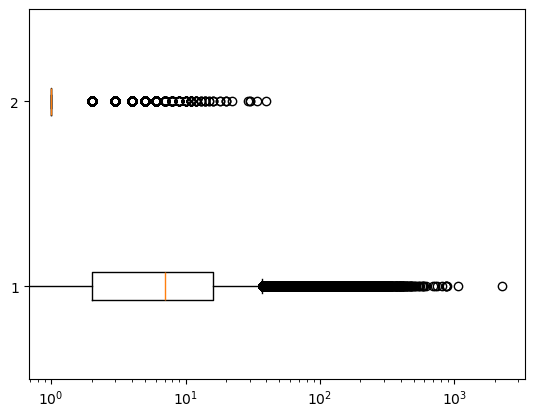

In [66]:
# (+)상자 수염 그림 수평으로 그리기: vert 매개변수를 기본값 True(수직)에서 False(수평)으로 바꾸기, 로그 스케일 적용시 x축에 지정해야 함 주의
plt.boxplot(ns_book7[['대출건수','도서권수']], vert=False)
plt.xscale('log')

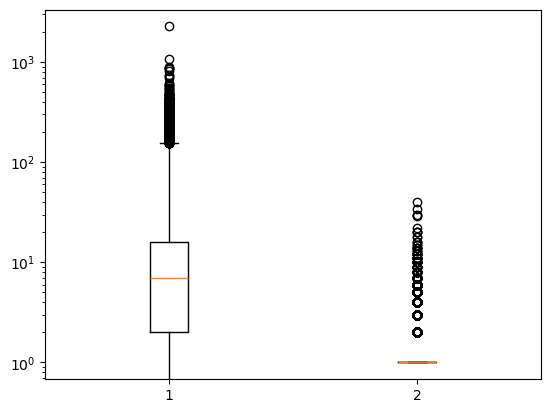

In [67]:
#(+)수염 길이 조절하기: whis 매개변수- 기본적으로 수염의 길이는 IQR의 1.5배입니다.
plt.boxplot(ns_book7[['대출건수','도서권수']], whis=10)
plt.yscale('log')

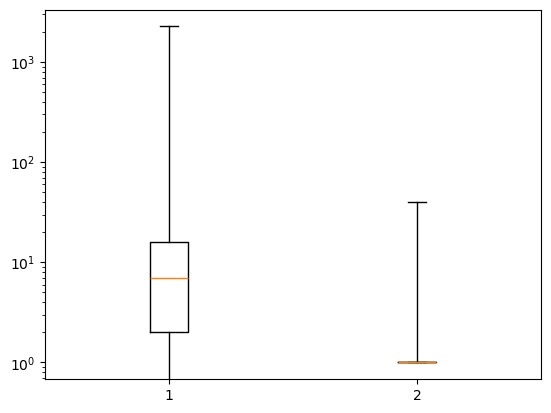

In [68]:
#whis 매개변수는 백분율로도 지정할 수 있습니다. 예를 들어 (10,90)으로 지정하면 10%, 90% 백분위수에 해당하는 데이터까지 수염을 그립니다.
#다음처럼 (0,100)으로 지정하면 마지막 데이터까지 수염을 그릴 수 있습니다. 
plt.boxplot(ns_book7[['대출건수','도서권수']], whis=(0,100))
plt.yscale('log')

In [69]:
#정리- 상자 수염 그림을 수평으로 그릴 때는 vert 매개변수, 수염 길이를 조정할 때는 whis 매개변수를 사용힙니다~~

## 판다스의 그래프 함수
판다스 데이터프레임에도 여러 가지 그래프를 그릴 수 있는 메서드를 제공합니다. 앞서 맷플롯립 함수로 그려본 그래프를 판다스 메서드로는 어떻게 그리는지 알아봅시다.

C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44428 (\N{HANGUL SYLLABLE GWEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, *

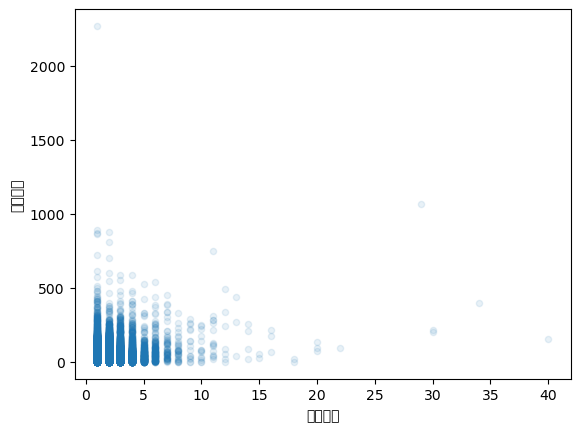

In [70]:
#산점도 그리기: plot속성의 scatter() 메서드- 맷플롯립과 달리 데이터프레임으로 그래프를 그릴 떄는 x축과 y축에 해당하는 열 이름만 지정하면 됩니다. 
ns_book7.plot.scatter('도서권수','대출건수',alpha=0.1)
plt.show()

In [71]:
#scatter() 메서드는 축의 이름을 자동으로 열 이름으로 표시하는데, 열 이름이 한글일 때는 제대로 출력되지 않습니다.

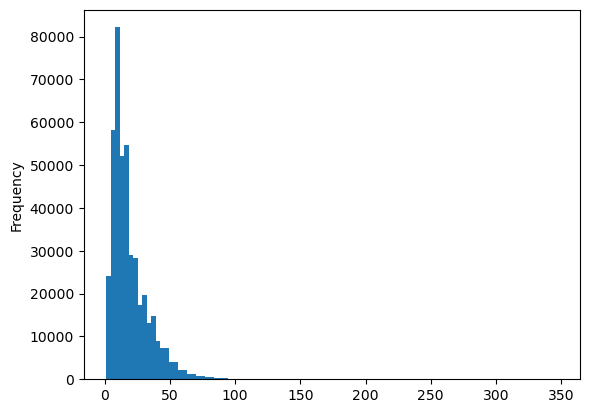

In [72]:
#히스토그램 그리기: hist() 메서드
#맷플롯립으로 그릴 때는
#도서명 길이에 대한 객체를 따로 생성했었는데, 판다스는 데이터프레임에 apply() 메서드를 적용한 다음 이어서 바로 메서드를 호출할 수 있습니다.
ns_book7['도서명'].apply(len).plot.hist(bins=100)
plt.show()

C:\Users\User\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 49436 (\N{HANGUL SYLLAB

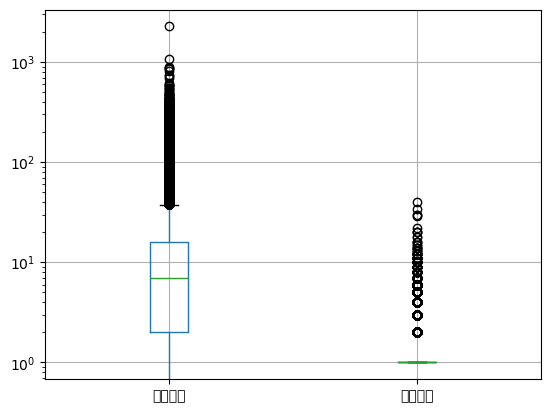

In [73]:
#상자 수염 그림 그리기: boxplot() 메서드
ns_book7[['대출건수','도서권수']].boxplot()
plt.yscale('log')

# ch5. 데이터 시각화하기

## 5-1 맷플롯립 기본 요소 알아보기 
(피겨, rcParams, 축, 마커. 서브플롯)
맷플롯립 그래프를 담는 객체인 figure, reParams, 서브플롯에 대해 알아보면서 그래프를 다양하게 그려 보고, 필요한 정보를 정확하게 표현하는 방법을 배워 보겠습니다.

### Figure 객체
맥플롯립에는 Figure라는 모든 그래프 구성 요소를 담고 있는 최상위 객체가 있습니다. scatter() 함수로 산점도를 그릴 때 자동으로 피겨 객체가 생성되는데요, figure() 함수로 명시적으로 피겨 객체를 만들어 활용하면 다양한 그래프 옵션을 조절할 수 있습니다. 

In [74]:
import pandas as pd
ns_book7.to_csv("ns_book7.csv", index=False, encoding="utf-8-sig")

In [75]:
ns_book7=pd.read_csv('ns_book7.csv', low_memory=False)
ns_book7.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,페스트,알베르 카뮈 지음 ;김화영 옮김,민음사,2020,9788937462672,NaN,NaN,267,808,1,181,2025-12-31
1,2,앤서니 브라운의 행복한 미술관,"앤서니 브라운 글 그림, 서애경 옮김",웅진씽크빅,2004,9788901044873,NaN,NaN,NaN,843,1,0,2025-12-31
2,4,지구를 여행하는 히치하이커를 위한 안내서,"아이작 유엔 지음, 성소희 옮김",학산문화사,2025,9791141162504,NaN,NaN,NaN,NaN,1,0,2025-12-31
3,5,독서에도 교육이 필요하다면,최소희.이승화 지음,인품,2020,9791196594213,NaN,NaN,NaN,NaN,1,0,2025-12-31
4,6,쌀 재난 국가,이철승 지음,문학과지성사,2021,9788932038001,NaN,NaN,NaN,NaN,1,0,2025-12-31


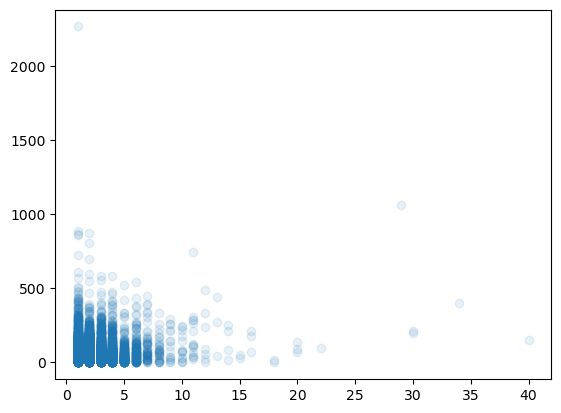

In [76]:
#산점도를 그려 볼까요? 맷플롯립을 임포트한 후 scatter() 함수로 '도서권수' 열을 x축, '대출건수' 열을 y축으로 그립니다.
#투명도를 0.1로 지정하면 다음과 같이 출력됩니다.
import matplotlib.pyplot as plt
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

### 그래프 크기 바꾸기:figsize 매개변수

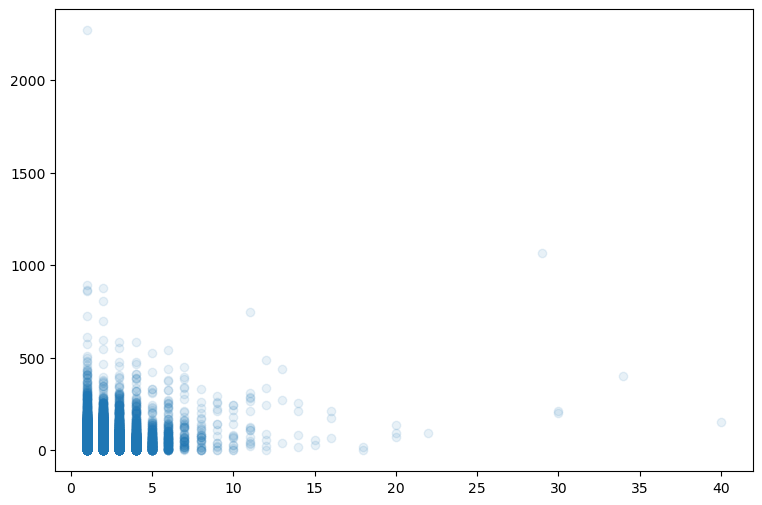

In [77]:
# figure() 함수를 사용하여 피겨 객체를 만들면 그래프 옵션을 조절할 수 있습니다. figsize 매개변수에 그래프의 크기를 튜플로 지정할 수 있는데, 기본 그래프 크기는 (6,4)
#figsize 매개변수를 (9,6)으로 지정하여 산점도를 좀 더 크게 그려 보겠습니다. (튜플- 소괄호, (너비, 높이), 단위는 인치)
plt.figure(figsize=(9,6))         #너비가 9인치, 높이가 6인치인 피겨 객체를 생성
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()      #show() 함수를 호출하면 figure() 함수로 만들어진 피겨 객체는 자동 소멸

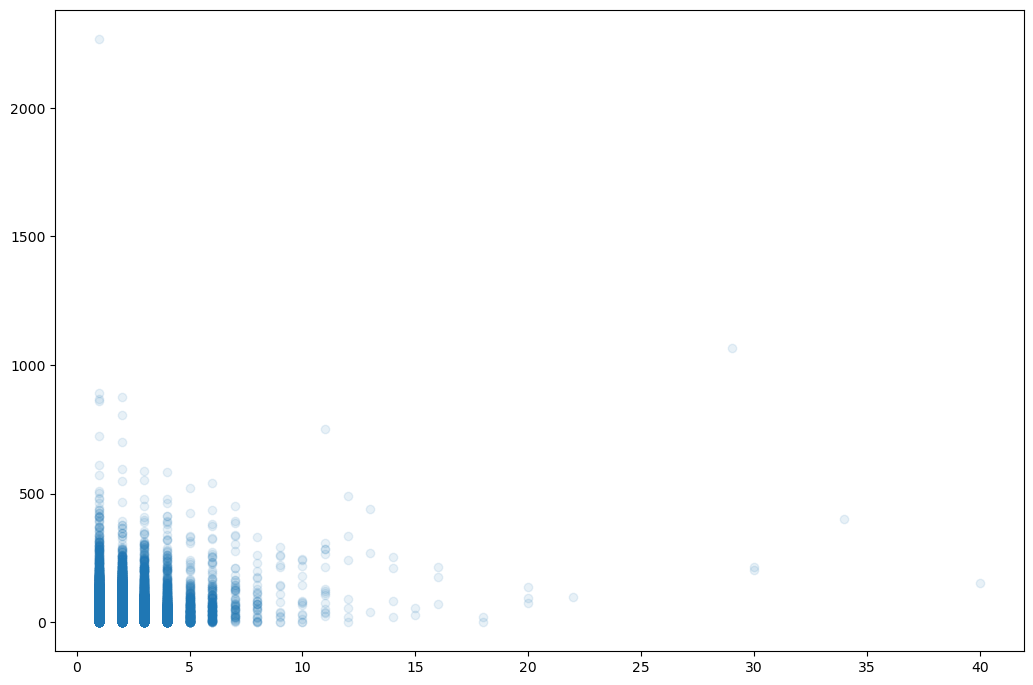

In [78]:
#그래프 실제 크기 확인하기- 위에서 튜플로 지정한 사이즈와 출력사이즈가 달라보인다면- DPI(인치당 픽셀 개수) 설정을 확인
#인치 값은 원하는 픽셀 값을 정한 다음 픽셀 값을 DPI로 나누기 (예: 900X600 픽셀 크기의 그래프를 그리고 싶을때, 맷플롯립의 DPI 기본값은 72이므로 다음처럼 두 픽셀 값을
#72로 나눠 figsize 매개변수에 전달.
plt.figure(figsize=(900/72, 600/72))
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

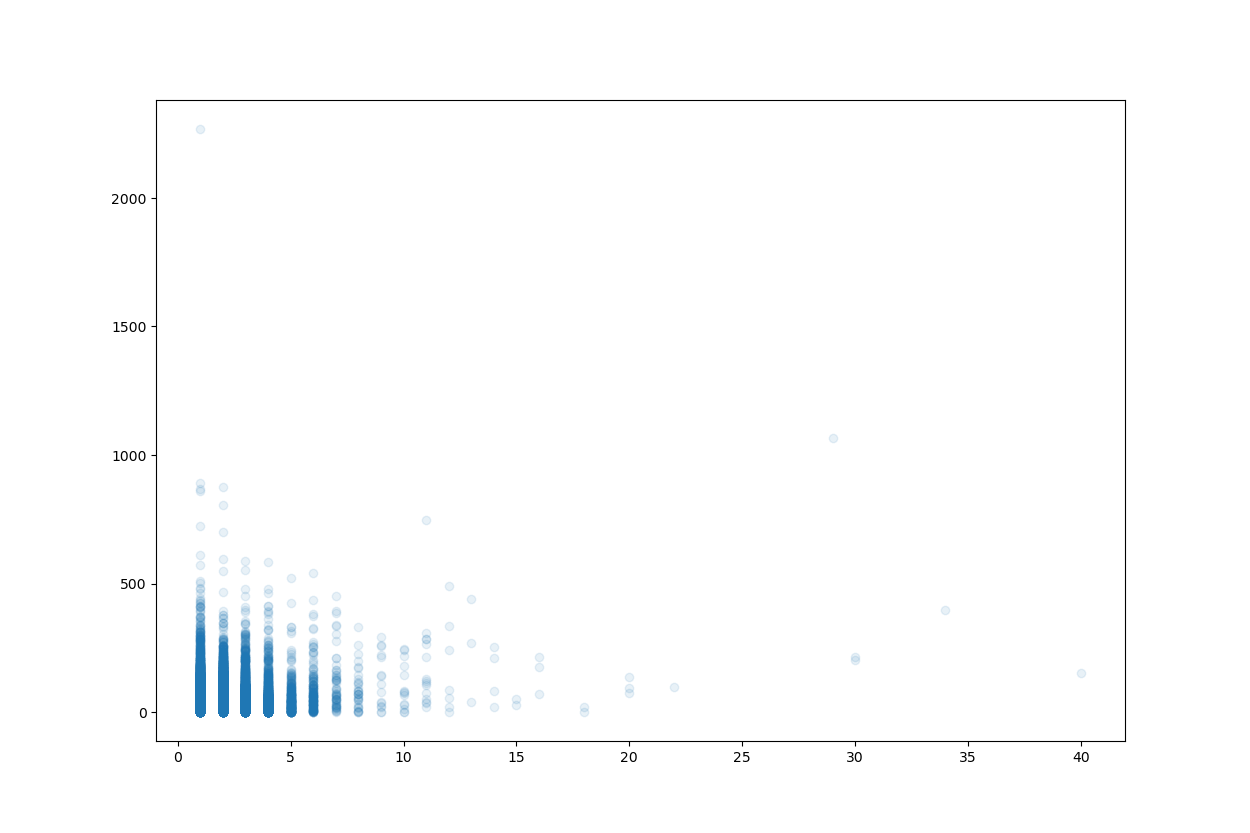

In [79]:
#만약 코랩 노트북처럼 맷플롯립 그래프를 출력할 때 그래프 주변 공백을 최소화하는 타이트 레이아웃을 사용한다면- bbox_inches 옵션을 None으로 지정
%config InlineBackend.print_figure_kwargs={'bbox_inches': None}
plt.figure(figsize=(900/72, 600/72))
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

In [80]:
#다시 타이트 복구
%config InlineBackend.print_figure_kwargs={'bbox_inches': 'tight'}

### 그래프 크기 바꾸기: dpi 매개변수

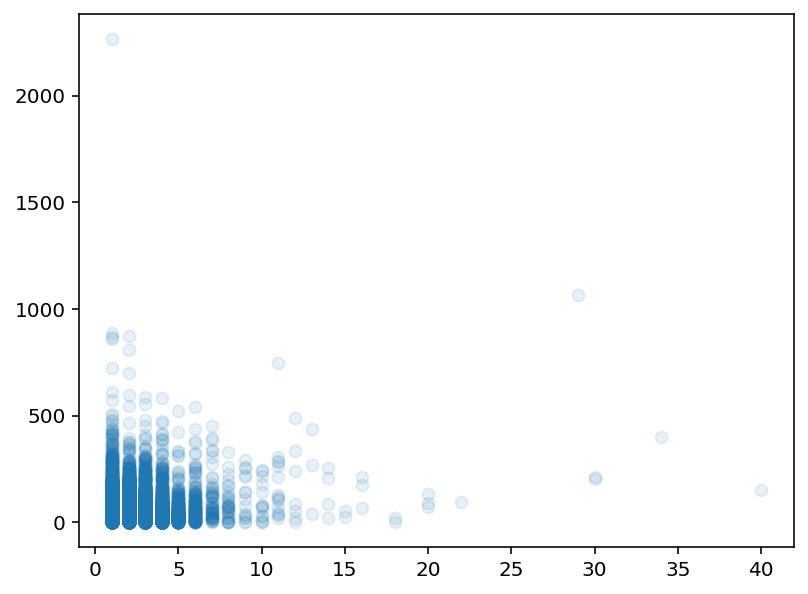

In [81]:
#이번에는 figsize 매개변수는 기본값 그대로 두고 dpi 매개변수를 지정해 보겠습니다. 
plt.figure(dpi=144)     #dpi를 기본값인 72에서 144로 두 배 늘려 줍니다.
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

In [82]:
#dpi 매개변수를 두 배로 늘리면 인치당 픽셀 수가 두 배로 늘어나기 때문에 그래프가 두 배 커집니다.
#또한 그래프 안의 모든 구성 요소도 함꼐 커집니다. x축과 y축의 숫자가 커졌고, 데이터 포인트를 나타내는 동그라미 마커의 크기도 커졌습니다.

#정리: figsize는 그래프를 그리는 캔버스 크기, DPI는 그래프를 확대해서 보는 돋보기처럼 생각하면 이해하기 쉽습니다. 그래프 해상도와 크기를 두 매개변수로 적절하게 조절하여
#원하는 이미지 크기를 얻어 보세요.

### rcParams 객체
rcParams는 맷플롯립 그래프의 기본값을 관리하는 객체입니다. 객체에 담긴 값을 출력하는 것뿐만 아니라 새로운 값으로 바꿀 수도 있습니다.
이렇게 하면 이후에 그려지는 모든 그래프에 바뀐 설정이 적용됩니다.

### DPI 기본값 바꾸기

In [83]:
#먼저 기본 그래프 해상도를 높이기 위해 DPI 기본값을 바꾸어 줍니다. figure 객체의 DPI 기본값을 100으로 바꿔봅시다.
plt.rcParams['figure.dpi']=100

### 산점도 마커 모양 바꾸기

In [84]:
#산점도 그래프의 마커 기본값을 확인하려면 rcParams 객체의 속성을 scatter.marker로 지정합니다. 
plt.rcParams['scatter.marker']        #객체를 그냥 출력하면 기본값인 동그라미를 나타내는 'o'가 출력됩니다.

'o'

In [85]:
#마커를 별 모양으로 그리려면 값을 '*'로 지정
plt.rcParams['scatter.marker']= '*'

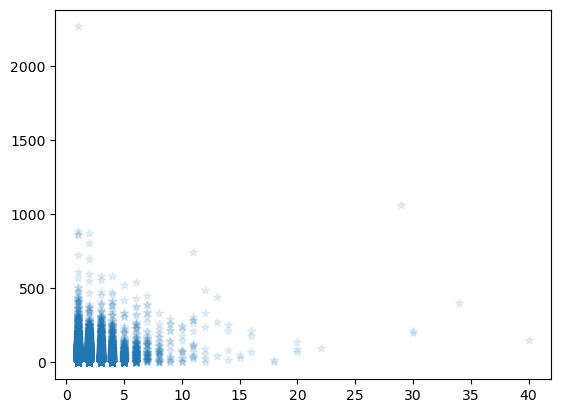

In [86]:
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
plt.show()

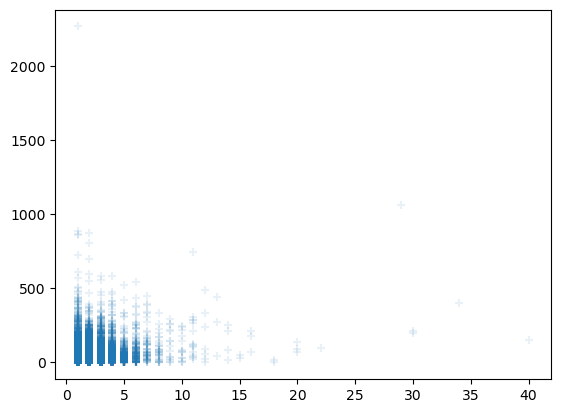

In [87]:
#하지만 여러 개의 산점도가 있고, 산점도마다 마커를 다르게 그려야 한다면 매번 설정을 바꾸어야 하는게 번거롭죠. 
#이럴 때는 기본값을 수정하는 것 대신 scatter() 함수의 marker 매개변수로 마커의 모양을 지정하면 rcParams 객체의 scatter.marker 속성에 지정된 기본값을 무시합니다.
plt.scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1, marker='+')      #marker 매개변수를 '+'로 설정해 덧셈 기호를 마커로 사용
plt.show()

#정리: 기본값을 수정할 때는 rcParams 객체의 scatter.marker 속성을, 해당 그래프만 바로 수정하려면 marker 매개변수를 사용합니다.

### 여러 개의 서브플롯 만들기
이제 맷플롯립 그래프의 구성 요소를 조금 더 자세히 알아보고, 하나의 피겨 객체에 여러 그래프를 그려 보겠습니다.
서브플롯이란 맷플롯립의 Axes 클래스의 객체를 말하며 하나의 서브플롯은 두 개 이상의 축을 포함합니다. 각 축에는 눈금 또는 틱(tick)이 표시됩니다. 또 축의 이름을 나타내는 레이블(label)이 있습니다. 

C:\Users\User\AppData\Local\Temp\ipykernel_3556\2350199032.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


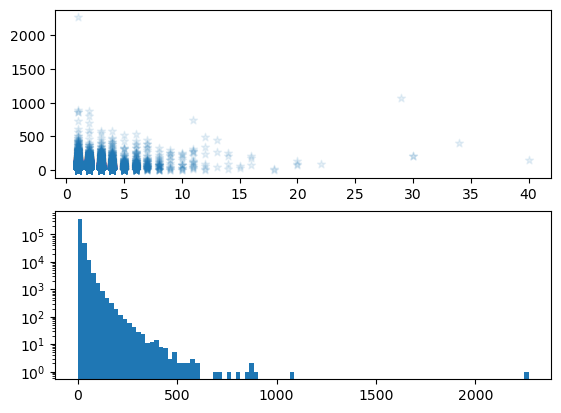

In [88]:
#서브플롯 그리기: subplots() 함수
#하나의 피겨 객체애 두 개의 서브플롯을 추가해 보겠습니다. 하나는 산점도를 그리고 다른 하나는 히스토그램을 그려 보겠습니다.
#서브플롯을 정의하려면 subplots() 함수에 원하는 서브플롯 개수를 지정하면 됩니다. 이 함수는 피겨 객체와 각 서브플롯을 나타내는 Axes 객체의 배열을 반환합니다. 

#subplots() 함수로 두 개의 서브플롯을 그리고 싶다면 매개변수에 2를 넣어 줍니다. 그다음 이 배열의 원소에서 각각 scatter() 함수와 hist() 함수를 호출합니다.

fig, axs= plt.subplots(2)

axs[0].scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)    #첫 번째 그래프(산점도)
axs[1].hist(ns_book7['대출건수'], bins=100)        #두 번째 그래프(히스토그램)
axs[1].set_yscale('log')        #히스토그램의 y축인 빈도는 로그 스케일로 지정하겠습니다.
fig.show()

C:\Users\User\AppData\Local\Temp\ipykernel_3556\3653148614.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


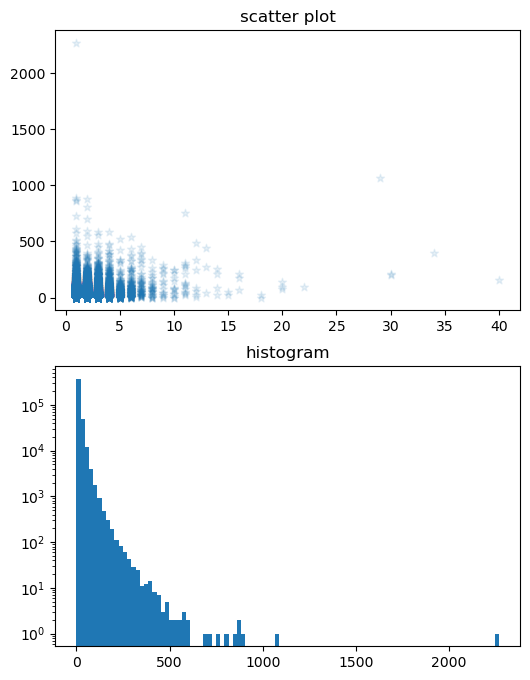

In [89]:
#피겨 크기의 기본값인 (6,4) 안에서 두 개의 서브플롯을 배치하기 때문에 각 그래프의 높이가 많이 줄었습니다. 
#subplots() 함수도 피겨 크기를 지정할 수 있는 figsize 매개변수를 제공합니다.
fig, axs=plt.subplots(2, figsize=(6,8))
axs[0].scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
axs[0].set_title('scatter plot')      #set_title() 메서드: 서브플롯의 제목을 넣어 줍니다.
axs[1].hist(ns_book7['대출건수'], bins=100)
axs[1].set_title('histogram')
axs[1].set_yscale('log')
fig.show()

In [90]:
#정리: 서브플롯은 피겨 객체 안에 그려집니다. subplots() 함수의 figsize 매개변수로 피겨의 크기를 조절하면 서브플롯 크기를 바꿀 수 있습니다.

C:\Users\User\AppData\Local\Temp\ipykernel_3556\2280871969.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


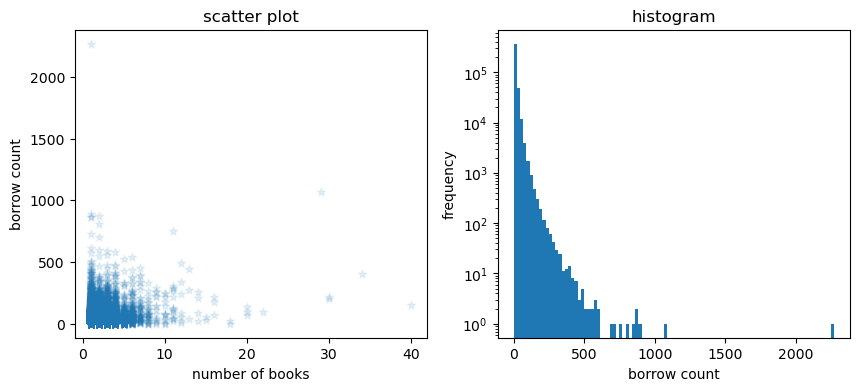

In [91]:
#서브플롯을 가로로 나란히 출력하기-subplots() 함수에 행과 열을 지정하면 원하는 서브플롯 개수의 피겨를 만들 수 있습니다.
#(함수의 첫 번째 매개변수는 서브플롯 행의 개수이고, 두 번째 매개변수는 열의 개수입니다.)

fig, axs=plt.subplots(1,2, figsize=(10,4))     #두 개의 열을 가진 서브플롯, 객체 너비 증가
axs[0].scatter(ns_book7['도서권수'], ns_book7['대출건수'], alpha=0.1)
axs[0].set_title('scatter plot')      #서브플롯1 그래프 이름 지정
axs[0].set_xlabel('number of books')    #서브플롯1 그래프의 x축 이름 지정
axs[0].set_ylabel('borrow count')      #y축 이름 지정

axs[1].hist(ns_book7['대출건수'], bins=100)
axs[1].set_title('histogram')
axs[1].set_yscale('log')
axs[1].set_xlabel('borrow count')
axs[1].set_ylabel('frequency')
fig.show()

## 5-2 선 그래프와 막대 그래프 그리기
선 그래프와 막대 그래프는 전체 데이터의 형태를 가늠할 수 있는 산점도와 조금 다릅니다. 한 축을 따라 어떤 데이터의 변화를 살펴보는 데 용이합니다.

In [92]:
#연도별 발행 도서 개수 구하기- 선 그래프를 그리는 데 적합하도록 데이터를 가공해 보겠습니다. 
#데이터프레임의 한 열에서 value_counts() 메서드를 호출하면 고유한 값의 등장 횟수를 계산합니다.
#(이 메서드는 고유한 값의 등장 횟수를 계산하므로 np.unique()함수에 return_counts=True를 지정해 얻은 결과와 비슷합니다.)
count_by_year=ns_book7['발행년도'].value_counts()
count_by_year

발행년도
2012    18677
2009    17800
2011    17628
2014    17543
2010    17451
        ...  
1930        1
1958        1
2548        1
1948        1
2542        1
Name: count, Length: 103, dtype: int64

In [93]:
#반환된 count_by_year는 판다스의 시리즈 객체입니다. 첫 번째 열이 인덱스이고 두 번째 열이 값에 해당합니다.
#선 그래프의 x축에 지정할 연도는 시간순으로 배치되는 것이 합리적입니다. count_by_year를 인덱스 기준으로 오름차순 정렬합시다.
#이럴 떄 시리즈 객체(count_by_year)의 sort_index() 메서드를 사용하면 인덱스 순서대로 데이터를 정렬할 수 있습니다. 
count_by_year=count_by_year.sort_index()     #인덱스 순으로 정렬
count_by_year

발행년도
1930     1
1938     1
1940     1
1942     1
1944     1
        ..
2552     2
2559     1
2560     1
2650     1
3000    15
Name: count, Length: 103, dtype: int64

In [94]:
#위 결과에서 미래에 발행될 도서가 대출 데이터에 들어 있네요. 연도가 잘못된 데이터를 count_by_year 객체에서 index 속성이 2030년보다 작거나 같은 데이터만 뽑겠습니다.
count_by_year=count_by_year[count_by_year.index<=2030]
count_by_year

발행년도
1930        1
1938        1
1940        1
1942        1
1944        1
        ...  
2023    12238
2024    10805
2025     7931
2028        1
2030        1
Name: count, Length: 82, dtype: int64

### 주제별 도서 개수 구하기

In [95]:
#이번에는 막대 그래프를 그리기 위한 주제별 도서 개수를 구해 보겠습니다. '주제분류번호'열에는 십진분료 코드가 기입되어 있거든요.
#'주제분류번호'의 첫 번째 문자만 선택할 수 있다면 value)counts() 메서드를 적용하여 쉽게 도서 개수를 취합할 수 있습니다. 
#다만 이 열에는 NaN이 포함되어 있으므로 값이 NaN이라면 -1을 반환하는 함수를 만들어 걸러내야 합니다.
import numpy as np      #np.nan을 사용하기 위해 넘파이 임포트

def kdc_1st_char(no):         #'주제분류번호' 열의 값이 NaN인 경우 -1을 반환하고, 그렇지 않으면 첫 번째 문자 반환
    if no is np.nan:
        return '-1'
    else: 
        return no[0]

count_by_subject=ns_book7['주제분류번호'].apply(kdc_1st_char).value_counts()
count_by_subject

주제분류번호
8     129752
3      91185
5      45856
9      29310
6      28689
1      27250
-1     21602
7      17044
4      15795
0      15485
2      14807
*          2
Name: count, dtype: int64

In [96]:
#여기서 인덱스는 숫자이지만 연도별 발행 도서 개수인 count_by_year와는 다르게 순서에 의미가 있지 않은 명목형 데이터임을 주의. 1은 철학, 2는 종교 서적이라는 의미일 뿐.

In [97]:
#선 그래프 그리기: count_by_year 시리즈 객체 사용
#맷플롯립의 plot() 함수는 선 그래프를 그릴 수 있습니다. 첫 번째 매개변수에는 x축의 값, 두 번째 매개변수에는 y축에 해당하는 값ㅇ르 전달합니다.
#일단 서브플롯을 사용하지 않고 간단하게 하나의 피겨 객체를 사용해 선 그래프를 그려 보겠습니다.
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=100      #그래프 해상도를 높이기 위해 기본 dpi를 100으로 바꾸기

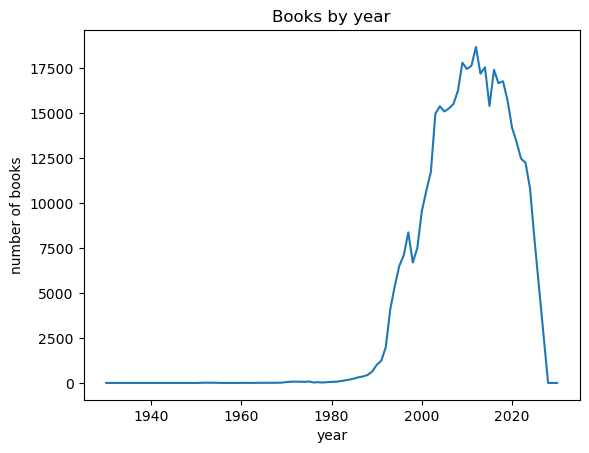

In [98]:
#그다음 plot() 함수의 두 매개변수에 count_by_year의 연도(index)와 도서 개수(values)을 각각 지정하여 선 그래프를 그리기
plt.plot(count_by_year.index, count_by_year.values)
plt.title('Books by year')      #서브플롯을 사용하지 않을 때는 그래프 제목을 title() 함수를 사용
plt.xlabel('year')       #서브플롯을 사용하지 않을 때는 x축 이름을 xlabel() 함수를 사용
plt.ylabel('number of books')
plt.show()

### 선 모양과 색상 바꾸기
plot() 함수는 선 모양을 지정할 수 있는 linestyle 매개변수를, 색상을 지정할 수 있는 color 매개변수를 제공합니다.

In [99]:
#linestyle 매개변수 기본값은 실선을 나타내는 '-'이고, 이외에 점선은 ':', 쇄선은 '-.', 파선은 '--'으로 지정할 수 있습니다.
#color 매개변수는 #ff0000처럼 16진수 컬러 코드를 지정하거나 red처럼 색 이름을 지정할 수 있습니다. 산점도에서 사용해 보았던 marker 매개변수도 제공.
#(color 매개변수에서 지원하는 색은 blue, green, red, cyan, magenta, yellow, black, white)

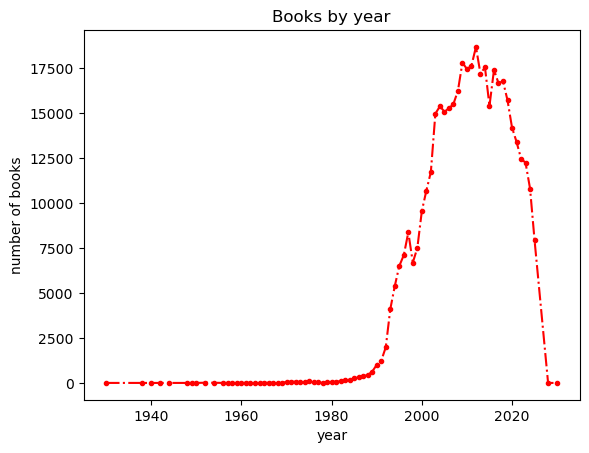

In [100]:
#그럼 마커는 점으로, 선은 쇄선을 사용한 선 그래프를 빨간색으로 다시 그려 봅시다. 
#또한 이번에는 x축의 값과 y축의 값을 각각 시리즈 객체의 index와 values로 지정하지 않고, 시리즈 객체 그대로 plot() 함수에 전달하겠습니다.
#이렇게 하면 자동으로 인덱스를 x축의 좌표로 사용하여 그래프를 그립니다.
plt.plot(count_by_year, marker='.', linestyle='-.', color='red')    #시리즈 객체 전달
plt.title('Books by year')
plt.xlabel('year')
plt.ylabel('number of books')
plt.show()

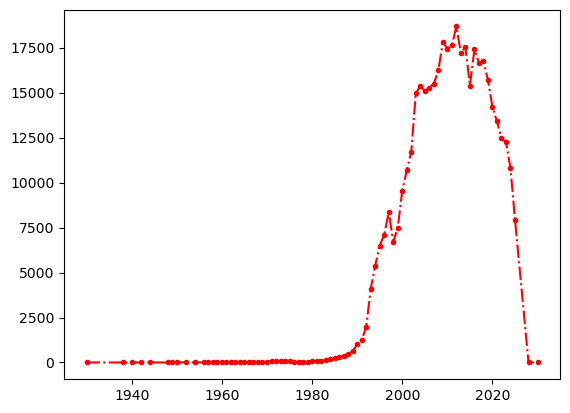

In [101]:
#plot() 함수의 매개변수의 마커, 선 모양, 색깔을 하나의 문자열로 합쳐서 선 그래프의 포맷으로 나타낼 수 있는데,문자열을 plot() 함수의 x, y축 값 다음에 지정하면 됨.
plt.plot(count_by_year, '.-.r')    #위와 똑같은 옵션 지정

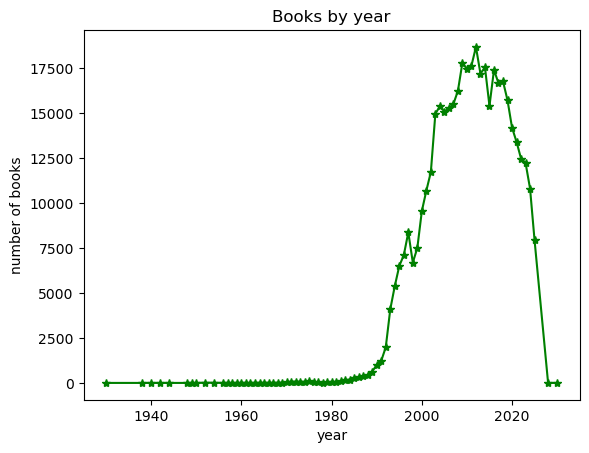

In [102]:
#이번에는 별 모양 마커와 실선을 사용한 선 그래프를 녹색으로 그려 볼까요?
plt.plot(count_by_year, '*-g')
plt.title('Books by year')
plt.xlabel('year')
plt.ylabel('number of books')
plt.show()

### 선 그래프 눈금 개수 조절 및 마커에 텍스트 표시하기- 마커 옆에 데이터값을 표시해 그래프 추이를 가늠하기
그래프의 눈금을 틱(tick)이라고 합니다.

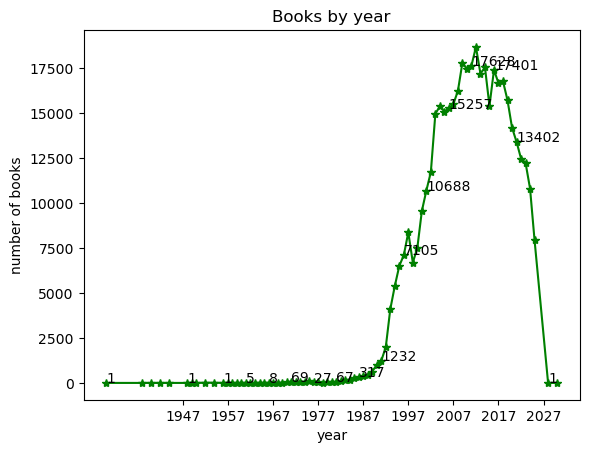

In [103]:
#x축 눈금 지정하기: xticks() 함수/ y축 눈금 지정: yticks()/ 서브플롯을 그릴 때 x축과 y축: set_xticks(), set_yticks()
#10년 단위로 x축의 눈금을 표시하기 위해 xticks() 함수 매개변수에 파이썬 range() 함수를 사용하겠습니다.
#그다음 연도별 발행 도서 개수를 모두 그래프에 표시하면 너무 많기 때문에 슬라이스 연산자(:)를 사용해 다섯 개씩 건너 뛰면서 coun_by_year의 값을 선택합니다.
#시리즈 객체의 items() 메서드를 사용하면 인덱스와 값을 감싼 튜플을 얻을 수 있습니다.

#그래프 값을 표시할 떄는 annotate() 함수를 사용합니다. 첫 번째 매개변수에 그래프에 나타낼 문자열을 지정하고, 두 번째 매개변수에 문자열이 나타날 x,y 죄표를 튜플로 지정합니다.
#선 그래프를 출력해 볼까요?
plt.plot(count_by_year, '*-g')     #별모양 마커, 실선, 초록색
plt.title('Books by year')
plt.xlabel('year')
plt.ylabel('number of books')
plt.xticks(range(1947, 2030, 10))     #(부터, 까지, 눈금 간격)
for idx, val in count_by_year[::5].items():       #⭐⭐⭐ #슬라이스 연산자의 스텝 옵션으로 다섯 개씩 건너서 발행 도서 개수를 그래프에 표시
    plt.annotate(val, (idx, val))      #그래프에 value를 나타냄, 텍스트가 나타낼 x, y 좌표
plt.show()

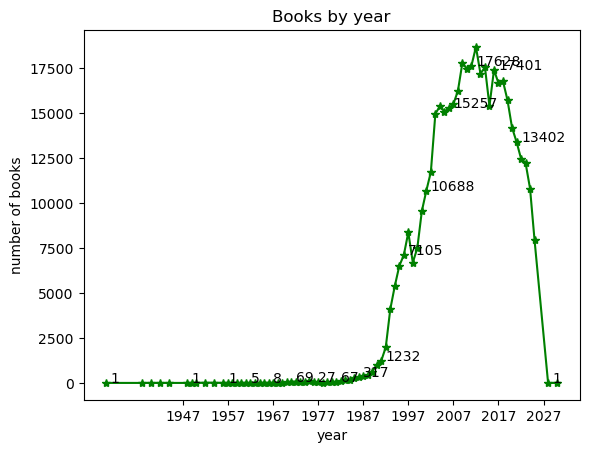

In [104]:
#출력된 그래프를 보면 마커 옆에 바로 텍스트가 붙어 있습니다. 텍스트를 마커에서 조금 떼어 놓으려면 텍스트 위치를 조절하는 xytext 매개변수를 사용할 수 있습니다.
#annotate() 함수는 기본적으로 마커와 동일한 좌표 시스템을 사용합니다. 다음처럼 마커 위치에서 x축은 1만큼, y축으로는 10만큼 떨어지게 지정해 보겠습니다.
plt.plot(count_by_year, '*-g')
plt.title('Books by year')
plt.xlabel('year')
plt.ylabel('number of books')
plt.xticks(range(1947, 2030, 10))
for idx, val in count_by_year[::5].items():
    plt.annotate(val, (idx, val), xytext=(idx+1, val+10))
plt.show()

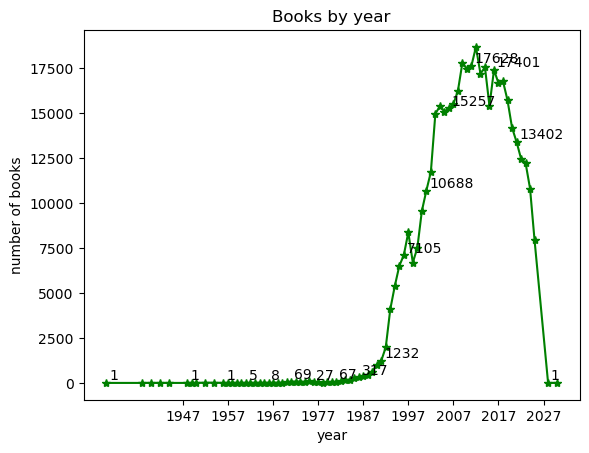

In [105]:
#x축으로 1만큼 떨어진 것은 구분이 되지만 y축으로 10만큼 떨어뜨린 것은 거의 차이가 없습니다. 이는 y축의 스케일(0~17500)이 x축보다 훨씬 크기 때문입니다.
#이런 경우에는 상대적인 위치를 포인트나 픽셀 단위로 지정해야 합니다. 다음처럼 xytext 매개변수와 함께 textcoords 매개변수를 사용합니다.
#여기에서는 textcoords 매개변수에 포인트 단위의 상대 위치를 나타내는 'offset points'를 지정합니다.
plt.plot(count_by_year, '*-g')
plt.title('Books by year')
plt.xlabel('year')
plt.ylabel('number of books')
plt.xticks(range(1947, 2030, 10))
for idx, val in count_by_year[::5].items():
    plt.annotate(val, (idx, val), xytext=(2,2), textcoords='offset points')
plt.show()
#1 포인트는 1/72인치를 의미합니다. 만약 픽셀 단위로 지정하려면 textcoords='offset pixels'를 사용할 수 있습니다.

### 막대 그래프 그리기
맷플롯립에서 bar() 함수는 막대 그래프를 그립니다. 앞에서 만든 주제별 도서 개수인 count_by_subject를 사용해 막대 그래프를 그려 보겠습니다.

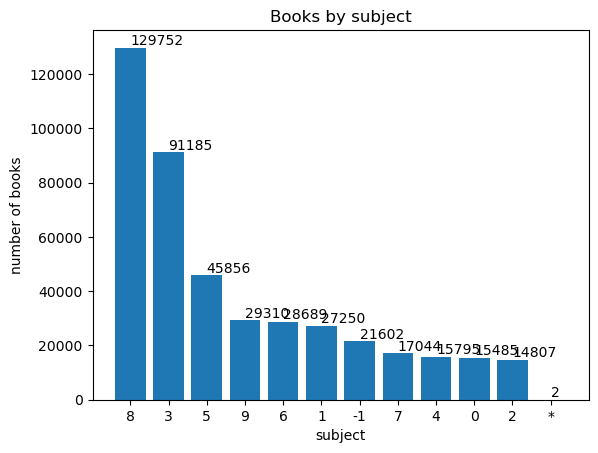

In [106]:
#bar() 함수는 plot() 함수와 매우 유사합니다. x축의 값과 막대 높이에 해당하는 y축의 값을 전달하면 됩니다. 그 외의 제목, 축 이름 등을 표시하는 방법은 동일합니다.
#여기서는 annotate() 함수로 y축의 값을 표시할 때 텍스트 위치를 xytext=(0,2)로 지정하겠습니다. 막대 그래프이므로 y축 방향으로만 2포인트씩 간격을 띄우겠습니다.
plt.bar(count_by_subject.index, count_by_subject.values)    #x축에는 인덱스인 주제분류번호, y축에는 도서 개수를 전달합니다. 
plt.title('Books by subject')
plt.xlabel('subject')
plt.ylabel('number of books')
for idx, val in count_by_subject.items():
    plt.annotate(val, (idx, val), xytext=(0,2), textcoords='offset points')
plt.show()

### 덱스트 정렬, 막대 조절 및 색상 바꾸기
텍스트위치 조절은 annotate() 함수의 ha 매개변수에 'center'를 지정하면 됩니다. 기본값이 'right'이기 때문에 지정하지 않으면 텍스트가 오른쪽으로 정렬되고, 'left'로 지정하면 텍스트가 왼쪽으로 정렬됩니다.
또한 텍스트가 서로 겹치는 경우가 있으므로 fontsize 매개변수로 텍스트 크기를 줄여줍니다. 텍스트 색깔는 color 매개변수로 변경합니다. 

bar() 함수는 막대의 두께를 조절하는 width 매개변수를 제공하고, 기본값은 0.8입니다.

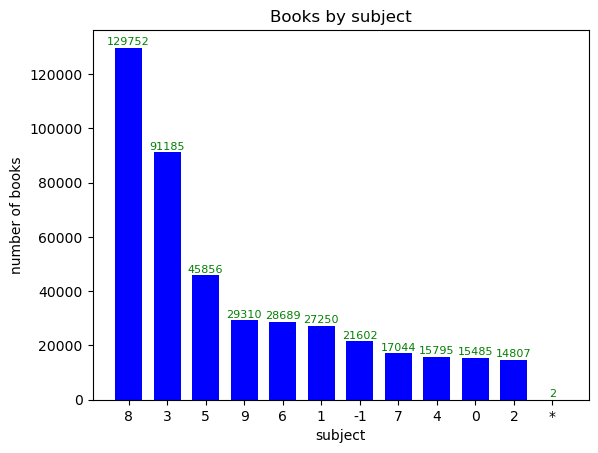

In [107]:
plt.bar(count_by_subject.index, count_by_subject.values, width=0.7, color='blue')      #너비와 막대색상 변경 
plt.title('Books by subject')
plt.xlabel('subject')
plt.ylabel('number of books')
for idx, val in count_by_subject.items():
    plt.annotate(val, (idx, val), xytext=(0,2), textcoords='offset points', fontsize=8, ha='center', color='green')   #텍스트의 크기, 위치, 색상 변경
plt.show()
#width 매개변수를 1로 지정하면 막대의 두께가 눈금 간격과 동일해져서 막대 사이의 간격이 사라집니다.

In [108]:
#정리- 막대 그래프의 텍스트 옵션은 annotate() 함수의 매개변수로, 막대 옵션은 bar() 함수의 매개변수를 활용합시다!

### 가로 막대 그래프 그리기
이번에는 barh() 함수를 사용해 같은 데이터를 가로 막대 그래프로 그려 보겠습니다. barh() 함수에서 막대의 두께를 나타내는 매개변수는 width가 아니라 height 매개변수가 됩니다. 
또 x축과 y축의 이름을 바꿔야 하고, annotate() 함수에 텍스트 좌표를 쓸 때도 x축과 y축 값이 바뀝니다.

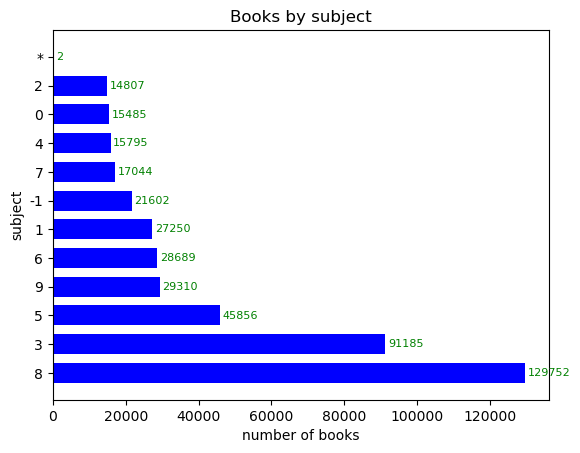

In [109]:
plt.barh(count_by_subject.index, count_by_subject.values, height=0.7, color='blue')     #width-> height
plt.title('Books by subject')
plt.ylabel('subject')
plt.xlabel('number of books')
for idx, val in count_by_subject.items():
    plt.annotate(val, (val, idx), xytext=(2,0), textcoords='offset points', fontsize=8, va='center', color='green') 
    #(idx, val)이 아니라 (val, idx), xytext도 역으로, ha가 아니라 va(그래프의 텍스트를 막대 중앙에 정렬)
plt.show()
#va 매개변수의 기본값은 'baseline'으로 텍스트 밑면이 막대 중앙이고, 이외에 'top'(위로 정렬), 'bottom'(아래로 정렬)이 있음.

# ch6. 복잡한 데이터 표현하기

## 6-1 객체지향 API로 그래프 꾸미기
지금까지 맷플롯립을 사용하여 가장 기본적인 그래프를 그리는 방법을 알아보았다면, 이번 절에서는 복잡한 그래프를 표현하기에 좋은 객체지향 API 방식을 알아보겠습니다.

### pyplot 방식과 객체지향 API 방식
사실 그래프를 그리는 방법은 두 가지입니다. matplotlib.pyplot에 있는 함수를 사용하는 pyplot 방식, 

그리고 명시적으로 피겨 객체와 서브플롯 객체를 만들고 이 객체의 메서드를 사용하는 객체지향 API 방식입니다.

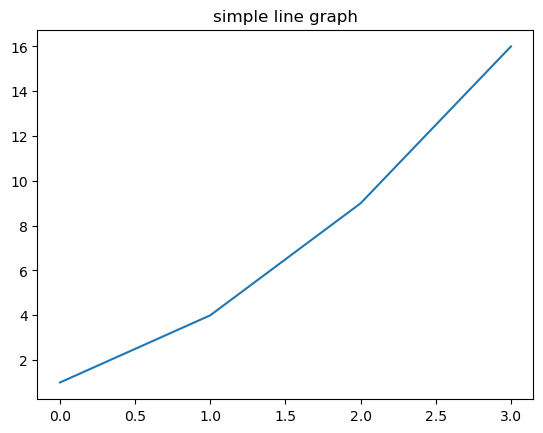

In [110]:
#pyplot 방식으로 그래프 그리기- matplotlib.pyplot의 함수들은 하나의 피겨 객체에 대한 상태를 공유합니다.
#즉, 다음과 같이 선 그래프를 그리면 plot() 함수와 title()함수는 동일한 파겨 객체에 적용됩니다. 
#plot() 함수에 리스트 형태로 데이터를 전달하고, title() 함수에는 그래프 제목을 넣어 그리는 것이지요.
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=100    #해상도 높이기

plt.plot([1,4,9,16])
plt.title('simple line graph')
plt.show()

In [111]:
#plot() 함수에 전달한 인덱스가 x축, 원소가 y축인 선 그래프가 그려집니다. 
#여기서 잠깐- plot() 함수에 하나의 리스트만 전달해도 그래프가 그려지나요? 일반적으로 plot() 함수를 사용할 떄 x축과 y축 값을 리스트나 배열로 전달합니다. 
#만약 하나의 리스트만 전달한다면 원소를 y축의 값이라고 인식하고 리스트의 인덱스를 x축의 값으로 사용합니다.
#앞의 예의 경우 [1,4,9,16]는 y축 값이며, x축의 값은 [0,1,2,3]이 됩니다.

C:\Users\User\AppData\Local\Temp\ipykernel_3556\3604223355.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


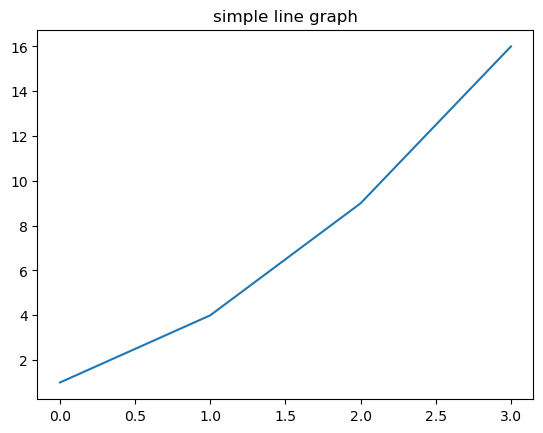

In [112]:
#객체지향 API 방식으로 그래프 그리기- 동일한 그래프를 피겨 객체와 Axes 객체를 사용하는 객체지향 API 방식으로 다시 그려봅시다.
fig, ax=plt.subplots()     #하나의 Axes 객체를 가지는 피겨를 생성합니다. fig라는 도화지에 ax라는 실제 그래프를 그린다고 생각하세요. 여러 개면 (1,2) 이렇게
ax.plot([1,4,9,16])        # ax.plot() → axes에 그린다
ax.set_title('simple line graph')
fig.show()

In [113]:
#복잡한 그래프를 그리는 경우에는 객체지향 방식을 사용하는 것이 좋습니다. 특히 하나의 피겨에 여러 개의 서브플롯을 추가하는 경우가 그렇습니다.

### 그래프에 한글 출력하기
객체지향 API로 본격적으로 그래프를 꾸며보기 전에 그래프 설정 하나를 더 배우고 넘어가겠습니다. 맷플롯립의 기본 폰트는 한글을 지원하지 않는데요, 한글 텍스트를 표시하는 법을 알아보겠습니다.

In [114]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=100     #해상도

In [115]:
#폰트 지정하기(1): font.family 속성
plt.rcParams['font.family']     #맷플롯립의 기본 폰트는 영문 sans-serif 폰트입니다.

['sans-serif']

In [116]:
#나눔고딕 폰트로 변경합니다.
plt.rcParams['font.family']='NanumGothic'

In [117]:
#폰트 지정하기(2): rc() 함수
#위처럼 rcParams 객체를 사용해 맷플롯립의 기본값을 바꿀 수 있지만, 맷플롯립에서 제공하는 rc() 함수를 사용하여 설정을 바꿀 수도 있습니다.
#rc() 함수의 첫 번째 매개변수에는 설정할 그룹을 지정합니다. 'font.family'의 경우 font가 그룹이고 family는 그룹의 하위 속성입니다.
#따라서 rc() 함수 첫 번째 매개변수에는 그룹인 'font'를 지정하고 두 번째 매개변수에는 그룹 하위 속성을 지정합니다.
plt.rc('font', family='NanumBarunGothic')
plt.rc('font', family='NanumBarunGothic', size=11)     #rc() 함수는 한 그룹 내의 여러 설정을 동시에 지정할 수 있습니다.

In [118]:
#바뀐 내용은 rcParams 객체로 다시 확인해 볼 수 있습니다.
print(plt.rcParams['font.family'], plt.rcParams['font.size'])

['NanumBarunGothic'] 11.0


In [119]:
#여기서 잠깐- 맷플롯립에서 사용할 수 있는 폰트의 전체 목록을 알려면 어떻게 해야 하나요? 맷플롯립은 시스템에 설치된 폰트를 자동으로 감지하여 사용합니다. 
#다음처럼 findSystemFonts() 함수를 사용하면 맷플롯립이 찾은 폰트 목록을 볼 수 있습니다.
from matplotlib.font_manager import findSystemFonts
findSystemFonts()

['C:\\Windows\\Fonts\\phagspa.ttf',
 'C:\\Windows\\Fonts\\consolai.ttf',
 'C:\\Windows\\Fonts\\HMFMPYUN.TTF',
 'C:\\Windows\\Fonts\\msgothic.ttc',
 'C:\\Windows\\Fonts\\Candaral.ttf',
 'C:\\Windows\\Fonts\\msyhbd.ttc',
 'C:\\Windows\\Fonts\\timesi.ttf',
 'C:\\Windows\\Fonts\\segoeui.ttf',
 'C:\\Windows\\Fonts\\comic.ttf',
 'C:\\Windows\\Fonts\\DUBAI-REGULAR.TTF',
 'C:\\Windows\\Fonts\\times.ttf',
 'C:\\Windows\\Fonts\\malgunbd.ttf',
 'C:\\Windows\\Fonts\\LeelaUIb.ttf',
 'C:\\Windows\\Fonts\\couri.ttf',
 'C:\\Windows\\Fonts\\SitkaVF-Italic.ttf',
 'C:\\Windows\\Fonts\\NotoSansKR-VF.ttf',
 'C:\\Windows\\Fonts\\MTEXTRA.TTF',
 'C:\\Windows\\Fonts\\MSUIGHUR.TTF',
 'C:\\Windows\\Fonts\\GOTHICB.TTF',
 'C:\\Windows\\Fonts\\ariblk.ttf',
 'C:\\Windows\\Fonts\\seguisli.ttf',
 'C:\\Windows\\Fonts\\segoeuib.ttf',
 'C:\\Windows\\Fonts\\micross.ttf',
 'C:\\Windows\\Fonts\\seguibli.ttf',
 'C:\\Users\\User\\AppData\\Local\\Microsoft\\Windows\\Fonts\\NanumBarunGothicUltraLight.otf',
 'C:\\Windows\\Fonts\

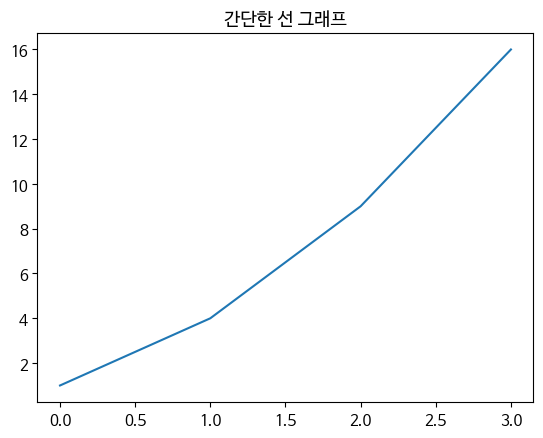

In [120]:
#이제 앞서 출력해 본 간단한 그래프를 그려 그래프 제목을 한글로 출력해 봅시다!
plt.plot([1,4,9,16])
plt.title('간단한 선 그래프')
plt.show()
#실전에서는 폰트 다운 후에 주피터 종료후 재시작 하셔야 됩니다~

### 출판사별 발행 도서 개수 산점도 그리기

In [121]:
import pandas as pd
ns_book7=pd.read_csv('ns_book7.csv', low_memory=False)
ns_book7.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,페스트,알베르 카뮈 지음 ;김화영 옮김,민음사,2020,9788937462672,NaN,NaN,267,808,1,181,2025-12-31
1,2,앤서니 브라운의 행복한 미술관,"앤서니 브라운 글 그림, 서애경 옮김",웅진씽크빅,2004,9788901044873,NaN,NaN,NaN,843,1,0,2025-12-31
2,4,지구를 여행하는 히치하이커를 위한 안내서,"아이작 유엔 지음, 성소희 옮김",학산문화사,2025,9791141162504,NaN,NaN,NaN,NaN,1,0,2025-12-31
3,5,독서에도 교육이 필요하다면,최소희.이승화 지음,인품,2020,9791196594213,NaN,NaN,NaN,NaN,1,0,2025-12-31
4,6,쌀 재난 국가,이철승 지음,문학과지성사,2021,9788932038001,NaN,NaN,NaN,NaN,1,0,2025-12-31


In [122]:
#연도를 기준으로 출판사별 발행 도서 개수를 표현해야 하므로 x축에는 '발행년도', y축에는 '출판사'를 표시해야 합니다.
#이 데이터에 있는 전체 출판사 수를 모두 그래프에 표현하기는 어려우니 발행 도서가 많은 상위 30개 출판사의 데이터 중 일부를 사용하겠습니다.

#고유한 출판사 목록 만들기: value_counts() 메서드(카운트가 높은 순으로 결과를 내림차순 정렬)
top30_pubs=ns_book7['출판사'].value_counts()[:30]    #슬라이스 연산자로 30개 선택. 마지막 인덱스는 범위에 포함되지 않으므로 가져오려는 인덱스+1로 지정해야 함 주의
top30_pubs

출판사
문학동네        5507
민음사         3986
김영사         3922
웅진씽크빅       3375
창비          3175
시공사         2886
위즈덤하우스      2619
문학과지성사      2496
학지사         1945
열린책들        1770
한길사         1604
한국학술정보      1583
자음과모음       1568
길벗          1566
한울          1556
커뮤니케이션북스    1547
살림출판사       1497
비룡소         1482
지식을만드는지식    1480
다산북스        1437
넥서스         1408
博英社         1357
황금가지        1334
한빛미디어       1317
랜덤하우스코리아    1315
책세상         1143
현암사         1140
소명출판        1121
한국문화사       1096
시그마프레스      1070
Name: count, dtype: int64

In [123]:
#이제 ns_book7 데이터프레임에서 상위 30개 출판사에 해당하는 행을 표시하는 불리언 인덱스를 만들어 보죠.
#어떤 행의 출판사가 top30_pubs 목록에 있는 출판사 중 하나에 해당하는지 검사하려면 isin() 메서드를 사용할 수 있습니다.
#isin() 메서드에 값을 전달하면 데이터프레임에서 일치하는 값을 찾아 불리언 배열로 반환합니다.
top30_pubs_idx=ns_book7['출판사'].isin(top30_pubs.index)    #30개에 해당하면 True, 아닌 출판사는 False로 반환
top30_pubs_idx

0          True
1          True
2         False
3         False
4          True
          ...  
436772    False
436773    False
436774    False
436775    False
436776    False
Name: 출판사, Length: 436777, dtype: bool

In [124]:
#상위 30개 출판사의 발행 도서 개수가 총 몇 개인지 세어 볼까요?- 시리즈 객체에서 sum() 메서드를 호출하면 값ㅇ르 모두 더합니다.
#(값이 불리언일 경우 True는 1, False는 0으로 처리되므로 불리언 배열에서 True인 원소의 개수를 헤아릴 수 있습니다.)
top30_pubs_idx.sum()

np.int64(59302)

In [125]:
#산점도로 그리기에는 여전히 많기 때문에 이 중 1000개만 선택해 보겠습니다. "데이터프레임의 행을 무작위로 선택하려면 sample() 메서드를 사용합니다."
#sample() 메서드의 첫 번째 매개변수에 무작위로 선택할 행 개수를 지정하고, random_state 매개변수에 임의의 숫자를 적습니다.(넘파이의 seed() 함수와 비슷한 역할)
#(따라서 예시와 동일한 값을 전달하면 항상 같은 결과를 얻을 수 있습니다.)
ns_book8=ns_book7[top30_pubs_idx].sample(1000, random_state=42)
ns_book8.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
214439,230165,(효과적인 영어교수를 위한) 외래어 활용 방안 :영어 어휘 교육용 프로그램의 개발과...,천승미 지음,한국학술정보,2012,9788926833353,NaN,9,NaN,740.7,1,5,2012-07-23
359592,379594,"월드컵, 그 열정의 사회학",안민석;정준영 [같이]엮음,한울,2002,9788946030602,NaN,9,NaN,331,1,2,2005-10-14
64261,68566,굴욕을 대하는 태도:역사를 움직인 16인의 굴욕 연대기,"공원국,박찬철 지음",위즈덤하우스,2020,9791191119404,NaN,0,NaN,909,1,7,2020-11-15
52179,55653,달콤한 복수 주식회사(스마트2),"요나스 요나손 지음, 임호경 옮김",열린책들,2021,9788932921433,NaN,NaN,NaN,NaN,2,8,2021-10-25
135053,144113,김영랑 시선,김영랑 지음 ;홍용희 엮음,지식을만드는지식,2014,9788966803804,NaN,0,71,808.1,1,2,2016-10-25


C:\Users\User\AppData\Local\Temp\ipykernel_3556\279683150.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


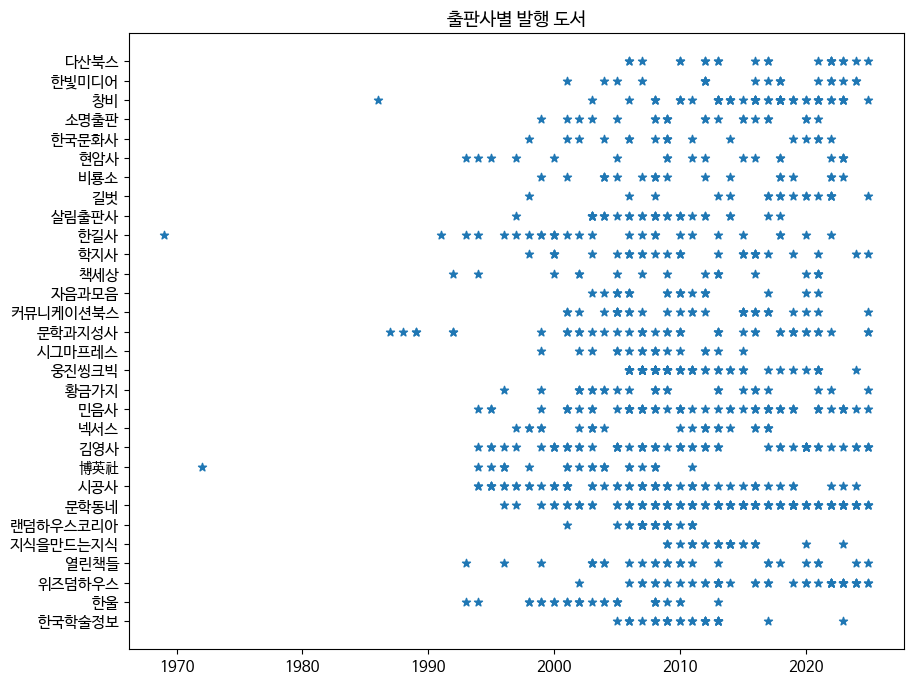

In [126]:
#이제 산점도를 그려 보겠습니다.. x축에는 '발행년도'열, y축에는 '출판사'열을 지정합니다.
fig, ax=plt.subplots(figsize=(10,8))    #피겨 크기 키우기
ax.scatter(ns_book8['발행년도'], ns_book8['출판사'])
ax.set_title('출판사별 발행 도서')
fig.show()

In [127]:
import matplotlib.font_manager as fm

for f in fm.findSystemFonts():
    if "Nanum" in f:
        print(f)

C:\Users\User\AppData\Local\Microsoft\Windows\Fonts\NanumBarunGothicUltraLight.otf
C:\Users\User\AppData\Local\Microsoft\Windows\Fonts\NanumBarunGothicLight.otf
C:\Users\User\AppData\Local\Microsoft\Windows\Fonts\NanumBarunGothic.otf
C:\Users\User\AppData\Local\Microsoft\Windows\Fonts\NanumBarunGothicBold.ttf
C:\Users\User\AppData\Local\Microsoft\Windows\Fonts\NanumBarunGothicLight.ttf
C:\Users\User\AppData\Local\Microsoft\Windows\Fonts\NanumBarunGothicBold.otf
C:\Users\User\AppData\Local\Microsoft\Windows\Fonts\NanumBarunGothic.ttf
C:\Users\User\AppData\Local\Microsoft\Windows\Fonts\NanumBarunGothicUltraLight.ttf


C:\Users\User\AppData\Local\Temp\ipykernel_3556\1369990819.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


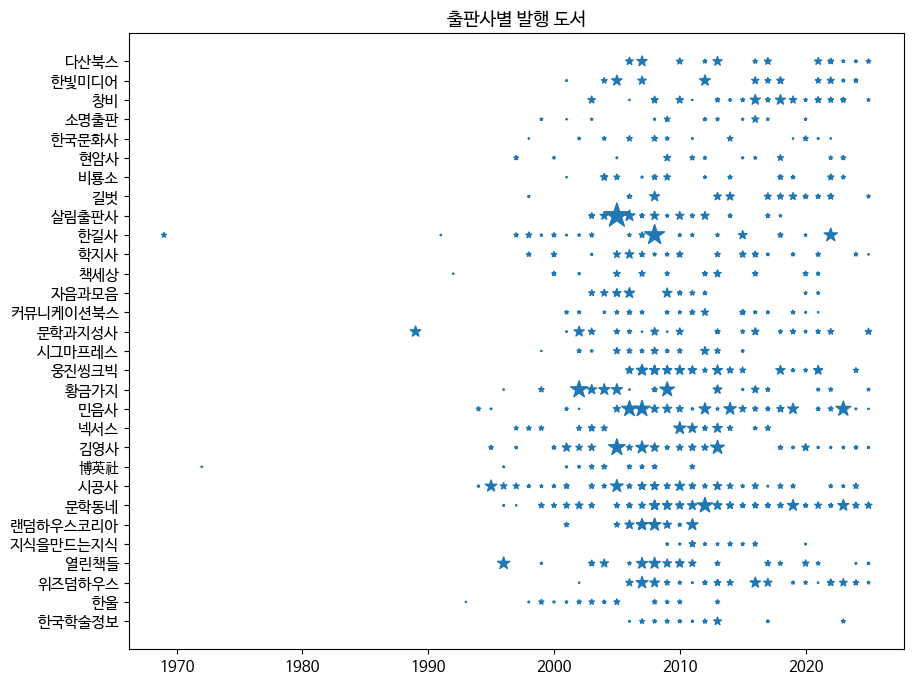

In [129]:
#값에 따라 마커 크기를 다르게 나타내기- 어떤 해에 얼마나 많은 도서가 대출되었는지는 알 수 없으니 이를 개선해 보겠습니다.
#scatter() 함수는 마커의 크기를 지정할 수 있는 s 매개변수를 제공합니다. 선 그래프와 산점도의 마커 크기는 rcParams['lines.markersize']로 지정하며 기본값은 6입니다.
#(s 매개변수의 기본값은 rcParams['lines.markersize']의 제곱을 사용합니다.)
#s 매개변수 값을 하나의 실수로 바꾸면 산점도의 모든 마커 크기가 동일하게 바뀝니다. 
#"하지만 입력 데이터와 동일한 길이의 배열을 지정하면 각 데이터마다 마커의 크기가 다른 산점도를 그릴 수 있습니다."
#다음처럼 '대출건수' 열을 마커 크기로 전달하여 대출건수가 많은 도서를 상대적으로 크게 그릴 수 있습니다.
fig, ax=plt.subplots(figsize=(10,8))
ax.scatter(ns_book8['발행년도'], ns_book8['출판사'], s=ns_book8['대출건수'])    #⭐⭐⭐
ax.set_title('출판사별 발행 도서')
fig.show()

In [130]:
#결과- 이 산점도는 각 출판사의 연도별 도서 발행 여부뿐만 아니라 얼마나 많은 대출을 기록했는지도 보여줍니다.
#정리- scatter() 함수의 s 매개변수에 실수를 전달하면 마커 크기를 조절할 수 있습니다. 
# ⭐⭐⭐입력 데이터와 동일한 길이의 배열을 전달하면 배열에 있는 값에 따라 마커 크기가 바뀝니다.

### 마커 꾸미기- 다양한 매개변수를 활용해 봅시다.
1. 투명도 조절하기: alpha 매개변수
2. 마커 테두리 색 바꾸기: edgecolor 매개변수, 기본값은 마커의 색을 의미하는 'face'입니다. 테두리를 그리면 마커가 겹칠 때 경계를 구분할 수 있죠.
3. 마커 테두리 선 두께 바꾸기: linewidths 매개변수, 기본값은 1.5입니다.
4. 산점도 색 바꾸기: c 매개변수, s 매개변수와 마찬가지로 c 매개변수에 데이터 개수와 동일한 길이의 배열을 전달하면 각 데이터를 다른 색깔로 그릴 수 있습니다.

C:\Users\User\AppData\Local\Temp\ipykernel_3556\2018322428.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


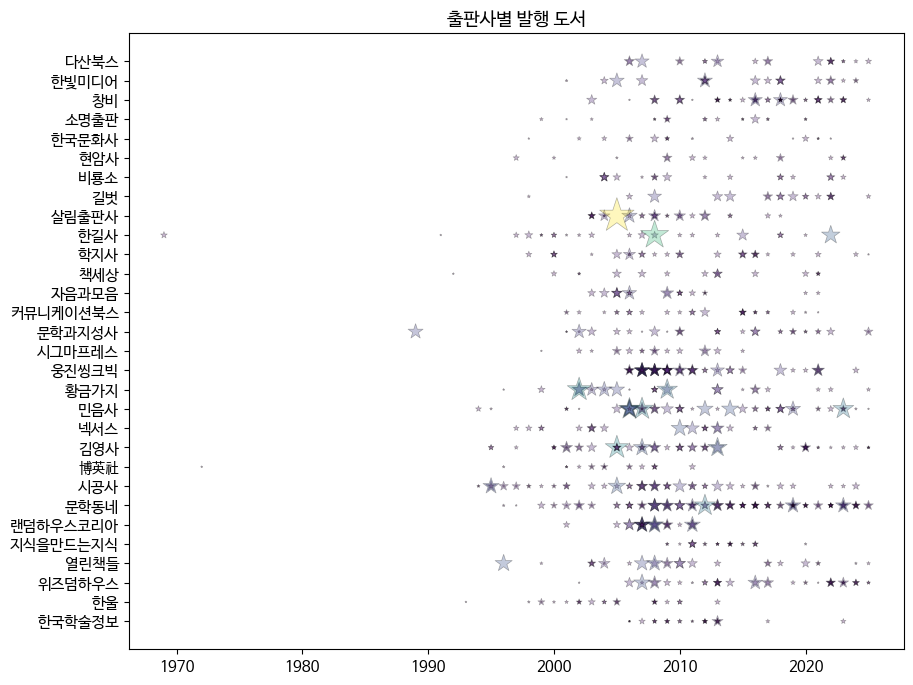

In [132]:
fig, ax=plt.subplots(figsize=(10,8))
ax.scatter(ns_book8['발행년도'], ns_book8['출판사'], linewidths=0.5, edgecolors='k', alpha=0.3, s=ns_book8['대출건수']*2, c=ns_book8['대출건수'])
ax.set_title('출판사별 발행 도서')
fig.show()
#'k'는 검은색, s 매개변수는 대출건수 제곱으로 수정하여 마커의 크기가 눈에 더 잘 띄도록 합시다.

### 값에 따라 색상 표현하기: 컬러맵
맷플롯립은 컬러맵을 사용하여 값에 따른 색상을 다르게 표현합니다. 앞서 그린 산점도는 scatter() 함수가 사용하는 기본값인 viridis 컬러맵으로 표현되었습니다.
자주 사용하는 컬러맵 중 하나는 jet 컬러맵입니다. jet 컬러맵은 낮은 값일수록 짙은 파란색이고, 높은 값일수록 점차 노란색으로 바뀌었다가 붉은색이 됩니다.

C:\Users\User\AppData\Local\Temp\ipykernel_3556\3989044062.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


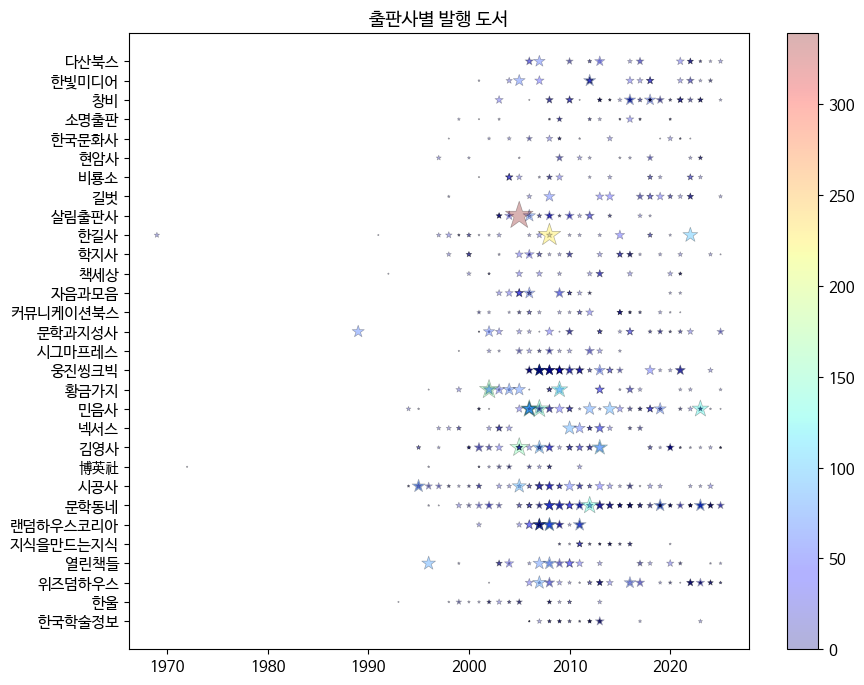

In [134]:
#산점도를 jet 컬러맵으로 다시 그려 보겠습니다. 그리고 컬러맵의 색깔이 어떤 대출건수 값에 대응하는지 참조 정보를 제공하는 컬러 막대를 그래프 옆에 그려 주겠습니다.
#컬러맵은 cmap 매개변수로 지정할 수 있고, 컬러 막대는 scatter() 함수가 반환하는 객체를 colorbar() 메서드에 전달하면 됩니다.
fig, ax=plt.subplots(figsize=(10,8))
sc=ax.scatter(ns_book8['발행년도'], ns_book8['출판사'], linewidths=0.5, edgecolors='k', alpha=0.3, s=ns_book8['대출건수']*1.3, c=ns_book8['대출건수'], cmap='jet')
ax.set_title('출판사별 발행 도서')
fig.colorbar(sc)
fig.show()
#❗matplotlib.pyplot을 사용하는 경우에는 매개변수 없이 plt.clolorbar()를 호출하면 자동으로 현재 피겨의 서브플롯에 컬러 막대가 추가됩니다.

In [135]:
#그러나 마커 크기는 데이터를 교모하게 왜곡시킬 수 있다는 것을 주의해야 합니다. 마커 크기를 사용해 데이터를 표현한다면 어떤 방식인지 정보를 제공하는 것이 좋습니다.

## 6-2 맷플롯립의 고급 기능 배우기
(범례, 피벗 테이블. 스택 영역 그래프, 스택 막대 그래프, 원 그래프)
이번 절에서는 하나의 피겨에 여러 개의 그래프를 그려 보고, 데이터가 명확하게 표현되도록 맷플롯립의 고급 기능을 알아보겠습니다. 또한 서브플롯을 활용하여 하나의 피겨에 다양한 그래프를 한 번에 그리는 방법을 알아보겠습니다.

In [136]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')     #나눔바른고딕 폰트로 설정합니다.
plt.rcParams['figure.dpi']=100        #그래프 dpi 기본값을 변경합니다.

In [138]:
#csv 데이터 파일을 읽고 판다스 데이터프레임으로 불러 옵니다. 
import pandas as pd
ns_book7=pd.read_csv('ns_book7.csv', low_memory=False)
ns_book7.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,페스트,알베르 카뮈 지음 ;김화영 옮김,민음사,2020,9788937462672,NaN,NaN,267,808,1,181,2025-12-31
1,2,앤서니 브라운의 행복한 미술관,"앤서니 브라운 글 그림, 서애경 옮김",웅진씽크빅,2004,9788901044873,NaN,NaN,NaN,843,1,0,2025-12-31
2,4,지구를 여행하는 히치하이커를 위한 안내서,"아이작 유엔 지음, 성소희 옮김",학산문화사,2025,9791141162504,NaN,NaN,NaN,NaN,1,0,2025-12-31
3,5,독서에도 교육이 필요하다면,최소희.이승화 지음,인품,2020,9791196594213,NaN,NaN,NaN,NaN,1,0,2025-12-31
4,6,쌀 재난 국가,이철승 지음,문학과지성사,2021,9788932038001,NaN,NaN,NaN,NaN,1,0,2025-12-31


### 하나의 피겨에 여러 개의 선 그래프 그리기
한 피겨에 여러 개의 선 그래프를 그려야 할 때가 있습니다. 예를 들면 회사의 제품별 매출 현황을 비교하고 싶다면 x축을 연/월로 하고 y축을 매출로 합니다. 그리고 각 제춤의 매출 데이터를 선 그래프로 표시합니다.

맷플롯립에서 여러 개의 선 그래프를 그리는 방법은 의외로 간단합니다. 선 그래프를 그리는 plot() 함수를 여러 번 호출하는 것이 전부입니다.

In [139]:
#먼저 출판사에 대한 '발행년도'별 '대출건수' 그래프를 그리기 위해 데이터를 바꿔 보겠습니다.
top30_pubs=ns_book7['출판사'].value_counts()[:30]     #상위 30위 정도의 출판사 목록 생성
top30_pubs_idx=ns_book7['출판사'].isin(top30_pubs.index)       #상위 30위에 해당하는 출판사는 True로 표시하여 불리언 배열로 반환합니다.

In [142]:
#그다음 ns_book7 데이터프레임에서 상위 30위에 해당하는 '출판사', '발행년도', '대출건수' 열만 추출하여 ns_book9를 만들어 줍니다.
ns_book9=ns_book7[top30_pubs_idx][['출판사','발행년도','대출건수']]

In [143]:
#이제 groupby() 메서드를 사용해 '출판사'와 '발행년도'열을 기준으로 행을 모은 후 sum() 메서드로 '대출건수' 열의 합을 구해 줍니다. 
#(출판사마다 연도별 대출건수를 나타내기 위해 같은 연도의 개출건수는 합쳐 줍니다.)
ns_book9=ns_book9.groupby(by=['출판사','발행년도']).sum()
#이 데이터프레임의 인덱스는 '출판사'와 '발행년도'열입니다.

In [145]:
#인덱스를 초기화하기 위해 reset_index() 메서드를 호출하겠습니다.
ns_book9=ns_book9.reset_index()
ns_book9[ns_book9['출판사']=='황금가지'].head()     #'황금가지'라는 출판사의 데이터를 통해 연도별로 대출건수가 잘 집계됨을 확인해봅시당.

,출판사,발행년도,대출건수
1059,황금가지,1969,6
1060,황금가지,1970,39
1061,황금가지,1986,11
1062,황금가지,1995,2
1063,황금가지,1996,70


### 선 그래프 2개 그리기

In [146]:
#2개의 출판사 데이터를 만드러 '발행년도'에 대한 '대출건수' 선 그래프를 그려 보겠습니다. 출판사 별로 각각 데이터프레임을 만듭니다.
line1=ns_book9[ns_book9['출판사']=='황금가지']
line2=ns_book9[ns_book9['출판사']=='비룡소']

C:\Users\User\AppData\Local\Temp\ipykernel_3556\1408699841.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


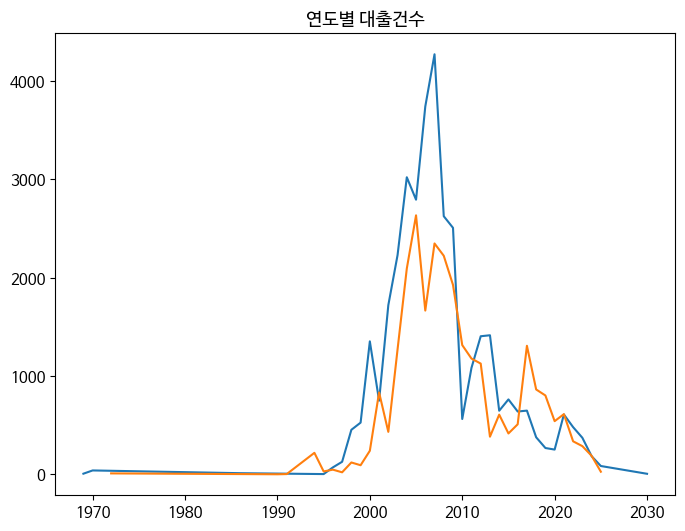

In [147]:
#그다음 line1과 line2 데이터프레임의 '발행년도'열과 '대출건수' 열로 plot() 함수를 두 번 호출합니다.
fig, ax=plt.subplots(figsize=(8,6))
ax.plot(line1['발행년도'], line1['대출건수'])       #'황금가지' 출판사 선 그래프
ax.plot(line2['발행년도'], line2['대출건수'])       #'비룡소' 출판사 선 그래프
ax.set_title('연도별 대출건수')
fig.show()

In [148]:
#위 그래프에서 파란색이 '황금가지' 출판사의 그래프이고, 노란색이 '비룡소' 출판사의 그래프입니다. 
#맷플롯립은 plot() 함수를 호출할 떄 별도로 색을 지정하지 않아도 자동으로 선 그래프마다 다른 색으로 그립니다. 10개 이상의 선을 그리게 되면 색을 반복 사용합니다.

C:\Users\User\AppData\Local\Temp\ipykernel_3556\897100635.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


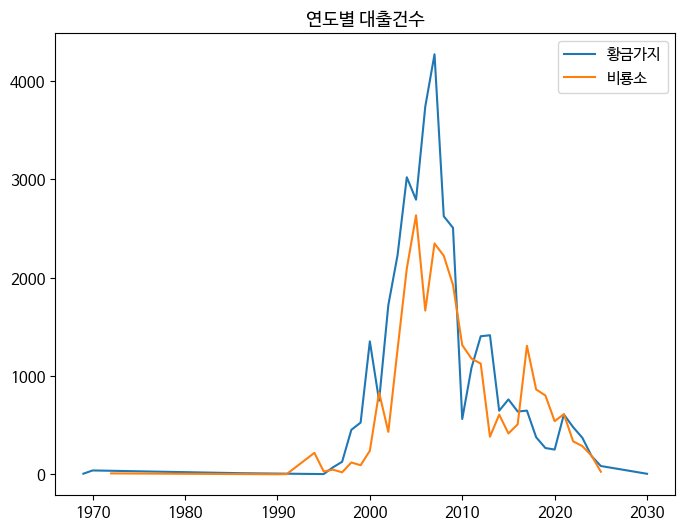

In [149]:
#더 많은 선 그래프를 그릴 때는 그래프에 범례(legend)를 추가하면 그래프를 이해하는 데 도움이 됩니다. 
#plot() 힘수를 호출할 때 각 선 그래프에 레이블을 추가하고, 마지막에 legend() 메서드를 호출하면 범례가 추가됩니다.
fig, ax=plt.subplots(figsize=(8,6))
ax.plot(line1['발행년도'], line1['대출건수'], label='황금가지')       #'황금가지' 레이블 추가
ax.plot(line2['발행년도'], line2['대출건수'], label='비룡소')       #'비룡소' 레이블 추가
ax.set_title('연도별 대출건수')
ax.legend()          #⭐⭐⭐범례를 추가합니다.
fig.show()

C:\Users\User\AppData\Local\Temp\ipykernel_3556\2692940789.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


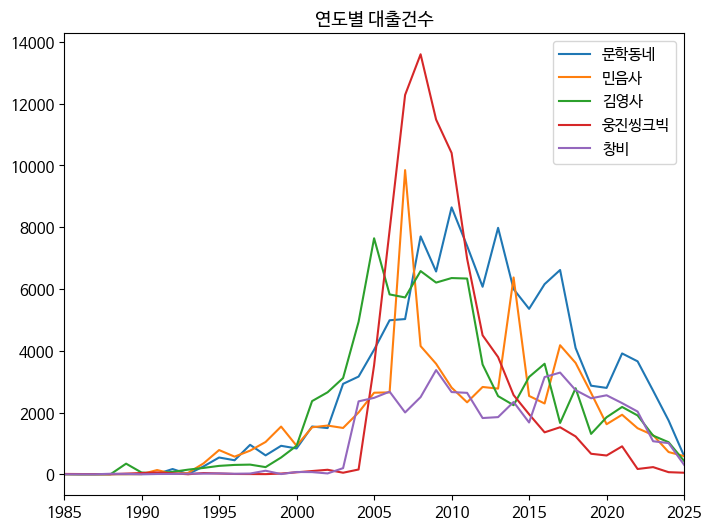

In [150]:
#선 그래프 5개 그리기- 코드는 위에서 한 것과 동일하지만, 5개 출판사에 대한 데이터프레임을 각각 만들지 않고 for문과 슬라이스 연산자를 사용해 선 그래프를 그립니다.
fig, ax=plt.subplots(figsize=(8,6))
for pub in top30_pubs.index[:5]:
    line=ns_book9[ns_book9['출판사']==pub]     #상위 5개 출판사가 선택됩니다.
    ax.plot(line['발행년도'], line['대출건수'], label=pub)     #5개 출판사에 대한 선 그래프를 그립니다. 
ax.set_title('연도별 대출건수')
ax.legend()
ax.set_xlim(1985, 2025)     #1985부터 2025까지 x축 범위를 선택합니다.
fig.show()

#x축 범위 지정은 set_xlim() 메서드, y축 범위 지정은 set_ylim() 메서드를 사용합니다.
#맷플롯립에서는 plt.xlim(), ply.ylim()이 되겠지용?

In [151]:
#범례를 추가했지만, 선 그래프들이 서로 많이 교차해 구분하기 쉽지 않습니다. 이런 경우에는 선 그래프보다는 스택 영역 그래프를 그리는 것이 좋겠습니다.

### 스택 영역 그래프
스택 영역 그래프는 말 그대로 하나의 선 그래프 위에 다른 선 그래프를 차례대로 쌓는 것입니다. 그래프 사이의 간격이 y축의 값이 됩니다.
이러한 스택 영역 그래프는 맷플롯립의 stackplot() 메서드로 그릴 수 있습니다.이 메서드는 첫 번째 매개변수에는 x축의 값인 '발행년도'를 전달하고, 두 번째 매개변수엔느 y축 값을 2차원 배열로 전달해야 합니다.

예를 들어 각 출판사의 연도별 대출건수를 그리려면 y축에 해당하는 2차원 배열은 행이 각 '출판사'에 해당하고 열은 '발행년도'로 구성합니다. 단계별로 정리하면 다음과 같습니다
1. pivot_table() 메서드로 각 '발행년도' 열의 값을 열로 바꾸기    #y축에 넣을 2차원 배열을 만듭니다.
2. '발행년도' 열을 리스트 형태로 바꾸기       #x축에 넣을 리스트를 만듭니다.
3. stackplot() 메서드로 스택 영역 그래프 그리기

In [152]:
#1. pivot_table() 메서드로 각 '발행년도' 열의 값을 열로 바꾸기
#하나의 열을 2차원 배열로 바꾸는 것처럼 데이터 구조를 바꾸는 방법은 판다스의 pivot_table() 메서드로 처리할 수 있습니다. (엑셀의 피벗 테이블과 유사)
#how? index 매개변수와 columns 매개변수에 언본 데이터프레임의 열을 지정하면 각 열의 고유한 값이 피벗 테이블로 변혼된 데이터프레임의 인덱스와 열이 됩니다.

#여기서는 index 매개변수에 '출판사'열, columns 매개변수에 '발행년도' 열을 지정해 보죠.
ns_book10=ns_book9.pivot_table(index='출판사', columns='발행년도')
ns_book10.head()

대출건수                                                 ...                  \
발행년도 1957 1960 1966 1968 1969 1970 1971 1972   1973 1974  ...    2017    2018   
출판사                                                       ...                   
博英社   NaN  NaN  NaN  9.0  NaN  0.0  NaN  1.0    NaN  NaN  ...     3.0    13.0   
길벗    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN    NaN  NaN  ...  2203.0  1660.0   
김영사   NaN  9.0  3.0  NaN  NaN  NaN  NaN  NaN  108.0  NaN  ...  1662.0  2786.0   
넥서스   NaN  NaN  NaN  NaN  NaN  NaN  NaN  2.0    NaN  NaN  ...  1158.0   873.0   
다산북스  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN    NaN  NaN  ...  1657.0  1306.0   

                                                                  
발행년도    2019    2020    2021    2022    2023    2024   2025 2030  
출판사                                                               
博英社      NaN    35.0     NaN     NaN     NaN     NaN    6.0  NaN  
길벗    1557.0  1506.0  1955.0  1608.0  1361.0  1013.0  394.0  NaN  
김영사   1308.0  1847.0  2180.0  1905.0  1252.0  1038.0  431.0  NaN  
넥서스    166.0   198.0   360.0   234.0   245.0   162.0   44.0  NaN  
다산북스  1198.0   745.0  1440.0  1317.0  1242.0   609.0  238.0  NaN  

[5 rows x 62 columns]

In [153]:
#기대한 대로 '발행년도' 열의 값이 하나의 열이 되었군요. 한 가지 눈 여겨 보아야 할 것은 열이 다단으로 구성되어 있다는 점입니다.
#첫 번째 열을 보면 1947이 아니라 ('대출건수', 1947)입니다. ns_book10의 columns 속성을 확인해 보면 쉽게 알 수 있습니다.
ns_book10.columns[:10]

MultiIndex([('대출건수', 1957),
            ('대출건수', 1960),
            ('대출건수', 1966),
            ('대출건수', 1968),
            ('대출건수', 1969),
            ('대출건수', 1970),
            ('대출건수', 1971),
            ('대출건수', 1972),
            ('대출건수', 1973),
            ('대출건수', 1974)],
           names=[None, '발행년도'])

In [154]:
#2.'발행년도' 열을 리스트 형태로 바꾸기- 이번에는 상위 10개의 출판사 이름과 x축에 놓을 '발행년도' 리스트를 준비해 볼까요?
#판다스 인덱스 개체에서 호출할 수 있는 get_level_values() 메서드는 다단으로 구성된 열 이름에서 선택한 항목만 가져올 수 있습니다.
top10_pubs=top30_pubs.index[:10]
year_cols=ns_book10.columns.get_level_values(1)      #('대출건수', 1947)로 되어있는 열 이름 중 연도로 구성된 두 번째 항목만 가져올 수 있습니다. 

C:\Users\User\AppData\Local\Temp\ipykernel_3556\3168624132.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


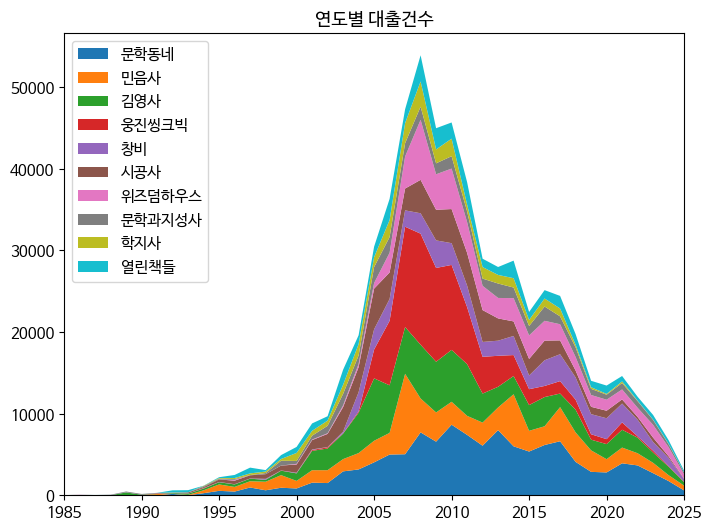

In [155]:
#3.stackplot() 메서드로 스택 영역 그래프 그리기- x축과 y축에 전달할 값이 준비되었습니다. 
#이제 stackplot() 메서드에 x축 값에는 year_color를, y축에는 ns_book10에서 상위 10개 출판사에 해당하는 행을 골라 전달합니다.
#legend() 메서드느느 loc 매개변수로 범례의 위치를 지정할 수 있습니다.
fig, ax=plt.subplots(figsize=(8,6))
ax.stackplot(year_cols, ns_book10.loc[top10_pubs].fillna(0), labels=top10_pubs)
ax.set_title('연도별 대출건수')
ax.legend(loc='upper left')      #범례를 왼쪽 상단에 표시합니다.
ax.set_xlim(1985, 2025)
fig.show()

In [156]:
#여기서 잠깐- 데이터프레임을 가져올 때 왜 fillna() 메서드를 사용하나요?- 맷플롯립은 판다스 데이터프레임의 누락된 값을 제대로 처리하지 못해 그래프가 
#이상하게 그려지는 경우가 이따금 있습니다. 이런 현상을 막기 위해 그래프를 그리기 전에 fillna() 메서드로 누락된 값을 0으로 채웠습니다. 
#또는 pivot_table() 메서드를 호출할 때 fill_value=0으로 지정하면 피벗 테이블을 만들 때 미리 누락된 값을 0으로 채울 수 있습니다. 

In [157]:
#지금까지는 연도별 대출건수를 선 그래프로 그려 보았습니다. 이번에는 막대 그래프를 사용해 여러 출판사의 데이터를 나타내는 방법을 알아보겠습니다~~

### 하나의 피겨에 여러 개의 막대 그래프 그리기
막대 그래프를 여러 개 그리는 방법도 선 그래프와 비슷하게 bar() 메서드를 여러 번 호출하면 됩니다. 

C:\Users\User\AppData\Local\Temp\ipykernel_3556\4203538169.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


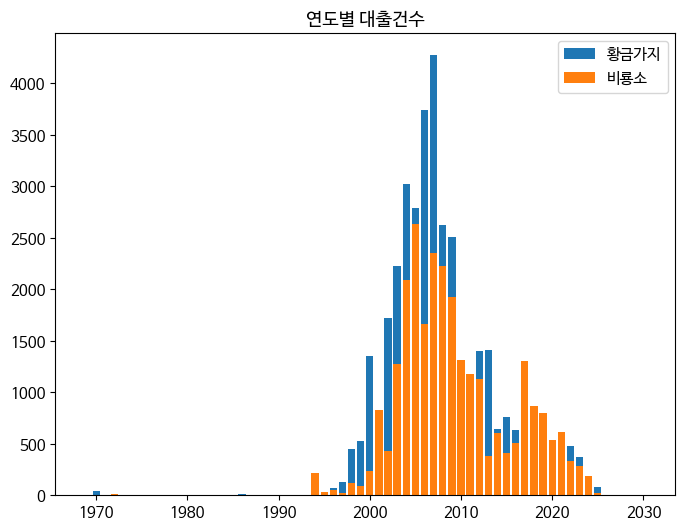

In [158]:
fig, ax=plt.subplots(figsize=(8,6))
ax.bar(line1['발행년도'], line1['대출건수'], label='황금가지')
ax.bar(line2['발행년도'], line2['대출건수'], label='비룡소')
ax.set_title('연도별 대출건수')
ax.legend()
fig.show()
#선 그래프와 달리 막대 그래프는 막대에 색이 채워집니다. 그래서 그냥 bar() 메서드를 연어어 호출하면 먼저 그린 막대를 덮어쓰게 되죠. 

C:\Users\User\AppData\Local\Temp\ipykernel_3556\1847739365.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


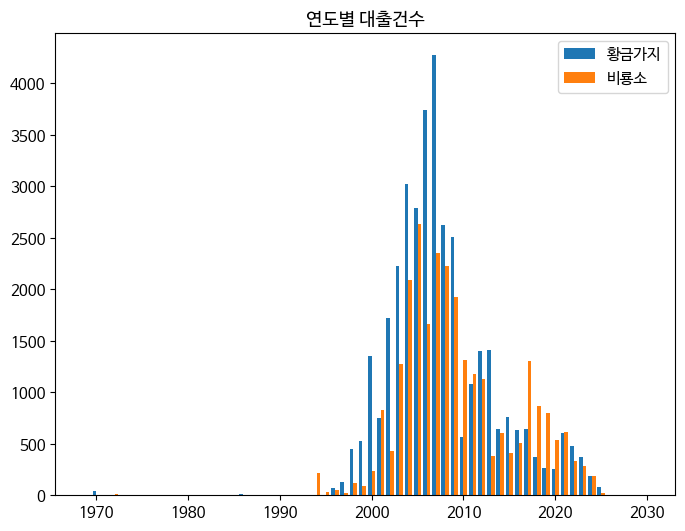

In [159]:
#두 출판사의 막대를 나란히 옆으로 그리려면 어떻게 해야 할까요? 막대의 기본 너비인 0.8의 절반인 0.4 너비로 두 막대 그래프를 그린 다음, x축에서 막대 하나
#너비인 0.4의 절반씩 떨어지도록 그려야 합니다. 
fig, ax=plt.subplots(figsize=(8,6))
ax.bar(line1['발행년도']-0.2, line1['대출건수'], width=0.4, label='황금가지')     #막대 너비를 지정합니다.
ax.bar(line2['발행년도']+0.2, line2['대출건수'], width=0.4, label='비룡소')       #막대 위치를 이동합니다.
ax.set_title('연도별 대출건수')
ax.legend()
fig.show()

### 스택 막대 그래프
막대 그래프를 옆으로 나란히 놓지 않고 스택 영역 그래프처럼 위로 쌓을 수도 있습니다. 이런 그래프를 스택 막대 그래프라고 합니다.
위로 쌓아 그리면 여러 개의 막대를 표현하는데 부담이 줄어듭니다. bar() 메서드의 bottom 매개변수를 사용하면 수동으로 막대를 쌓을 수 있습니다.
이 매개변수는 막대가 시작할 y좌표를 결정합니다.

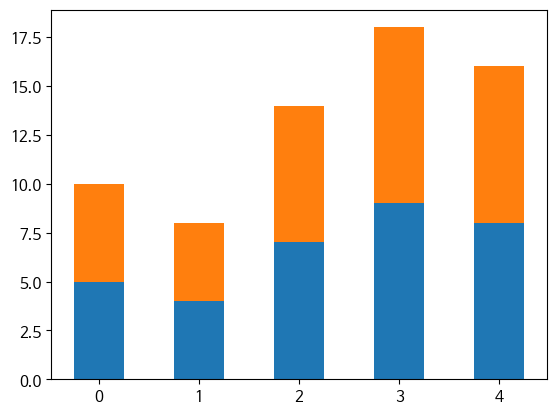

In [160]:
#간단한 두 개의 리스트 height1, height2를 만들어 height1 막대 그래프 위에 height2를 쌓아 보겠습니다.
height1=[5,4,7,9,8]
height2=[3,2,4,1,2]
plt.bar(range(5), height1, width=0.5)
plt.bar(range(5), height1, bottom=height1, width=0.5)    #height1 막대가 끝나는 위치에서 시작합니다.
plt.show()

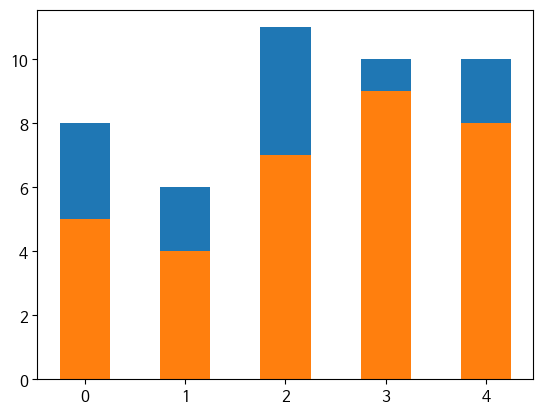

In [164]:
#막대 그래프를 잘 쌓았지만 그래프를 그릴 때마다 막대의 시작 위치를 계속 누적하여 보관해야 하기 때문에 조금 번거롭네요. 
#이번에는 그래프를 그리기 전에 아예 막대의 길이를 누적해 놓고 이 값으로 막대 그래프를 그리는 방법을 살펴보겠습니다. 
#다음처럼 height1과 height2를 더하여 height3를 만든 후, height3를 먼저 그리고 height1으르 그립니다. 
height3=[a+b for a,b in zip(height1, height2)]    #리스트 내포를 사용하고, zip() 함수로 양쪽의 데이터를 하나씩 엮어 줍니다.
plt.bar(range(5), height3, width=0.5)
plt.bar(range(5), height1, width=0.5)
plt.show()

In [165]:
#이처럼 각 출판사의 y축 값을 누적해 놓으면 간단하게 그래프를 그릴 수 있습니다.
#정리- 스택 영역 그래프를 그릴 때는 stackplot() 메서드를 사용하면 되지만, 스택 막대 그래프를 그릴 때는 bar() 메서드의 bottom 매개변수에 데이터를 전달하여
#막대를 쌓아 올리거나, y축 방향으로 데이터값을 누적하여 그려야 합니다. 

### 데이터값 누적하여 그리기
ns_book10 데이터프레임을 스택 막대 그래프로 그려 볼까요? 판다스 데이터프레임의 cumsum() 메서드를 사용하면 값을 누적하는 일은 아주 쉽습니다.

In [166]:
#사용법을 익히기 위해 먼저 ns_book10 데이터프레임에서 상위 다섯 개의 출판사의 2013~2020년 대출건수를 확인해 보겠습니다.
ns_book10.loc[top10_pubs[:5], ('대출건수', 2013):('대출건수', 2020)]

대출건수                                                        
발행년도     2013    2014    2015    2016    2017    2018    2019    2020
출판사                                                                  
문학동네   7980.0  5995.0  5357.0  6157.0  6615.0  4090.0  2868.0  2797.0
민음사    2774.0  6373.0  2537.0  2292.0  4179.0  3606.0  2634.0  1621.0
김영사    2531.0  2237.0  3152.0  3579.0  1662.0  2786.0  1308.0  1847.0
웅진씽크빅  3795.0  2564.0  1944.0  1358.0  1523.0  1226.0   664.0   608.0
창비     1851.0  2341.0  1677.0  3147.0  3293.0  2725.0  2461.0  2558.0

In [167]:
#그다음 동일한 데이터프레임에서 cumsum() 메서드를 이어서 호출해 보겠습니다.
ns_book10.loc[top10_pubs[:5], ('대출건수', 2013):('대출건수', 2020)].cumsum()
#발행 연도별 대출건수가 차례대로 누적된 것을 알 수 있습니다.
#cumsum() 메서드는 기본적으로 행을 따라 값을 누적합니다. axis 매개변수를 1로 지정하면 열 방향으로 누적할 수 있습니다. 

대출건수                                                             
발행년도      2013     2014     2015     2016     2017     2018    2019    2020
출판사                                                                        
문학동네    7980.0   5995.0   5357.0   6157.0   6615.0   4090.0  2868.0  2797.0
민음사    10754.0  12368.0   7894.0   8449.0  10794.0   7696.0  5502.0  4418.0
김영사    13285.0  14605.0  11046.0  12028.0  12456.0  10482.0  6810.0  6265.0
웅진씽크빅  17080.0  17169.0  12990.0  13386.0  13979.0  11708.0  7474.0  6873.0
창비     18931.0  19510.0  14667.0  16533.0  17272.0  14433.0  9935.0  9431.0

In [170]:
#따라서 ns_book10 데이터프레임 전체에 cumsum() 메서드를 적용하려면 다음과 같습니다.
ns_book12=ns_book10.loc[top10_pubs].cumsum()

C:\Users\User\AppData\Local\Temp\ipykernel_3556\1538772315.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


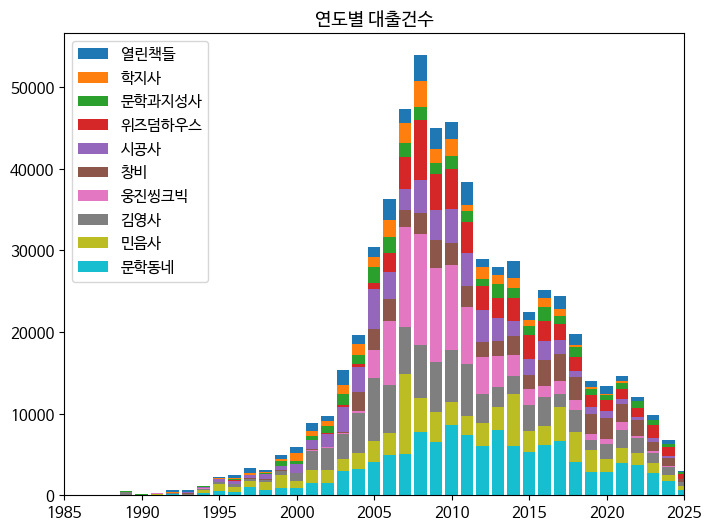

In [171]:
#누적 대출건수를 준비했으니 막대 그래프를 쌓는 작업은 간단합니다. 여기서 주의할 점은 가장 큰 막대를 머넞 그려야 한다는 점입니다. 그렇지 않으면 가장 큰
#막대가 이전에 그린 막대를 모두 덮어쓰게 됩니다. 파이썬의 range() 함수로 ns_book12 데이터프레임 행 개수만큼 인덱스 번호를 만들고, for문에 reversed() 함수
#를 사용해 인덱스의 역순으로 반복하여 그리면 성공입니다.
fig, ax=plt.subplots(figsize=(8,6))
for i in reversed(range(len(ns_book12))):      #reversed:가장 큰 막대부터 그려야 하므로 누적 합계가 가장 큰 마지막 출판사부터 그립니다.
    bar=ns_book12.iloc[i]      #행 추출
    label=ns_book12.index[i]     #출판사 이름 추출
    ax.bar(year_cols, bar, label=label)
ax.set_title('연도별 대출건수')
ax.legend(loc='upper left')
ax.set_xlim(1985, 2025)
fig.show()

### 원 그래프 그리기
원 그래프는 전체 데이터에 대항ㄴ 비율을 원의 부채꼴로 나타낸 그래프입니다. '파이 차트'라고도 부릅니다.

In [172]:
#전에 value_counts() 메서드로 상위 30개 출판사의 발행 도서 개수를 구했었는데요. 이를 원 그래프로 그려 보겠습니다.
#먼저 top30_pubs의 값과 인덱스에서 처음  10개만 선택하여 각각 data와 labels 변수에 저장합니다.
data=top30_pubs[:10]      #상위 10개 출판사의 도서 개수를 선택하여 저장합니다.
labels=top30_pubs.index[:10]       #상위 10개 출판사의 인덱스를 저장합니다.

C:\Users\User\AppData\Local\Temp\ipykernel_3556\1621259304.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


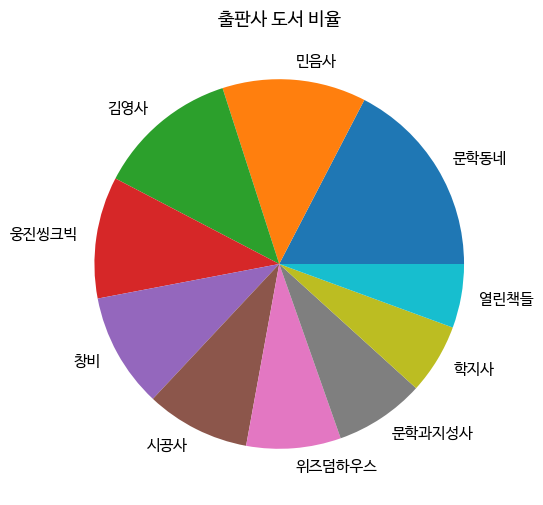

In [173]:
#원 그래프는 맷플롯립의 pie() 메서드로 그릴 수 있습니다. 이 메서드의 첫 번째 매개변수에 앞서 정의한 data를 전달하면 자동으로 데이터 전페에 대한 비율을 
#계산하여 그래프를 그립니다. 부채꼴 모양 위에 표시할 출판사 이름은 labels 매개변수에 전달합니다. 
fig, ax=plt.subplots(figsize=(8,6))
ax.pie(data, labels=labels)
ax.set_title('출판사 도서 비율')
fig.show()
#원 그래프는는 3시 방향부터 반시계 방향으로 데이터를 그립니다.

In [174]:
#원 그래프의 단점으로는 크기 순으롤 정렬되지 않은 데이터를 사용했다면 비율을 비교하기 어렵다는 것입니다.

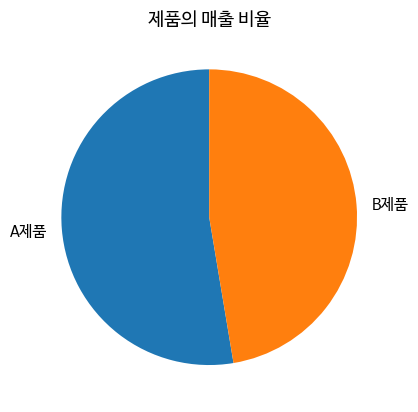

In [175]:
#다음으로 그려볼 원 그래프는 startangle 매개변수를 90으로 지정하여 12시 방향부터 그립니다.
plt.pie([10,9], labels=['A제품', 'B제품'], startangle=90)
plt.title('제품의 매출 비율')
plt.show()
#(+) pie() 메서드의 startangle 매개변수는 원 그래프의 시작 위치를 지정할 수 있습니다. 

### 비율 표시하고 부채꼴 강조하기
pie() 메서드의 autopct 매개변수에는 파이썬의 %연산자에 적용할 포맷팅 문자열을 전달할 수 있습니다. 예를 들어 %d를 전달하면 각 부채꼴의 비율이 정수로 표시됩니다. 
중요한 항목의 경우 해당 부채꼴 조각을 원 그래프에서 조금 떨어뜨려 시각적으로 부각시킬 수 있습니다. 이렇게 하려면 explode 매개변수에 떨어뜨리길 원하는 조각의 간격을 반지름의 비율로 지정합니다.

C:\Users\User\AppData\Local\Temp\ipykernel_3556\1083716613.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


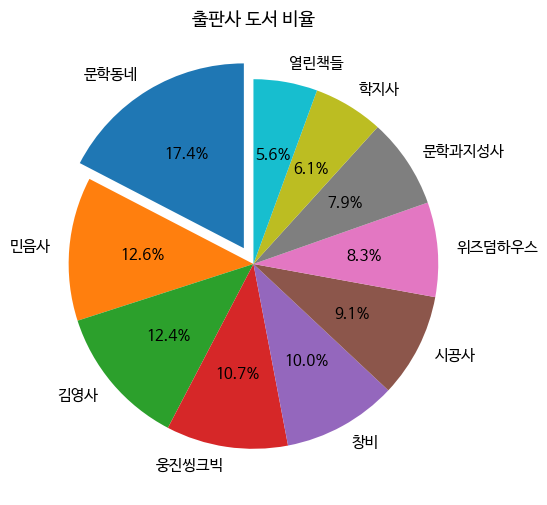

In [177]:
#예를 들어 첫 번째 출판사인 '문학동네'만 떨어내려면 첫 번째 항목이 0.1이고 나머지는 모두 0인 파이썬 리스트를 만들어 전달합니다. 
#explode 매개변수에 전달하는 리스트 길이는 data 배열의 길이와 같아야 합니다.
fig, ax=plt.subplots(figsize=(8,6))
ax.pie(data, labels=labels, startangle=90, autopct='%.1f%%', explode=[0.1]+[0]*9)
ax.set_title('출판사 도서 비율')
fig.show()

### 여러 종류의 그래프가 있는 서브플롯 그리기
산점도, 스택 영역 그래프, 스택 막대 그래프, 원 그래프를 하나의 피겨에 그릴 수 있다.
subplots() 함수의 첫 번째 매개변수와 두 번쨰 매개변수에는 서브플롯의 행 개수와 열 개수를 지정할 수 있다고 했습니다. subplots() 함수에서 반환 받은 Axes 객체를 사용할 때는 2차원 배열처럼 각 격자의 위치를 지정해야 합니다. (axes[열, 행], 0부터)

C:\Users\User\AppData\Local\Temp\ipykernel_3556\1927522125.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


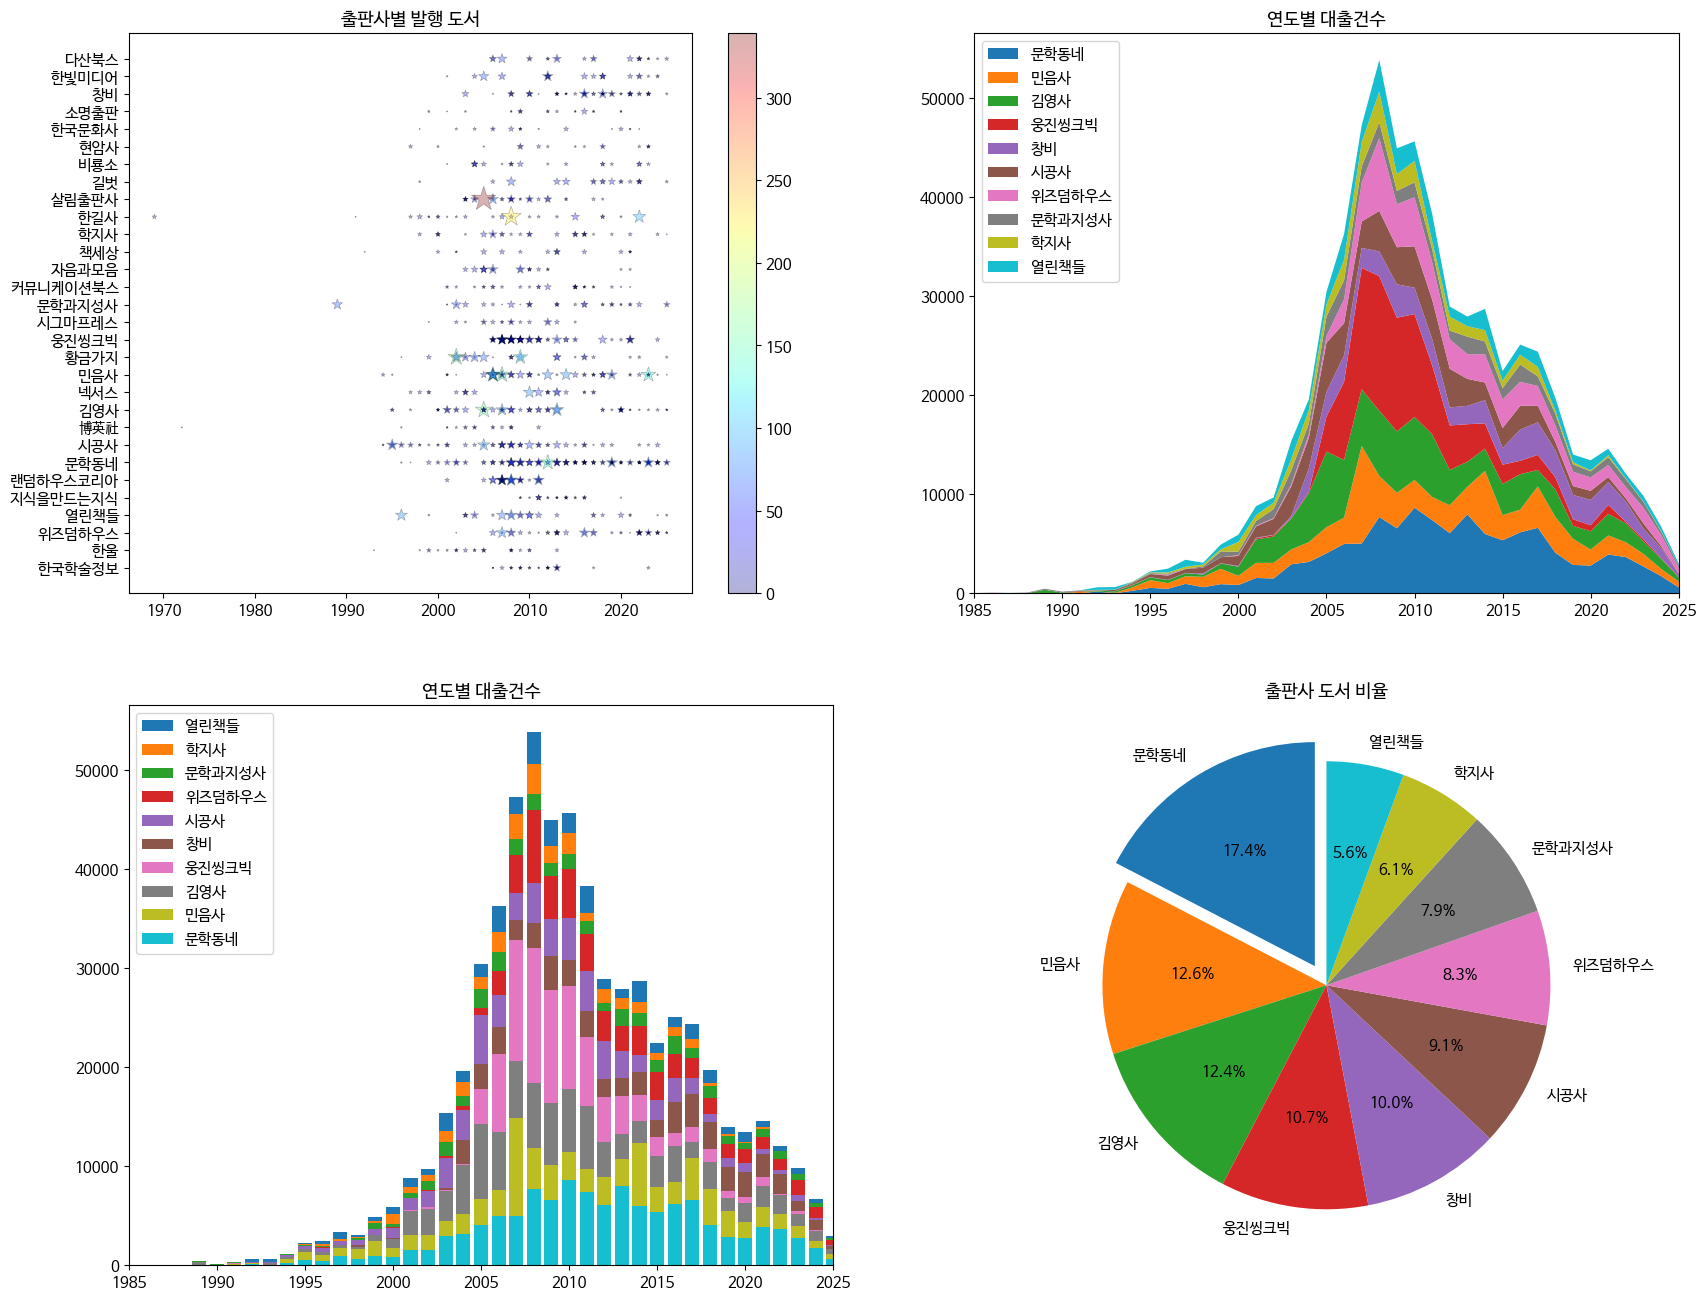

In [180]:
#앞에서 그린 4개의 그래프를 하나씩 모두 그려 보겠습니다. 
#추가로 서브플롯 안에 있는 산점도에 컬러 막대도 넣으려면 colorbar() 메서드의 ax 매개변수에 해당 서브 플롯 객체를 지정해 주어야 합니다. 
fig, axes=plt.subplots(2,2, figsize=(20,16))

#산점도
ns_book8=ns_book7[top30_pubs_idx].sample(1000, random_state=42)
sc=axes[0,0].scatter(ns_book8['발행년도'], ns_book8['출판사'], linewidths=0.5, edgecolors='k', alpha=0.3, s=ns_book8['대출건수'], c=ns_book8['대출건수'], cmap='jet')
axes[0,0].set_title('출판사별 발행 도서')
fig.colorbar(sc, ax=axes[0,0])

#스택 영역 그래프
axes[0,1].stackplot(year_cols, ns_book10.loc[top10_pubs].fillna(0), labels=top10_pubs)
axes[0,1].set_title('연도별 대출건수')
axes[0,1].legend(loc='upper left')
axes[0,1].set_xlim(1985, 2025)

#스택 막대 그래프
for i in reversed(range(len(ns_book12))):
    bar=ns_book12.iloc[i]    #행 추출
    label=ns_book12.index[i]    #출판사 이름 추출
    axes[1,0].bar(year_cols, bar, label=label)
axes[1,0].set_title('연도별 대출건수')
axes[1,0].legend(loc='upper left')
axes[1,0].set_xlim(1985, 2025)

#원 그래프
axes[1,1].pie(data, labels=labels, startangle=90, autopct='%.1f%%', explode=[0.1]+[0]*9)
axes[1,1].set_title('출판사 도서 비율')

fig.savefig('all_in_one.png')
fig.show()

# ch7. 검증하고 예측하기

## 7-1 통계적으로 추론하기
(모수검정, 표준점수, 중심극한정리, 신뢰구간, 가설검정, 순열검정)

In [184]:
#혼공출판사에서 이번에 알고리즘을 배우는 도서를 출간할 예정입니다. 마케팅팀에서는 파이썬으로 알고리즘을 배우는 도서이니 제목에 '파이썬'이 들어가는 것이
#판매에 도움이 된다고 하네요. 이에 반해 편집팀에서는 다른 프로그래밍 언어를 다루는 사람도 충분히 볼 수 있기 때문에 '알고리즘'에 초점을 맞추고 싶어 합니다.
#도서 이름에 '파이썬'을 넣는 게 판매에 도움이 될지 정확히 알기 위해서 이 절에서는 가설검정과 순열검정을 배워 보겠습니다. 
#(실제 판매 데이터가 있어야 하지만, 이 책에서는 대출 데이터가 판매 실적과 연관성이 있다고 가정하고 진행하겠습니다.)

### 모수검정이란
통계학에서는 모집단에 대한 파라미터를 추정하는 방법을 모수검정이라고 합니다. 여기서 파라미터는 평균, 분산 등이며 모집단은 관심 대상이 되는 전체 데이터를 의미합니다. 모집단에서 선택한 일부 샘플인 표본을 조사한 다음 전체 모집단의 파라미터를 주정하는 것이 바로 모수검정입니다.

모수검정은 모집단의 데이터에 대해 어떤 가정을 전제로 하고 수행되는 경우가 많습니다. 예를 들어 전체 청소년의 몸무게가 정규분포를 따른다고 가정하는 거죠. 실제로 전체 데이터를 알지 못하지만, 자연 세계의 데이터는 정규분포를 따르는 경우가 많기 때문입니다.

### 표준점수 구하기
데이터가 정규분포를 따른다고 가정하고, 각 값이 평균에서 얼마나 떨어져 있는지 표준편차를 사용해 변환한 점수를 표준점수(standard score) 또는 z score라고 합니다. 가절검정에서는 표준점수가 중요한 역할을 하므로 자세히 알아보겠씁니다.

출생한 아기의 몸무게와 키에 대한 데이터가 있다고 가정해 보겠습니다. 몸무게와 키가 평균으로부터 얼마만큼 떨어져 있는지 나타내려면 몸무게는 1kg, 키는 5cm와 같이 다른 단위를 써야 합니다. 게다가 어떤 수치만 보아서는 평균으로부터 몸무게가 더 멀리 떨어져 있는지, 키가 더 멀리 떨어져 있는지 알기 어렵습니다. 
그래서 z 점수라는 값을 사용합니다. z점수는 평균까지 거리를 표준편차로 나눈 값입니다.  [(한 표본 데이터값-모집단의 평균)/ 모집단의 표준편차]

만약 아기의 몸무게와 키에 대한 z점수가 각각 1과 0.5라면, 아기의 몸무게가 평균에서 1 표준편차만큼 떨어져 있고 키는 0.5 표준편차만큼 떨어져 있다는 의미입니다. 따라서 몸무게가 키에 비해 상대적으로 평균에서 더 멀리 떨어져 있다는 것을 쉽게 알 수 있습니다.
(정리- 표준편차는 분산의 제곱근으로 데이터의 분포 정도를 나타냅니다. 이를 점수화한 표준점수로 데이터 분포를 가늠할 수 있습니다.)

In [185]:
#z 점수 구하기
#다음처럼 다섯 개의 값으로 이루어진 배열 x가 있을 때 숫자 7에 대한 z 점수를 계산하려면, 
#넘파이로 먼저 표준편차와 평균을 계산한 후 z 점수 공식에 적용할 수 있습니다.
import numpy as np
x=[0,3,5,7,10]
s=np.std(x)        #표준편차를 구하는 공식
m=np.mean(x)       #평균을 구하는 공식
z= (7-m) / s       #z score 공식
print(z)

0.5872202195147035


In [186]:
#z 점수는 많은 수학 및 과학 알고리즘을 제공하는 사이파이(scipy)로 더 편리하게 계산할 수 있습니다. 
#사이파이의 stats 모듈을 임포트한 다음 zscore() 함수를 호출하여 배열 x에 대한 모든 z 점수를 계산할 수 있습니다. 
from scipy import stats
stats.zscore(x)       #결과는 배열 z에 대한 모든 z 점수가 표기됨

array([-1.46805055, -0.58722022,  0.        ,  0.58722022,  1.46805055])

### 누적분포 이해하기
평균이 0이고 표준편차가 1인 정규분포를 표준정규분포라고 합니다. 평균이 0이고 표준편차 1을 z 점수 공식에 대입하면 z=x가 됩니다.
따라서 표준정규분포는 z 점수를 사용해 전체 데이터가 어떻게 분포되어 있는지 나태낼 수 있습니다.

In [187]:
#누적분포 구하기- 어떤 z 점수 이내의 샘플 비율을 편리하게 계산할 수 있는 함수가 사이파이에 있습니다.
#stats 모듈의 norm.cdf() 메서드는 누적된 분포를 반환해 줍니다. 
stats.norm.cdf(0)

np.float64(0.5)

In [189]:
#만약 z 점수 1 이내의 비율을 구하려면 z 점수 1까지 누적분포에서 z점수 -1까지 누적분포를 빼면 됩니다.
stats.norm.cdf(1.0)-stats.norm.cdf(-1.0)

np.float64(0.6826894921370859)

In [190]:
#표준편차 2 이내의 비율
stats.norm.cdf(2.0)-stats.norm.cdf(-2.0)

np.float64(0.9544997361036416)

In [192]:
#표준편차 1.5 이내의 비율
stats.norm.cdf(1.5)-stats.norm.cdf(-1.5)

np.float64(0.8663855974622838)

In [193]:
#반대로 전체에서 특정 비율에 해당하는 z 점수를 구하려면 norm.ppf() 메섣를 사용합니다.
stats.norm.ppf(0.9)       #90% 누적분포에 해당하는 z 점수 구하기

np.float64(1.2815515655446004)

In [194]:
#지금까지 z 점수에 대해 알아보고 누적분포를 구하는 방법을 알아보았습니다. 이는 모두 정규분포를 토대로 함을 잊지 마세요!
#하지만 정규분포로 보기 어려운 데이터에서 정규분포 특성을 유도할 수 있는 놀라운 방법이 있습니다.
#정리-z 점수로 누적분포를 구하려면 사이파이의 norm.cdf() 메서드, 누적분포로 z 점수를 구하려면 사이파이의 norm.ppf() 메서드를 사용합니다.

### 중심극한정리
중심극한정리는 '무작위로 샘플을 뽑아 만든 표본의 평균은 정규분포에 가깝다'는 이론입니다. 

In [196]:
import pandas as pd
ns_book7=pd.read_csv('ns_book7.csv', low_memory=False)
ns_book7.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,페스트,알베르 카뮈 지음 ;김화영 옮김,민음사,2020,9788937462672,NaN,NaN,267,808,1,181,2025-12-31
1,2,앤서니 브라운의 행복한 미술관,"앤서니 브라운 글 그림, 서애경 옮김",웅진씽크빅,2004,9788901044873,NaN,NaN,NaN,843,1,0,2025-12-31
2,4,지구를 여행하는 히치하이커를 위한 안내서,"아이작 유엔 지음, 성소희 옮김",학산문화사,2025,9791141162504,NaN,NaN,NaN,NaN,1,0,2025-12-31
3,5,독서에도 교육이 필요하다면,최소희.이승화 지음,인품,2020,9791196594213,NaN,NaN,NaN,NaN,1,0,2025-12-31
4,6,쌀 재난 국가,이철승 지음,문학과지성사,2021,9788932038001,NaN,NaN,NaN,NaN,1,0,2025-12-31


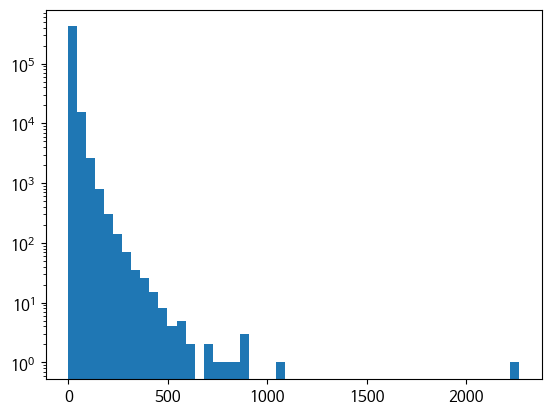

In [198]:
#ns_book7 데이터프레임의 '대출건수' 열로 히스토그램을 그립니다.
import matplotlib.pyplot as plt
plt.hist(ns_book7['대출건수'], bins=50)
plt.yscale('log')
plt.show()
#출력된 그래프에서 볼 수 있듯이 '대출건수' 열의 분포는 정규분포와는 상당히 거리가 멀어 보입니다. 
#하지만 무작위로 샘플링한 표본의 평규능ㄹ 히스토그램으로 그려 보면 달라집니다.

In [200]:
#샘플링하기(표본을 추출하는 것을 샘플링이라고 합니다): 판다스 데이터프레임의 sample() 메서드
#먼저 무작위로 1000개의 표본을 샘플링하여 각 평균을 리스트로 저장해 보겠습니다.
#이 메서드의 첫 번째 매개변수에는 샘플링할 개수를 지정합니다. 그다음 mean() 메서드를 연이어 호출하여 샘플링 결과의 평균을 계산합니다.
#마지막으로 이 평균을 sample_means 리스트에 추가합니다. 이런 과정을 for 문으로 1000번 반복합니다.
np.random.seed(420)      #독자 실습과 책의 결과를 일치시키기 위해 유사난수 생성을 위한 초깃값을 지정합니다.
sample_means=[]
for _ in range(1000):
    m=ns_book7['대출건수'].sample(30).mean()
    sample_means.append(m)

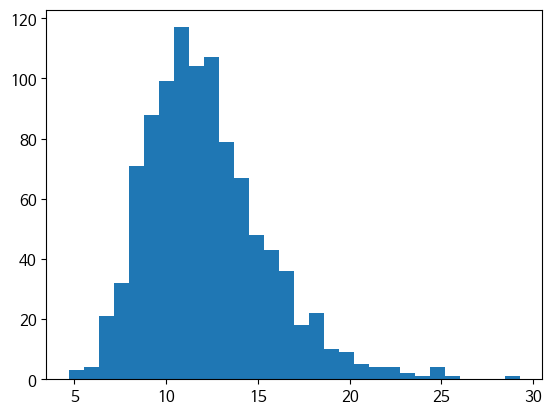

In [201]:
#이제 sample_means의 히스토그램을 그려보죠.
plt.hist(sample_means, bins=30)
plt.show()

In [202]:
#샘플링 크기와 정확도- 그렇다면 이렇게 무작위로 뽑은 표본의 통계량이 실제 모집단의 통계량과 얼마나 일치할까요?
#재미있는 사실은 이 정규분표 형태의 평균이 모집단의 평균과 매우 가깝다는 것입니다. 한번 sample_means 배열의 평균을 확인해 보죠.
np.mean(sample_means)       #무작위로 뽑은 표본의 통계량

np.float64(12.212)

In [203]:
#이번에는 ns_book7 데이터프레임에 있는 전체 대출건수의 평균을 확인해 보죠.
ns_book7['대출건수'].mean()       #실제 모집단의 통계량

np.float64(12.572644621855089)

In [204]:
#앞서 샘플링 크기를 30으로 지정했는데요, 일반적으로 중심극한정리를 따르려면 샘플링의 크기가 30보다 클수록 좋습니다.
#이번에는 샘플링 크기를 20으로 낮추어 평균을 계산해 보죠.
np.random.seed(42)
sample_means=[]
for _ in range(1000):
    m=ns_book7['대출건수'].sample(20).mean()
    sample_means.append(m)
np.mean(sample_means)

np.float64(12.4605)

In [205]:
#다시 샘플링의 크기를 40으로 높여서 다시 평균을 구해 보겠습니다.
np.random.seed(42)
sample_means=[]
for _ in range(1000):
    m=ns_book7['대출건수'].sample(40).mean()
    sample_means.append(m)
np.mean(sample_means)
#이게 제일 대출건수 실제 평균과 가깝습니다. 

np.float64(12.59425)

In [206]:
#또 다른 흥미로운 특징은 표본 평균의 표준편차(s)가 모집단의 표준편차(시그마)를 표본 크기(n)의 제곱근으로 나눈 것에 가깝다는 것입니다.
#실제로 이 공식이 잘 들어 맞는지 확인해 보죠. 먼저 넘파이 std() 함수로 sample_means의 표준편차를 구합니다.
np.std(sample_means)       #표본으로 표준편차를 구할 때

np.float64(3.163140162480948)

In [207]:
#이번에는 전체 대출건수의 표준편차를 샘플링 개수 40의 제곱근으로 나누어 보곘습니다.
np.std(ns_book7['대출건수'])/np.sqrt(40)     #모집단으로 표준편차를 구했을 때

np.float64(3.1592213192378185)

In [208]:
#아주 비슷하군요. 이렇게 구한 표본 평균의 표준편차는 표준오차(standard error)라고 합니다. 
#그럼 이런 중심극한정리를 이용하여 파이썬 도서에 대한 대출건수의 평균이 얼마인지 추정할 수 있을까요?

### 모집단의 평균 범위 추정하기: 신뢰구간(confidence level)
우리는 남산도서관의 대출건수를 모집단으로 가정하여 1000개의 표본을 뽑아 계산한 표본의 평균이 모집단이 평군에 가까워진다는 것을 보았습니다.
하지만 실전에서는 표본을 수집하는 데 시간과 비용이 많이 들기 때문에 이렇게 많은 횟수의 표본을 만들기 어려운 경우가 많습니다. 게다가 모집단에 대한 정보를 구할 수 없는 경우도 많습니다. 

딱 하나의 표본이 있다면 모집단의 평균을 추정할 수 있을까요? 신뢰구간은 표본의 파라미터(여기에서는 평균)가 속할 것이라 믿는 모집단이 파라미터 범위입니다.

In [209]:
#남산도서관의 파이썬 도서의 대출건수를 이용해 신뢰구간을 어떻게 계산하는지 알아보겠습니다. 
#먼저 전체 데이터프레임에서 파이썬 도서만 골라냅니다.
python_books_index=ns_book7['주제분류번호'].str.startswith('00') & ns_book7['도서명'].str.contains('파이썬')
python_books=ns_book7[python_books_index]
python_books.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
1354,1404,모두의 인공지능 with 파이썬,이영호 지음,길벗,2025,9791140714995,NaN,NaN,NaN,004.73,1,2,2025-11-11
2047,2147,파이썬다운 코드를 개발하는 63가지 실용 기법,용 추이 지음;이주호 옮김,인사이트,2025,9788966264766,NaN,9,NaN,005.133,1,6,2025-09-26
2997,3128,파이썬 알고리즘 =Algorithms in Python,최영규 지음,생능출판(생능출판사),2021,9788970504797,NaN,9,NaN,005.133,1,4,2025-09-11
4503,4823,"인공지능, 주식분석 좀 부탁해 :입문자를 위한 파이썬 주식분석 프로그램 만들기",곽경일 지음,비제이퍼블릭,2025,9791165923075,NaN,9,NaN,005.133,1,8,2025-07-11
4525,4846,"전문가를 위한 파이썬 :간단하고, 명료하고, 효율적인 파이썬 프로그래밍",지은이: 루시아누 하말류 ;옮긴이: 강권학,한빛미디어,2024,9791169211772,NaN,9,NaN,005.133,1,8,2025-07-11


In [210]:
len(python_books)     #데이터프레임의 행 개수를 셀 때는 len() 함수를 사용합니다.

439

In [212]:
#총 439권의 도서가 있군요. 파이썬 도서의 대출건수 평균을 계산해 보겠습니다.
python_mean=np.mean(python_books['대출건수'])
python_mean

np.float64(18.710706150341686)

파이썬 도서의 평균 대출건수파이썬 도서의 평균 대출건수는 18회가 넘습니다. 이제 z 점수 공식과 중심극한정리를 연결하여 모집단의 평균 범위를 예측해 봅시다.
(모집단의 평균을 알 수 없고, 표본의 평균만 알 때 z 공식): (x-뮤)/표준오차
-남산도서관의 파이썬 대출건수가 표본이라면 우리나라의 모든 도서관의 파이썬 도서 대출건수를 모집단으로 생각할 수 있습니다. 하지만 모든 도서관 데이터는 구하기 힘들죠. 이럴 때 중심극한정리를 적용해 볼 수 있습니다. 모집단의 표준편차가 표본의 표준편차와 비슷하다고 가정하는 것이지요.

In [213]:
#모집단의 표준편차 대신 표본이라 할 수 있는 남산도서관의 파이썬 도서 대출건수로 표준편차를 구한 다음, 표준오차를 계산해 보겠습니다.
python_std=np.std(python_books['대출건수'])
python_se=python_std/np.sqrt(len(python_books))     #표본의 표준편차/ 표본에 포함된 샘플 개수
python_se

np.float64(0.5747467241709959)

In [214]:
#마지막으로 표준오차에 곱할 적절한 z 점수를 결정해야 합니다. 여기에선 이 표본의 평균이 모집단의 평균을 중심으로 95% 이내 구간에 포함된다고 확신하고 싶습니다.

#평균을 중심으로 95% 영역을 차지하면 좌우에는 각각 2.5%가 남습니다. 따라서 95% 비율에 해당하는 z 점수를 알려변 norm.ppf() 메서드에 각각 0.975와 0.025를 입력하면 됩니다.
stats.norm.ppf(0.975)

np.float64(1.959963984540054)

In [215]:
stats.norm.ppf(0.025)
#정규분포는 대칭이기 때문에 두 z 점수가 부호만 다르고 같은 것을 알 수 있습니다.

np.float64(-1.9599639845400545)

In [216]:
#이제 앞에서 구한 표준오차 python_se와 z 점수를 곱하여 파이썬 도서의 대출건수 평균인 python_mean 데이터프레임이 속할 범위를 구해 보겠습니다.
print(python_mean-1.96*python_se, python_mean+1.96*python_se)
#결과를 어떻게 해석할 수 있을까요? 표본의 평균 python_mean과 표준오차 python_se를 바탕으로 '모집단의 평균이 17.6에서 19.8사이에 놓여 있다'고 말합니다.
#정리- 신뢰구간은 이 구간 안에 모집단의 평균이 포함되어 있을 것이라 확신하는 범위를 의미합니다.

17.584202570966532 19.83720972971684


### 통계적 의미 확인하기: 가설검정⭐⭐⭐
지금까지 중심극한정리를 사용해 표본의 평균으로 모집단의 평균을 추정하는 방법을 알아보았습니다. 이 이론을 더 확장하여 파이썬 도서와 C++ 도서의 평균에 의미 있는 차이가 있는지 알아보죠. 

가설검정은 표본에 대한 정보를 사용해 모집단의 파라미터에 대한 가정을 검정하는 것입니다. 예를 들어 파이썬과 C++ 도서의 평균 대출건수가 같다고 가정했을 때, 파이썬과 C++ 도서의 표본을 각각 추출하여 이 가정이 맞는지 검정할 수 있습니다. 
이때 파이썬과 C++ 도서의 평균 대출건수가 같다는 가설을 귀무가설, 같지 않다는 가설을 대립가설이라 부릅니다.

귀무가설: 표본 사이에 통계적으로 의미가 없다고 예상되는 가설/ 대립가설: 표본 사이에 통계적인 차이가 있다는 가설
두 모집단의 평균에 대한 Z점수 공식으로 계산했을 때 Z 점수가 일정 수준(이를 유의수준이라고 말합니다) 이하이면 평균에 차이가 없는 데이터가 관측될 가능성이 매우 낮다는 의미이고, 따라서 귀무가설을 기각하고 두 모집다느이 평균에 차이가 있다는 대립가설을 채택할 수 있습니다. 

정규분포의 양쪽 꼬리 면적을 더해 5%, 즉 양측의 꼬리가 2.5%가 되는 지점을 p-값이라고 부릅니다. p-값이 0.05 미만일 떄 귀무가설을 기각합니다.

In [217]:
#Z점수로 가설 검증하기- 그럼 c++도서 표본을 추출하여 가설검정 과정을 차례로 밟아 보겠습니다.
#먼저 파이썬 도서를 고를 때와 마찬가지로 C++ 도서에 대한 불리언 배열의 인덱스를 만들어 cplus_books 데이터프레임을 만듭니다.
cplus_books_index=ns_book7['주제분류번호'].str.startswith('00') & ns_book7['도서명'].str.contains('C++', regex=False)
cplus_books=ns_book7[cplus_books_index]
cplus_books.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
11143,11788,C++ 스크립트를 활용한 언리얼 엔진 5 게임 개발,"젠유 조지 리 지음, 진석준 옮김",에이콘출판,2024,9791161759289,NaN,NaN,NaN,005.1,1,6,2025-02-03
12475,13238,A Tour of C++,"비야네 스트롭스트룹 지음, 심지현 옮김",에이콘(에이콘출판주식회사),2024,9791161758565,NaN,NaN,NaN,005.133,1,7,2024-11-07
12532,13298,아름다운 C++,"가이 데이비드슨,케이트 그레고리 공저, 박지윤 옮김",Jpub(제이펍),2024,9791193926185,NaN,NaN,NaN,005.133,1,9,2024-11-07
16433,17297,C++ 기본에서 상급까지 :전문가로 인도하는 C++ 지침서,이재국 지음,좋은땅,2024,9791138827126,NaN,1,NaN,005.115,1,9,2024-07-04
16457,17322,C++ 기본에서 상급까지,이재국 지음,좋은땅,2024,9791138827126,NaN,NaN,NaN,005.115,1,15,2024-07-04


In [218]:
len(cplus_books)    #c++ 도서권수 확인

106

In [219]:
cplus_mean=np.mean(cplus_books['대출건수'])       #c++ 도서의 평균 대출건수 확인
cplus_mean

np.float64(14.537735849056604)

In [220]:
#파이썬과 c++의 평균 대출건수의 차이에 의미가 있는 것인지, 아니면 우연인지, z 점수에 대한 가설검정 공식으로 확인해 보겠습니다.

In [222]:
#c++ 도서에 대한 표준오차 계산
cplus_se=np.std(cplus_books['대출건수'])/np.sqrt(len(cplus_books))
cplus_se

np.float64(0.9348837200462182)

In [223]:
#가설검정 공식에 이를 대입합니다. 귀무가설에 의하면 두 모집단의 평균은 같습니다. 따라서 다음과 같이 쓸 수 있습니다.
(python_mean-cplus_mean) / np.sqrt(python_se**2 + cplus_se**2)

np.float64(3.8025111129136797)

In [224]:
#이제 계산된 z 점수를 사용해 누적분포를 확인해 보겠습니다.
stats.norm.cdf(2.50)

np.float64(0.9937903346742238)

In [225]:
#2.50에 해당하는 누적분포는 0.994입니다. 따라서 정규분포의 양쪽 끝의 면접은 각각 1-0.994=0.006이 됩니다.
#+-2.50에 해당하는 양쪽 끝의 면적, 즉 p-값은 (1-0.994)*2=0.01로 유의수준에 해당하는 0.05(5%)보다 작습니다. 
#따라서 '파이썬과 C++ 도서의 평균에 차이가 있다'는 대립가설이 지지됩니다. 

### t-검정으로 가설 검증하기: ttest_ind() 함수
사이파이에는 두 표본의 평균을 비교하는 ttes_ind() 함수가 있습니다. ttest_ind() 함수는 t-분포인 두 표본을 비교하는 t-검정을 수행합니다. t-분포는 정규분포와 비슷하지만, 중앙은 조금 더 낮고 꼬리가 더 두꺼운 분포입니다. 표본의 크기가 30 이하일떄 t-분포를 사용하는 것이 좋으며 클 경우 t-분포는 정규분포와 매우 비슷해집니다. 따라서 이 함수를 사용해 표본 크기에 상관없이 평균을 비교할 수 있습니다.

정리- t 점수는 정규분포의 z 점수에 해당하는 통계치입니다. 

In [226]:
#앞에서 구한 파이썬 도서와 c++ 도서의 데이터를 ttest_ind() 함수에 전달하면 t점수와 p-값을 반환합니다.
t, pvalue=stats.ttest_ind(python_books['대출건수'], cplus_books['대출건수'])
print(t, pvalue)
#결과의 후자가 p-값인데요, 유의수준인 0.05보다 작으므로 귀무가설을 기각하며 두 도서의 대출건수 평균의 차이는 우연이 아니라고 말할 수 있습니다.

3.314666715406024 0.000978748657260828


In [227]:
#ttes_ind() 함수를 사용하면 손쉽게 표본의 평균을 비교할 수 있네요. 
#하지만 이런 테스트들은 모두 여러 가지 가정을 바탕으로 하는데, 대표적으로 '모집단이 정규분포의 형태를 따른다'고 가정합니다.
#하지만 그렇지 않다면 어떻게 해야 할까요?

### 정규분포가 아닐 때 가설 검증하기: 순열검정
순열검정은 모집단의 분포가 정규븐포를 따르지 않거나 모집단의 분포를 알 수 없을 때 사용할 수 있는 방법입니다. 모집다느이 파라미터를 추정하지 않기 떄문에 비모수검정 방법 중에 하나입니다. 

순열검정 방법은 다음과 같습니다. 먼저 두 표본의 평균의 차이를 계산한 후 두 표본을 섞고 무작위로 두 그룹으로 나눕니다. 이때 두 그룹은 원래 표본의 크기와 동일하게 만듭니다. 이렇게 나눈 두 그룹에서 다시 평균의 차이를 계산합니다. 이런 과정을 여러 번 반복해서 원래 표본의 평균 차이가 무작위로 나눈 그룹의 평균 차이보다 크거나 작은 경우를 헤아려 p-값을 계산합니다.

In [228]:
#도서 대출건수 평균 비교하기(1): 파이썬 vs C++
def statistic(x,y):
    return np.mean(x)-np.mean(y)       #먼저 두 개의 배열을 받아 평균을 구하는 함수를 만듭니다.

In [231]:
#다음 순열검정을 실행하는 함수를 구현하겠습니다. 두 배열을 넘파이 append() 함수로 합친 후 무작위로 추출하기 위해 permulatation() 함수를 사용합니다.
#(이 함수는 무작위로 섞인 배열을 만드는데, 여기에서는 전체 배열 길이만큼 랜덤한 인덱스를 만들어 줍니다.)
def permutation_test(x,y):
    #표본의 평균 차이를 계산합니다.
    obs_diff=statistic(x,y)
    #두 표본을 합칩니다.
    all=np.append(x,y)
    diffs=[]
    np.random.seed(42)
    #순열검정을 1000번 반복합니다.
    for _ in range(1000):
        #전체 인덱스를 섞습니다.
        idx=np.random.permutation(len(all))
        #랜덤하게 두 그룹으로 나눈 다음 평균 차이를 계산합니다.
        x_=all[idx[:len(x)]]
        y_=all[idx[len(x):]]
        diffs.append(statistic(x_, y_))
    #원본 표본보다 작거나 큰 경우의 p-값을 계산합니다.
    less_pvalue=np.sum(diffs < obs_diff)/1000
    greater_pvalue=np.sum(diffs > obs_diff)/1000
    #둘 중 작은 p-값을 선택해 2를 곱하여 최종 p-값을 반환합니다.
    return obs_diff, np.minimum(less_pvalue, greater_pvalue)*2

In [232]:
#표본의 평균 차이보다 큰 경우와 작은 경우의 비율을 계산하여 p-값을 계산합니다. 일반적으로 귀무가설을 기각하는 것이 목적이므로 둘 중에 작은 값을 선택하고
#2를 곱해 양쪽 꼬리에 해당하는 비율을 얻습니다. 이 값이 바로 '귀무가설이 옳다고 가정했을 때 이런 데이터가 관측될 확률'입니다.

#파이썬 도서와 c++ 도서의 대출건수를 전달하여 순열검정의 결과를 확인해 보죠.
permutation_test(python_books['대출건수'], cplus_books['대출건수'])

#앞서 가설검정으로 구한 p-값과 비슷한 결과를 얻었습니다. 여기에서도 유의수준인 5%에 해당하지 못하기 때문에 귀무가설을 기각하고,
#두 도서의 평균 대출건수에는 차이가 있다고 결론을 내릴 수 있습니다.

(np.float64(4.172970301285082), np.float64(0.002))

In [234]:
#여기서 잠깐- 사실 사이파이 1.8버전 이상일 경우 순열검정을 위한 permutations_test() 함수를 제공합니다. 이렇게 함수를 작성할 필요가 없죠
!pip install -U scipy     
#사이파이를 최신 버전으로 업데이트
res=stats.permutation_test((python_books['대출건수'], cplus_books['대출건수']), statistic, random_state=42)
print(res.statistic, res.pvalue)

#이 함수의 첫 번째 매개변수에 두 표본을 튜플로 전달하고, 두 번째 매개변수에 비교할 통계치를 계산하는 함수(이 경우 평균의 차이를 게산하는 statistic() 함수)
#를 전달합니다. 이 함수는 기본적으로 9999번 순열검정을 수행합니다.

   ---------------------------------------- 0.0/36.3 MB ? eta -:--:--
   --------- ------------------------------ 8.7/36.3 MB 41.8 MB/s eta 0:00:01
   ------------------- -------------------- 17.3/36.3 MB 41.6 MB/s eta 0:00:01
   ----------------------------- ---------- 27.0/36.3 MB 42.7 MB/s eta 0:00:01
   ---------------------------------------  35.9/36.3 MB 42.6 MB/s eta 0:00:01
   ---------------------------------------- 36.3/36.3 MB 37.0 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
4.172970301285082 0.0006


In [235]:
#도서 대출건수 평균 비교하기(2): 파이썬 vs 자바스크립트
java_books_indx=ns_book7['주제분류번호'].str.startswith('00') & ns_book7['도서명'].str.contains('자바스크립트')
java_books=ns_book7[java_books_indx]
java_books.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
9708,10286,예제로 배우는 소프트웨어 디자인 :자바스크립트를 활용한 도구 기반 설명,그렉 윌슨 지음 ;김성원 옮김,Youngjin.com(영진닷컴),2024,9788931477696,NaN,9,NaN,005.133,1,14,2025-02-24
11140,11785,Do it! 자바스크립트 + 제이쿼리 입문,정인용 지음,이지스퍼블리싱,2024,9791163036623,NaN,NaN,NaN,005.138,1,5,2025-02-03
13264,14061,헬로 Bun - 차세대 자바스크립트 런타임+올인원 개발 키트를 만나다,서대영(달레) 지음,제이펍,2024,9791193926710,NaN,NaN,NaN,005.138,1,4,2024-10-24
13531,14339,(쉽게 설명한) 자바스크립트 알고리즘 =Javascript algorithm :쉬운...,한상훈 저,영진.com(영진닷컴),2024,9788931477252,NaN,9,NaN,005.138,1,9,2024-09-26
14970,15800,자바스크립트 + 리액트 디자인 패턴,"애디 오스마니 지음, 윤창식 옮김",한빛미디어,2024,9791169212571,NaN,NaN,NaN,005.138,1,16,2024-08-12


In [236]:
#자바스크립트의 도서권수와 평균 대출건수를 확인해 보죠.
print(len(java_books), np.mean(java_books['대출건수']))

124 17.70967741935484


In [237]:
#파이썬과 의미가 있는 차이인지 순열검정으로 확인해 보겠습니다.
permutation_test(python_books['대출건수'], java_books['대출건수'])

(np.float64(1.001028730986846), np.float64(0.382))

## 7-2 머신러닝으로 예측하기
(모델, 지도학습, 비지도학습, 훈련 세트, 테스트 세트. 결정계수, 선형 회귀, 로지스틱 회귀)
머신러닝은 데이터에서 유용한 패턴을 감지하거나 미래의 성과를 예측할 수 있어 데이터 분석가에게 꼭 필요한 도구 중 하나입니다.

### 알아 두면 좋은 머신러닝 용어
머신러닝은 컴퓨터 프로그램을 사용해 데이터에서 패턴을 학습하는 방법입니다. 학습된 패턴을 사용하여 새로운 데이터에 대해 빠르고 유용한 결정을 내릴 수 있죠.
머신러닝은 인공지능의 하위 분야입니다. 그리고 지도 학습과 비지도 학습으로 나눕니다.
1. 모델- 여기서 모델은 추상적으로 선형 회귀라는 특정 알고리즘을 대변합니다. 구체적으로는 머신러닝으로 학습된 패턴을 저장하는 소프트웨어 객체를 의미하죠.
2. 지도 학습과 비지도 학습- 사용하는 데이터에 정답(타깃)이 포함되어 있는지 아닌지

머신러닝 모델에 입력(input)과 타깃을 전달하여 데이터에 있는 패턴을 학습시키는 과정을 훈련이라고 합니다. 

In [239]:
#파이썬의 대표적인 머신러닝 패키지는 사이킷런입니다.
!pip install scikit-learn

### 모델 훈련하기
입력과 타깃으로 머신러닝 모델을 훈련한 다음에는 얼마나 좋은 모델인지 평가할 방법이 필요합니다.
모델을 훈련하는데 사용하는 입력a와 타깃a를 훈련세트라 부르고 입력b, 타깃b를 테스트 세트라고 부릅니다. 보통 테스트 데이터는 전체의 20~25%를 사용합니다.

In [241]:
#훈련 세트와 테스트 세트로 나누기: train_test_split() 함수- 데이터를 무작위로 섞은 후 샘플을 훈련 세트와 테스트 세트로 나눕니다.
import pandas as pd
ns_book7=pd.read_csv('ns_book7.csv', low_memory=False)
ns_book7.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
0,1,페스트,알베르 카뮈 지음 ;김화영 옮김,민음사,2020,9788937462672,NaN,NaN,267,808,1,181,2025-12-31
1,2,앤서니 브라운의 행복한 미술관,"앤서니 브라운 글 그림, 서애경 옮김",웅진씽크빅,2004,9788901044873,NaN,NaN,NaN,843,1,0,2025-12-31
2,4,지구를 여행하는 히치하이커를 위한 안내서,"아이작 유엔 지음, 성소희 옮김",학산문화사,2025,9791141162504,NaN,NaN,NaN,NaN,1,0,2025-12-31
3,5,독서에도 교육이 필요하다면,최소희.이승화 지음,인품,2020,9791196594213,NaN,NaN,NaN,NaN,1,0,2025-12-31
4,6,쌀 재난 국가,이철승 지음,문학과지성사,2021,9788932038001,NaN,NaN,NaN,NaN,1,0,2025-12-31


In [242]:
#train_test_split() 함수는 기본적으로 입력된 데이터를 무작위로 섞은 후 75%를 훈련세트로, 25%를 테스트 세트로 나눕니다.
#이 함수는 분할된 훈련 세트와 테스트 세트를 리스트로 반환하기 떄문에 리스트 개수에 맞는 변수를 왼쪽에 나열하여 반환되는 값을 각각 지정할 수 있습니다.
from sklearn.model_selection import train_test_split
train_set, test_set=train_test_split(ns_book7, random_state=42)
#분할 비율을 조정하려면 train_test_split() 함수에 test_size 매개변수를 0~1 사이의 값으로 지정합니다.

In [243]:
print(len(train_set), len(test_set))

327582 109195


In [244]:
#이제 사이킷런에 있는 선형 회귀 모델을 이 데이터로 훈련해 보겠습니다.
#train_set에 있는 '도서권수' 열을 사용해 대출건수를 예측해 보죠. 이때 '도서권수'는 입력, '대출건수'는 타깃이 됩니다.

#train_set에서 '도서권수'열과 '대출건수' 열을 각각 X_train와 y_train 변수에 저장하고 크기를 확인해 봅시다.
X_train=train_set[['도서권수']] 
y_train=train_set['대출건수']
print(X_train.shape, y_train.shape)

#⭐ '도서권수' 열 하나를 선택할 때 리스트로 감싸면 X_train이 327582개의 행과 1개의 열로 이루어진 데이터프레임이 됩니다. 이를 2차원 배열처럼 생각할 수 있습니다.
#(사이킷런은 2차원 배열이나 행렬은 대문자로 표시하는 관례가 있습니다.)
#반면 y_train은 시리즈 객체, 즉 327582개 원소를 가진 1차원 배열입니다.
#이렇게 데이터를 준비한 이유는 사이킷런이 입력으로는 2차원 배열, 타깃으로는 1차원 배열을 기대하기 때문입니다.
#⭐ 2차원 배열인 입력은 행 방향으로 샘플이 나열되고 열 방향으로 샘플의 속성이 나열됩니다, 머신러닝에서 이런 속성을 특성(feature)라고도 부릅니다.

(327582, 1) (327582,)


In [245]:
#선형 회귀 모델 훈련하기- 선형 회귀 알고리즘인 LinearRefression 클래스의 객체 lr을 만들고 이 객체의 fit() 메서드를 호출하여 모델을 훈련할 수 있습니다.
#fit() 메서드를 호출할 때 앞서 만들었던 입력 X_train와 타깃 y_train을 전달하면 끝입니다.
from sklearn.linear_model import LinearRegression   #linea_model 모듈 아래에 있는 LinearRegression 클래스를 임포트
lr=LinearRegression()
lr.fit(X_train, y_train)
#이제 lr 객체는 전달받은 두 가지 데이터를 사용해 모델에 선형 회귀 알고리즘을 훈련시킵니다.
#정리- 사이킷런의 fit() 메서드에 훈련 세트(입력과 타깃)를 전달하면 선형회귀 모델을 훈련시킬 수 있습니다.

LinearRegression()

### 훈련된 모델을 평가하기: 결정계수
score() 메서드를 사용하면 훈련된 머신러닝 모델이 얼마나 유용한지를 평가할 수 있습니다.

In [246]:
#앞서 만들었던 데이트 세트를 사용해 score() 메서드를 호출해 보겠습니다.
X_test=test_set[['도서권수']]
y_test=test_set['대출건수']
lr.score(X_test, y_test)
#score() 메서드가 반환하는 점수는 보통 0~1 사이의 값을 가집니다. 이 점수를 결정계수라고 부르며, 결정계수가 1에 가까울수록 도서권수와 대출건수 간에 관계가 깊다고 볼 수 있습니다.
#따라서 이 모델은 그다지 유용하지 않다고 할 수 있습니다.

0.08563350659191316

In [247]:
#y_train을 입력으로 사용할 때, 시리즈 객체이므로 fit() 메서드의 입력으로 사용하려면 2차원 배열 형태여야 합니다. 
#따라서 to_frame() 메서드를 사용해 데이터프레임으로 만듭니다.
lr.fit(y_train.to_frame(), y_train)
lr.score(y_test.to_frame(), y_test)     #'대출건수로 대출건수'를 예측하는 모델

1.0

### 연속적인 값 예측하기: 선형 회귀
선형회귀는 선형 함수를 사용해 모델을 만드는 알고리즘입니다. 입력에 기울기 a를 곱하고 y축과 만나는 절편 b를 더하여 예측을 만드는 것이 바로 선형 회귀 알고리즘입니다. 선형 회귀 알고리즘이 fit() 메서드를 호출했을 때 데이터에서 학습한 것이 바로 이 기울기 a와 절편 b입니다.

In [249]:
#그럼 앞서 y_train을 입력으로 y_train을 예측한 선형 회귀 모델 lr 객체의 coef_ 속성과 interceopt_ 속성에 학습된 기울기와 절편이 각각 저장되어 있습니다.
print(lr.coef_, lr.intercept_)
#기울기는 1이고 절편은 0에 가까운 매우 작은 음수입니다. 따라서 이 선형 회귀 모델이 학습한 함수는 y=1x+0입니다.

[1.] -8.65085780787922e-13


### 카테고리 예측하기: 로지스틱 회귀
지금까지 우리는 대출건수를 연속적인 실수로 생각하고 모델을 만들었습니다. 하지만 대출건수는 정수이기 때문에 이를 어떤 종류의 카테고리로 볼 수도 있습니다. 이처럼 지도 학습에서 연속적인 숫자를 예측하는 문제를 회귀(regression)라고 하고, 어떤 그룹(카테고리)에 속하는지 맞히는 문제를 분류(classification)라고 합니다. 스팸 메일 필터링과 같이 두 개의 카테고리로 구분하는 경우를 이진 분류(binary classification), 어떤 사진을 보고 강아지인지 고양이인지 또는 사람인지 구분해야 하는 예시같이 세 개 이상의 카테고리로 구분하는 경우를 다중 분류(multiclass classification)라 부릅니다. 

분류 알고리즘에서는 타깃 카테고리를 클래스라고 부릅니다. 일반적으로 이진 분류의 타깃은 0 또는 1입니다. 0일때를 음성 클래스(negative class), 1인 경우를 양성 클래스(positive class)라고 부릅니다. 모델이 찾으려는 대상을 보통 양성 클래스로 놓게 됩니다. 스팸 메일 필터링의 경우, 스팸 메일이 양성 클래스가 됩니다.

분류 알고리즘 중에 대표적인 알고리즘은 로지스틱 회귀입니다. 선형 회귀처럼 선형 함수를 사용하지만, 예측을 만들기 전에 로지스틱 함수를 거치는 과정이 있습니다. 로지스틱 함수를 사용해 연속적인 실수 출력값을 1 또는 0으로 변환하는 것이죠. 선형 함수의 결괏값 실수 z를 로지스틱 함수에 통과시키면 y는 0~1 사이의 값이 됩니다. 이때 y가 0.5보다 크면 양성 클래스로 예측하고 0.5보다 작으면 음성 클래스로 예측합니다. 

로지스틱 회귀는 여러 개의 클래스가 있는 다중 분류도 수행할 수 있습니다. 사이킷런의 LogisticRegression 클래스는 이진 분류와 다중 분류를 모두 지원합니다.

In [250]:
#로지스틱 회귀 모델 훈련하기-로지스틱 회귀도 사이킷런에서 제공합니다. 
#모델을 만들기 전에 먼저 타깃 y_train과 y_test를 이진 분류에 맞게 바꾸어야 합니다. 즉 음성 클래스에 해당하는 0과 양성 클래스에 해당하는 1로 바꾸어야 하죠.
#전체 대출건수 평균보다 높으면 양성 클래스로, 그렇지 않으면 음성 클래스로 만들겠습니다. 따라서 이 문제는 도서권수가 대출건수가 평균보다 높은지 아닌지를 예측하는 이진 분류 문제가 됩니다.
borrow_mean=ns_book7['대출건수'].mean()
y_train_c = y_train > borrow_mean       #대출건수 평균보다 높으면 양성 클래스
y_test_c = y_test > borrow_mean        #대출건수 평균보다 높으면 양성 클래스

#사실 y_train_c와 y_test_c는 0과 1이 아니라 True, False로 이루어진 불리언 시리즈 객체지만 사이킷런은 True를 1, False를 0으로 자동으로 인식하므로 변환 없이 이 값을 그대로 모델 훈련에 사용할 수 있습니다.

In [251]:
#사이킷런의 linear_model 모듈에 있는 LogisticRegression 클래스를 임포트하여 선형회귀 모델을 훈련했을 때와 마찬가지로 훈련 세트로 fit() 메서드를 호출합니다.
#그리고 테스트 세트로 score() 메서드를 호출해 보겠습니다.
from sklearn.linear_model import LogisticRegression
logr=LogisticRegression()
logr.fit(X_train, y_train_c)
logr.score(X_test, y_test_c)

0.6989697330463849

In [252]:
#사이킷런의 분류 모델의 경우 score() 메서드가 출력하는 점수는 정확도(accuracy)입니다. 정확도란 입력 데이터 중 정답을 맞힌 비율입니다. 
#실행 결과를 보면 약 70%를 맞추었습니다. 양성 클래스와 음성 클래스가 무작위로 있으므로 70%면 나름 괜찮은 결과입니다. 하지만 여기에는 숨겨진 문제가 있습니다.
#⭐정리- score() 메서드의 출력 결과는 선형 회귀 모델에서는 결정계수, 분류 모델에서는 정확도입니다. 

In [253]:
#양성 클래스와 음성클래스 분포 확인하기
#y_test_c에 있는 음성 클래스와 양성 클래스 비율이 비슷하지 않다는 것입니다. 실제로 음성 클래스가 훨씬 많은데, 한번 분포를 확인해 보겠습니다.

#시리즈 객체인 y_test_c에서 value_counts() 메서드를 호출해 값의 분포를 알아냅니다.
y_test_c.value_counts()     #시리즈의 고유한 값의 개수를 세어 반환합니다.

대출건수
False    74779
True     34416
Name: count, dtype: int64

In [254]:
#음성 클래스가 두배 넘은 수로 많습니다. 따라서 이런 불균형한 데이터에서는 70%의 정확도가 그다지 높은 값이 아니게 됩니다.

In [257]:
#사이킷런은 가장 많은 클래스로 무조건 예측을 수행하는 더미(dummy) 모델을 제공합니다.
#회귀일 경우 DummyRegressor 모델이 있으며 무조건 타깃의 평균을 예측합니다. 분류일 경우 DummyClassifier 모델이 가장 많은 클래스를 예측으로 출력합니다.

#DummyClassifier()를 사용해 score() 메서드의 결과를 확인해 보겠습니다. 
from sklearn.dummy import DummyClassifier
dc=DummyClassifier()
dc.fit(X_train, y_train_c)
dc.score(X_test, y_test_c)

0.684820733550071

In [258]:
#68%의 정확도가 출력되었습니다. 이 값이 모델을 만들 때 기준점이 됩니다. 적어도 이 점수보다 나아야 유용한 모델이라고 말할 수 있습니다.

In [259]:
#좀 더 알아보기- 평균제곱오차(mean squared error)와 평균절댓값오차(mean absolute error)로 모델 평가하기
#평균제곱오차는 실제 타깃과 모델이 예측한 값 사이의 차이를 제곱한 후 모두 더해 평균을 계산합니다. 제곱을 하므로 두 값의 차이가 클수록 오차가 급격히 커집니다.
#평균절댓값오차는 제곱 대신 두 값의 차이에 절댓값을 씌워 평균한 것입니다.

#사이킷런은 이 두 가지 측정 방식을 모두 제공합니다. 다음과 같이 fit() 메서드에 '도서권수' 열을 입력으로, '대출건수'열을 타깃으로 선형 회귀 모델을 다시 훈련해 봅시다.
lr.fit(X_train, y_train)

LinearRegression()

In [260]:
#사이킷런 모델의 predict() 메서드는 입력 데이터에 대한 예측을 만들어 줍니다. 
#X_test를 전달하여 테스트 세트에 대한 모델의 예측을 y_pred에 저장하겠습니다.
y_pred=lr.predict(X_test)

In [261]:
#그다음 사이킷런의 metrics 모듈 아래에서 mean_squared_error() 함수와 mean_absolute_error() 함수를 임포트하여 사용할 수 있습니다.
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_pred)

10.812273001229576

In [262]:
#11에 가깝게 차이가 나네요. 예측이 타깃과 11이나 차이가 나는 것은 좋은 결과가 아닙니다. 
#score() 메서드 점수가 낮은 것에서도 미루어 짐작할 수 있듯이 도서권수는 대출건수를 예측하는 데 좋은 특성이 아니라는 것을 다시 한 번 알 수 있습니다.

# 끝!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!